# Step 1. Toyota Car Model Revenue Growth — Supervised Learning

Strategy 1 identified the structure of US EV markets by clustering states into distinct demand segments. Strategy 2 builds on that foundation by shifting to the model level — predicting which Toyota and Lexus car models are most likely to grow or decline in revenue, and translating those predictions into strategic priorities.

---

# Step 1. Toyota Car Model Revenue Growth — Supervised Learning

Strategy 1 identified the structure of US EV markets by clustering states into distinct demand segments. Strategy 2 builds on that foundation by shifting to the model level — predicting which Toyota and Lexus car models are most likely to grow or decline in revenue based on their vehicle characteristics, and translating those predictions into strategic priorities.

---

# 1.1 Objective

The goal of Step 1 is to identify which vehicle specifications the market rewards — and to quantify their contribution to revenue growth across Toyota's US lineup.

Each car model is treated as one observation. The regression learns from vehicle specs, price positioning, electrification status, and geographic registration patterns to predict year-over-year volume growth. By using only vehicle characteristics as features, the regression directly answers the question: which aspects of a car's design and positioning does the market reward with higher sales growth?

The sales trajectory of each model is computed separately as `sales_momentum` and used in Step 2 as a market validation signal — confirming which models are already benefiting from the specs the regression identifies as growth drivers.

---

# 1.2 Input Data

The analysis draws on two complementary sources.

### Primary dataset

The primary dataset combines official Toyota US sales figures with model-level specifications and average transaction prices. It covers 52 Toyota and Lexus car models across five complete annual periods from 2021 through 2025, sourced from Toyota's official US monthly sales reports. The regression target is the full year 2025 versus full year 2024 volume growth percentage.

Key variables include:

- `sales_2021` through `sales_2025` — full-year annual unit sales per model
- `ytd_vol_pct` — full year 2025 vs 2024 volume growth percentage, the regression target
- `atp_usd` — average transaction price per model in US dollars
- `drivetrain` — powertrain type: ICE, HEV, PHEV, BEV, or FCEV
- `segment` — vehicle category: Sedan, SUV, Truck, Minivan, Sports
- `mpg_combined`, `ev_range_miles` — fuel efficiency and electric range
- `horsepower`, `seating`, `cargo_cuft`, `towing_lbs` — vehicle capability specifications
- `generation_year` — launch year of the current generation
- `is_new_gen` — binary flag, 1 if current generation launched in 2023 or later

### State registration dataset

The secondary source is a preprocessed feature table derived from state-level EV registration CSV files covering 14 US states and 2.3 million rows. It provides model-level features for electrified models:

- `geographic_breadth` — number of states with active registrations
- `model_age_mix` — average model year of registered vehicles weighted by count
- `infra_poor_market_share` — proportion of registrations from Cluster 0 low-infrastructure states, derived from Strategy 1 cluster labels

---

In [68]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

df_main  = pd.read_csv("toyota_full_dataset_v2.csv")
df_state = pd.read_csv("toyota_state_features.csv")

df = df_main.merge(df_state, on="model", how="left")

print(f"Primary dataset:  {df_main.shape}")
print(f"State features:   {df_state.shape}")
print(f"Merged dataset:   {df.shape}")
print(f"\nState features coverage:")
print(df[["model", "geographic_breadth", "model_age_mix",
          "infra_poor_market_share"]].dropna(
    subset=["geographic_breadth"]).to_string(index=False))

Primary dataset:  (52, 31)
State features:   (10, 6)
Merged dataset:   (52, 36)

State features coverage:
      model  geographic_breadth  model_age_mix  infra_poor_market_share
      Prius                 3.0         2019.2                   0.7048
Prius Prime                14.0         2019.5                   0.1233
       BZ4X                14.0         2024.0                   0.0717
       RAV4                14.0         2012.1                   0.2069
  RAV4 PHEV                14.0         2022.9                   0.0875
         LC                 1.0         2025.0                   0.0000
         NX                14.0         2024.3                   0.1039
         RZ                14.0         2023.9                   0.0874
         RX                13.0         2024.6                   0.0925
         TX                14.0         2024.8                   0.1349


# 1.3 Feature Engineering

Raw variables in the dataset are not directly comparable across models of different sizes, segments, and price points. Several normalised and derived features are constructed to capture the economic dimensions of demand more precisely.

---

### Revenue contribution

Current revenue contribution is estimated as the product of full year 2025 sales volume and average transaction price. This measures the absolute economic weight of each model in Toyota's US lineup and serves as the basis for revenue projections in Step 2.

$$
revenue\_current = sales\_2025 \times atp\_usd
$$

---

### Price positioning

Price positioning measures where each model sits relative to the average transaction price within its segment. A value above 1 indicates a premium-priced model within its segment; below 1 indicates a value-positioned model.

$$
price\_positioning = \frac{atp\_usd}{\text{mean } atp\_usd \text{ within segment}}
$$

---

### Platform maturity

Platform maturity measures how many years have passed since the current generation launched. Newly launched generations tend to show strong initial sales growth, while older generations plateau or decline as consumer interest shifts to refreshed competitors.

$$
platform\_maturity = 2025 - generation\_year
$$

---

### Electrification flag

A binary indicator identifies whether a model uses an electrified drivetrain. This captures the structural difference in demand dynamics between ICE and electrified models independently of the specific powertrain type.

$$
is\_electrified = \begin{cases} 1 & \text{if drivetrain} \in \{HEV, PHEV, BEV, FCEV\} \\ 0 & \text{otherwise} \end{cases}
$$

---

### Sales momentum

Sales momentum captures the recent trajectory of each model's annual sales volume using an exponentially decay-weighted average of year-over-year growth across the two most recent complete annual periods — 2023 to 2024 and 2024 to 2025. More recent periods receive higher weight using exponential decay:

$$
w_t = e^{-\lambda \cdot (2026 - t)}
$$

With decay parameter $\lambda = 0.5$, the 2024-2025 period receives weight 0.622 and the 2023-2024 period receives weight 0.378. Both periods are fully historical — full year 2025 sales data is available from Toyota's December 2025 official report.

$$
sales\_momentum = \frac{w_{2425} \cdot growth_{2425} + w_{2324} \cdot growth_{2324}}{w_{2425} + w_{2324}}
$$

`sales_momentum` is computed here for completeness but is not used as a regression feature in Step 1. Including it in the regression would suppress the spec-based feature importance — the model would lean on momentum and stop learning which vehicle characteristics drive growth. Instead, `sales_momentum` serves as a market validation signal in Step 2, confirming which models are already benefiting from the specs the regression identifies as growth drivers.

---

In [69]:
df["revenue_current"] = df["sales_2025"] * df["atp_usd"]

seg_mean_atp = df.groupby("segment")["atp_usd"].transform("mean")
df["price_positioning"] = df["atp_usd"] / seg_mean_atp

df["platform_maturity"] = 2025 - df["generation_year"]

df["is_electrified"] = df["drivetrain"].isin(["HEV", "PHEV", "BEV", "FCEV"]).astype(int)

def yoy(curr, prev):
    if pd.notna(prev) and pd.notna(curr) and prev >= 500 and curr > 0:
        return round((curr - prev) / prev * 100, 1)
    return None

df["growth_2122"] = df.apply(lambda r: yoy(r["sales_2022"], r["sales_2021"]), axis=1)
df["growth_2223"] = df.apply(lambda r: yoy(r["sales_2023"], r["sales_2022"]), axis=1)
df["growth_2324"] = df.apply(lambda r: yoy(r["sales_2024"], r["sales_2023"]), axis=1)
df["growth_2425"] = df.apply(lambda r: yoy(r["sales_2025"], r["sales_2024"]), axis=1)

lambda_decay = 0.5
w_2324 = np.exp(-lambda_decay * 2)
w_2425 = np.exp(-lambda_decay * 1)
total_w = w_2324 + w_2425

def calc_momentum(row):
    g2324 = row["growth_2324"]
    g2425 = row["growth_2425"]
    if pd.isna(g2324) and pd.isna(g2425):
        return None
    v2324 = g2324 if pd.notna(g2324) else 0
    v2425 = g2425 if pd.notna(g2425) else 0
    w2324 = w_2324 if pd.notna(g2324) else 0
    w2425 = w_2425 if pd.notna(g2425) else 0
    total = w2324 + w2425
    return round((v2324 * w2324 + v2425 * w2425) / total, 2)

df["sales_momentum"] = df.apply(calc_momentum, axis=1)

print(f"Exponential decay weights (lambda={lambda_decay}):")
print(f"  growth_2324 weight: {w_2324/total_w:.3f}")
print(f"  growth_2425 weight: {w_2425/total_w:.3f}")
print()
print(f"{'Model':<28} {'23-24':>8} {'24-25':>8} {'momentum':>10}")
print("-" * 58)
for _, row in df.sort_values("sales_momentum", ascending=False).iterrows():
    g2324 = f"{row['growth_2324']:>8.1f}" if pd.notna(row["growth_2324"]) else f"{'NaN':>8}"
    g2425 = f"{row['growth_2425']:>8.1f}" if pd.notna(row["growth_2425"]) else f"{'NaN':>8}"
    mom   = f"{row['sales_momentum']:>10.2f}" if pd.notna(row["sales_momentum"]) else f"{'NaN':>10}"
    print(f"{row['model']:<28} {g2324} {g2425} {mom}")

print(f"\nModels with valid momentum: {df['sales_momentum'].notna().sum()} of {len(df)}")
print(f"Models with NaN momentum:   {df['sales_momentum'].isna().sum()}")
print(f"\nRevenue current — top 5 models:")
print(df[["model","revenue_current"]].nlargest(5, "revenue_current").to_string(index=False))

Exponential decay weights (lambda=0.5):
  growth_2324 weight: 0.378
  growth_2425 weight: 0.622

Model                           23-24    24-25   momentum
----------------------------------------------------------
RX PHEV                         547.6     38.3     230.58
Tacoma Hybrid                     NaN    222.9     222.90
TX Hybrid                       316.6    123.2     196.22
TX                              249.2    100.2     156.45
Grand Highlander Hybrid         117.9    165.0     147.22
Crown Signia                      NaN    100.2     100.20
TX PHEV                           NaN     89.8      89.80
Grand Highlander                 49.3     90.7      75.07
Land Cruiser                      NaN     50.9      50.90
Prius Prime                      67.7     22.3      39.44
Corolla Cross Hybrid            128.6    -16.6      38.22
BZ4X                             99.1    -15.9      27.52
Sienna                           12.8     35.2      26.74
Prius                           

# 1.4 Feature Selection

After feature engineering, a set of variables is selected to represent vehicle demand characteristics, price positioning, electrification status, and sales trajectory.

The selected features include:

- `mpg_combined` — fuel efficiency, primary driver of hybrid demand
- `horsepower` — performance signal, relevant for trucks and SUVs
- `seating` — family vs individual buyer signal
- `cargo_cuft` — practicality signal for SUVs and trucks
- `towing_lbs` — utility signal for trucks
- `ev_range_miles` — electric range for BEV and PHEV models
- `atp_usd` — absolute price level
- `price_positioning` — price relative to segment average
- `platform_maturity` — generation age in years
- `is_new_gen` — binary flag for recently launched generations
- `is_electrified` — binary flag for electrified drivetrains
- `dsr_momentum` — short-term daily selling rate growth
- `geographic_breadth` — state registration spread for electrified models
- `model_age_mix` — average registered model year for electrified models
- `sales_momentum` — exponentially decay-weighted average of year-over-year growth across 2023-2024 and 2024-2025, capturing the market's revealed preference for each model over the two most recent complete annual periods
- `infra_poor_market_share` — proportion of registrations from Cluster 0 low-infrastructure states, derived from Strategy 1 cluster labels

These variables collectively describe the demand environment of each model from multiple dimensions — combining static vehicle characteristics with observed sales trajectory and geographic market exposure.

# 1.4.1 Feature Selection Validation

## Correlation Analysis

A correlation heatmap examines linear relationships between all selected features. Strong correlations indicate potential redundancy between variables describing similar dimensions.

### Feature importance
A preliminary Random Forest is fitted to assess which variables contribute most to predicting volume growth. This provides empirical evidence that the chosen features are not only theoretically relevant but also statistically informative.

### Feature sensitivity / ablation test
A sensitivity test drops one feature at a time and measures the change in cross-validated RMSE. Features whose removal causes the largest performance drop are identified as the most critical drivers of the regression.

Together these checks reduce the risk that results are driven by arbitrary variable selection.

In [70]:
FEATURE_COLS = [
    "mpg_combined", "horsepower", "seating", "cargo_cuft", "towing_lbs",
    "ev_range_miles", "atp_usd", "price_positioning", "platform_maturity",
    "is_new_gen", "is_electrified",
    "geographic_breadth", "model_age_mix",
    "infra_poor_market_share",
]

TARGET_COL = "ytd_vol_pct"

df_model = df[FEATURE_COLS + [TARGET_COL, "model", "sales_momentum"]].copy()

for col in ["geographic_breadth", "model_age_mix", "infra_poor_market_share"]:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

df_model = df_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print(f"Feature matrix shape: {df_model[FEATURE_COLS].shape}")
print(f"Missing values per feature:")
print(df_model[FEATURE_COLS].isnull().sum())
print(f"\nFinal model dataset: {df_model.shape[0]} models")

Feature matrix shape: (50, 14)
Missing values per feature:
mpg_combined               0
horsepower                 0
seating                    0
cargo_cuft                 0
towing_lbs                 0
ev_range_miles             0
atp_usd                    0
price_positioning          0
platform_maturity          0
is_new_gen                 0
is_electrified             0
geographic_breadth         0
model_age_mix              0
infra_poor_market_share    0
dtype: int64

Final model dataset: 50 models


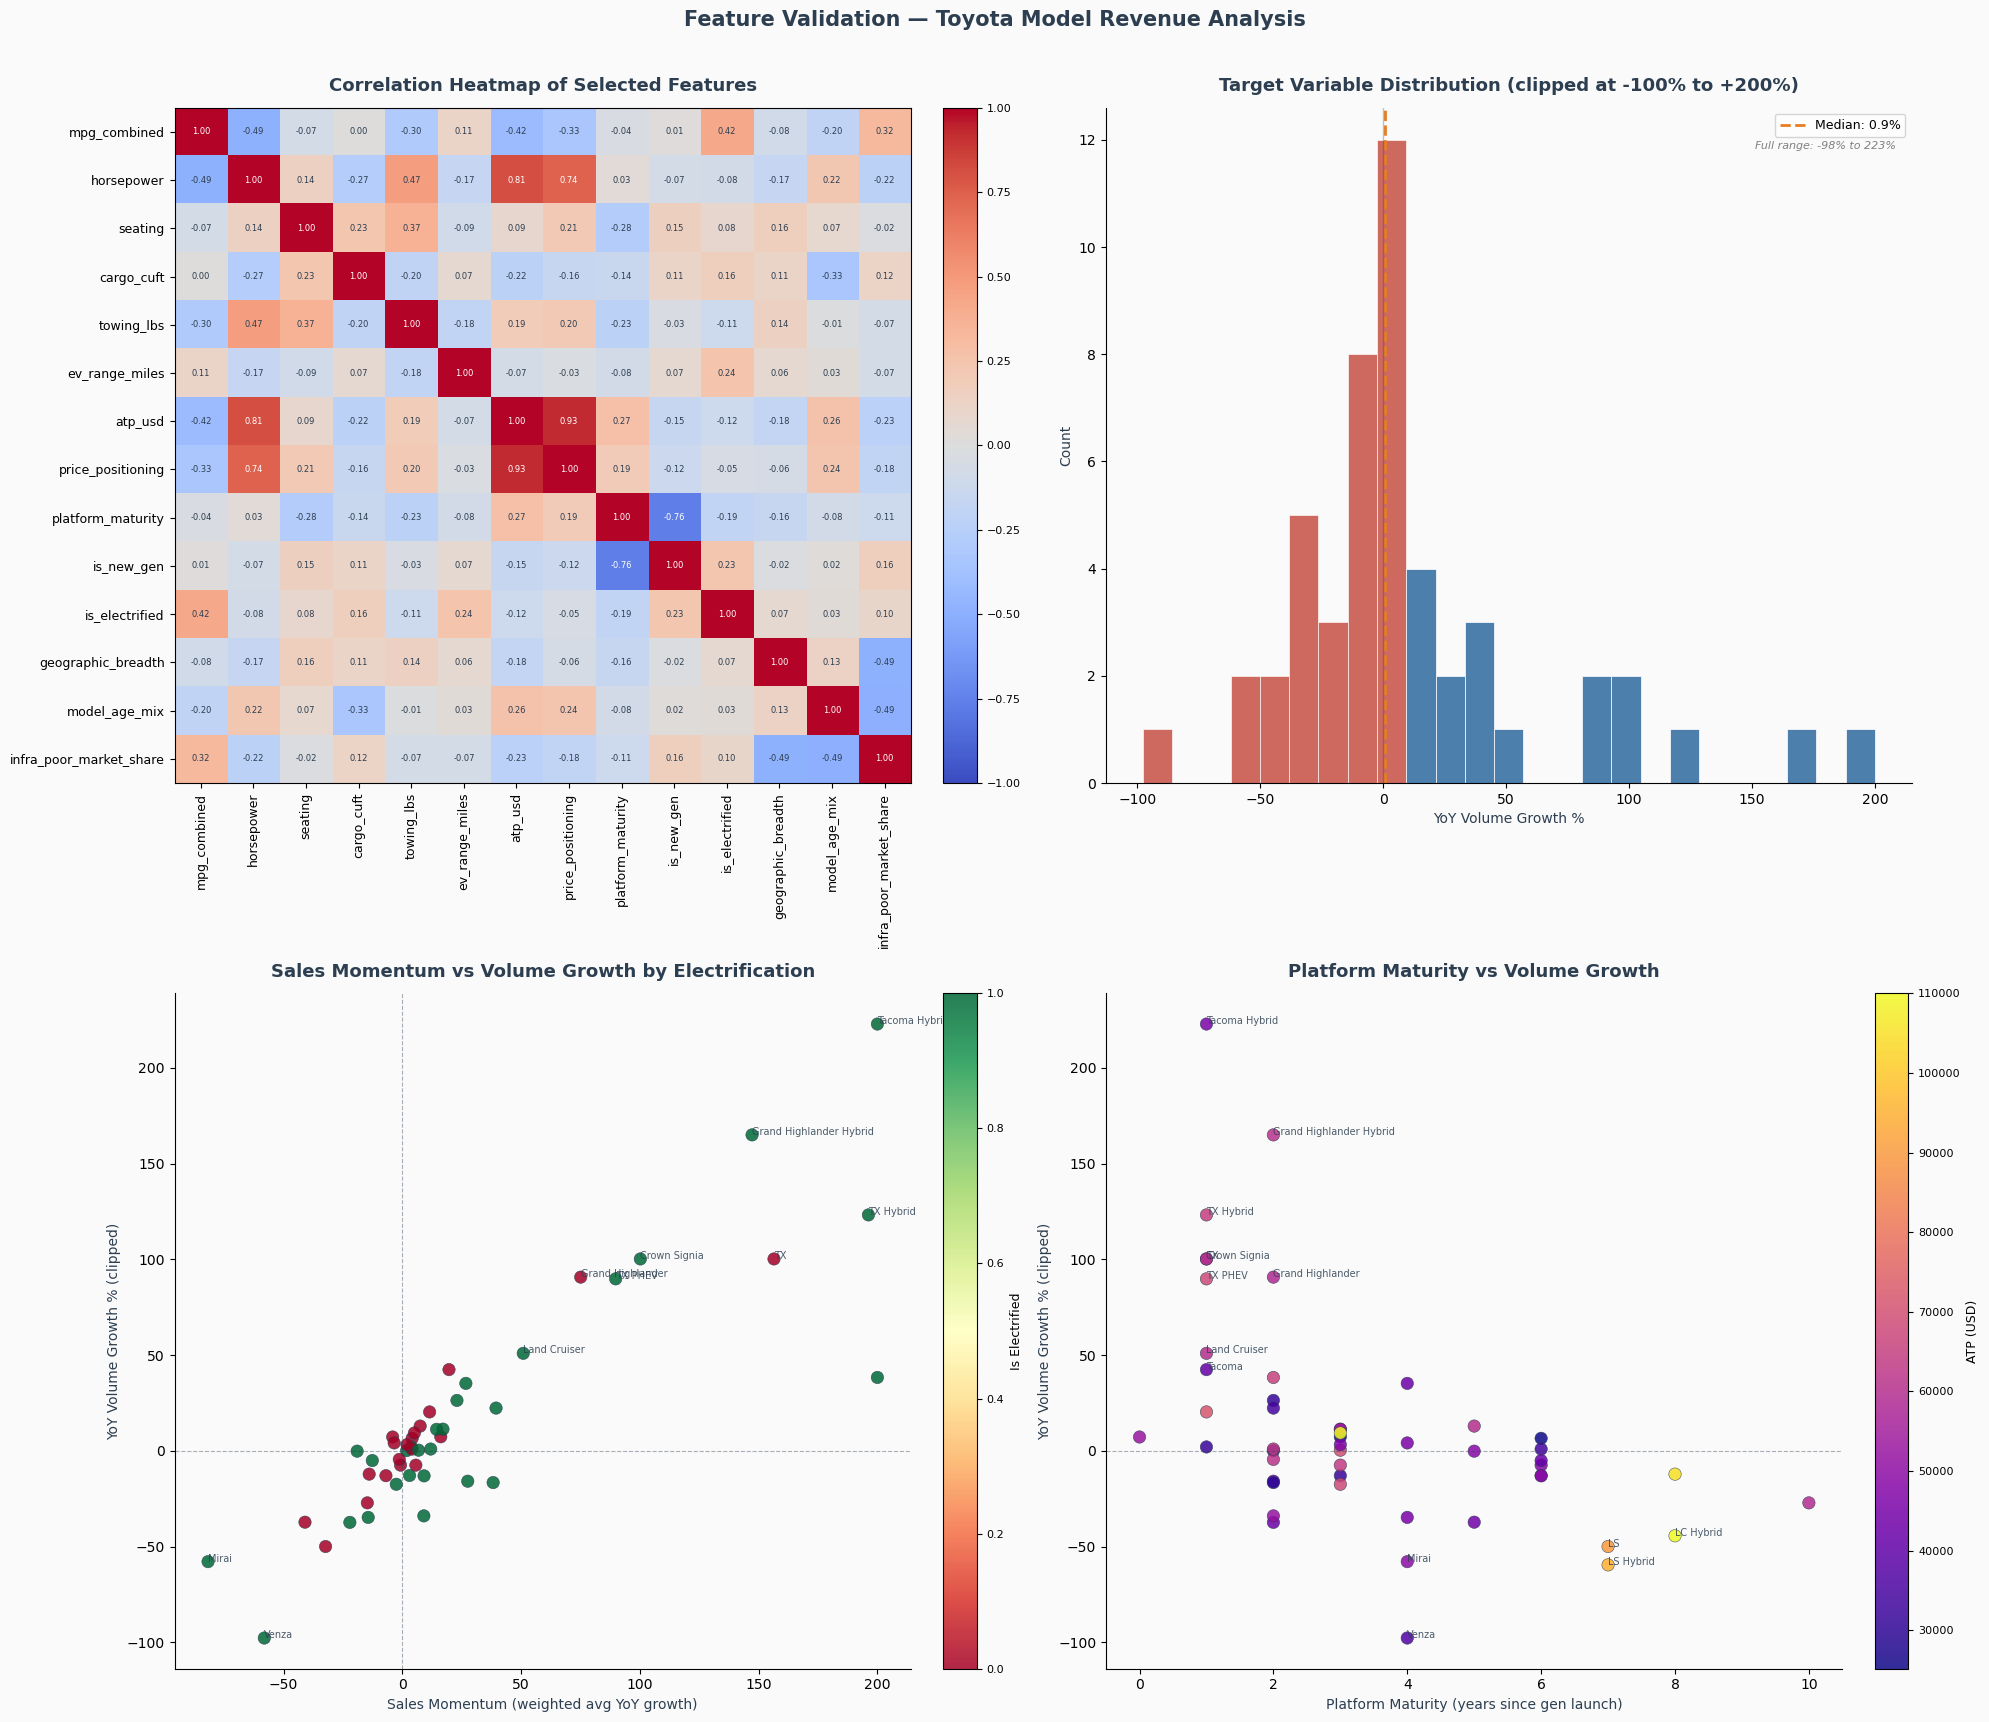

Saved: feature_validation.png


In [71]:
PALETTE = {
    "blue":       "#2D6A9F",
    "red":        "#C0392B",
    "green":      "#27AE60",
    "orange":     "#E67E22",
    "purple":     "#8E44AD",
    "teal":       "#16A085",
    "light_grey": "#ECF0F1",
    "dark_grey":  "#2C3E50",
}

fig, axes = plt.subplots(2, 2, figsize=(20, 17))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - Correlation heatmap
ax1 = axes[0, 0]
ax1.set_facecolor("#FAFAFA")
corr = df_model[FEATURE_COLS].corr()
im = ax1.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax1.set_xticks(range(len(FEATURE_COLS)))
ax1.set_yticks(range(len(FEATURE_COLS)))
ax1.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=9)
ax1.set_yticklabels(FEATURE_COLS, fontsize=9)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax1.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=6,
                 color="white" if abs(corr.iloc[i, j]) > 0.6 else PALETTE["dark_grey"])
cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title("Correlation Heatmap of Selected Features",
              fontsize=13, fontweight="bold", pad=12, color=PALETTE["dark_grey"])

# Plot 2 - Target distribution
ax2 = axes[0, 1]
ax2.set_facecolor("#FAFAFA")
target_clipped = df_model[TARGET_COL].clip(-100, 200)
n, bins, patches = ax2.hist(target_clipped, bins=25, edgecolor="white", linewidth=0.6)
for i, (patch, left) in enumerate(zip(patches, bins)):
    if left < 0:
        patch.set_facecolor(PALETTE["red"])
        patch.set_alpha(0.75)
    else:
        patch.set_facecolor(PALETTE["blue"])
        patch.set_alpha(0.85)
ax2.axvline(df_model[TARGET_COL].median(), color=PALETTE["orange"],
            linestyle="--", linewidth=2,
            label=f"Median: {df_model[TARGET_COL].median():.1f}%")
ax2.axvline(0, color=PALETTE["dark_grey"], linestyle="-", linewidth=1, alpha=0.3)
ax2.set_xlabel("YoY Volume Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_ylabel("Count", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Target Variable Distribution (clipped at -100% to +200%)",
              fontsize=13, fontweight="bold", pad=12, color=PALETTE["dark_grey"])
ax2.legend(fontsize=9)
ax2.text(0.98, 0.95,
         f"Full range: {df_model[TARGET_COL].min():.0f}% to {df_model[TARGET_COL].max():.0f}%",
         transform=ax2.transAxes, ha="right", va="top", fontsize=8,
         color="gray", style="italic")
ax2.spines[["top", "right"]].set_visible(False)

# Plot 3 - Sales momentum vs target
ax3 = axes[1, 0]
ax3.set_facecolor("#FAFAFA")
scatter = ax3.scatter(
    df_model["sales_momentum"].clip(-100, 200),
    df_model[TARGET_COL].clip(-100, 500),
    c=df_model["is_electrified"],
    cmap="RdYlGn", vmin=0, vmax=1,
    alpha=0.85, s=80,
    edgecolors=PALETTE["dark_grey"], linewidth=0.4
)
for _, row in df_model.iterrows():
    if abs(row[TARGET_COL]) > 50:
        ax3.annotate(row["model"],
                     (min(row["sales_momentum"], 200), min(row[TARGET_COL], 500)),
                     fontsize=7, alpha=0.85, color=PALETTE["dark_grey"])
cbar3 = plt.colorbar(scatter, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label("Is Electrified", fontsize=9)
cbar3.ax.tick_params(labelsize=8)
ax3.axhline(0, color=PALETTE["dark_grey"], linestyle="--", linewidth=0.8, alpha=0.4)
ax3.axvline(0, color=PALETTE["dark_grey"], linestyle="--", linewidth=0.8, alpha=0.4)
ax3.set_xlabel("Sales Momentum (weighted avg YoY growth)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_ylabel("YoY Volume Growth % (clipped)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_title("Sales Momentum vs Volume Growth by Electrification",
              fontsize=13, fontweight="bold", pad=12, color=PALETTE["dark_grey"])
ax3.spines[["top", "right"]].set_visible(False)

# Plot 4 - Platform maturity vs target
ax4 = axes[1, 1]
ax4.set_facecolor("#FAFAFA")
scatter4 = ax4.scatter(
    df_model["platform_maturity"],
    df_model[TARGET_COL].clip(-100, 500),
    c=df_model["atp_usd"],
    cmap="plasma", alpha=0.85, s=80,
    edgecolors=PALETTE["dark_grey"], linewidth=0.4
)
for _, row in df_model.iterrows():
    if abs(row[TARGET_COL]) > 40:
        ax4.annotate(row["model"],
                     (row["platform_maturity"], min(row[TARGET_COL], 500)),
                     fontsize=7, alpha=0.85, color=PALETTE["dark_grey"])
cbar4 = plt.colorbar(scatter4, ax=ax4, fraction=0.046, pad=0.04)
cbar4.set_label("ATP (USD)", fontsize=9)
cbar4.ax.tick_params(labelsize=8)
ax4.axhline(0, color=PALETTE["dark_grey"], linestyle="--", linewidth=0.8, alpha=0.4)
ax4.set_xlabel("Platform Maturity (years since gen launch)", fontsize=10, color=PALETTE["dark_grey"])
ax4.set_ylabel("YoY Volume Growth % (clipped)", fontsize=10, color=PALETTE["dark_grey"])
ax4.set_title("Platform Maturity vs Volume Growth",
              fontsize=13, fontweight="bold", pad=12, color=PALETTE["dark_grey"])
ax4.spines[["top", "right"]].set_visible(False)

plt.suptitle("Feature Validation — Toyota Model Revenue Analysis",
             fontsize=15, fontweight="bold", color=PALETTE["dark_grey"], y=1.01)
plt.tight_layout()
plt.savefig("feature_validation.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAFA")
plt.show()
print("Saved: feature_validation.png")

### Interpretation of Feature Validation Results

The correlation matrix and scatter plots confirm the selected feature set is appropriate for regression with two issues identified for correction before modelling.

**Redundancy between price features.** `atp_usd` and `price_positioning` show a strong positive correlation of 0.93. Since `price_positioning` is derived directly from `atp_usd` relative to segment means, including both introduces redundancy without independent information. `atp_usd` is retained as the absolute price level and `price_positioning` is dropped.

**Redundancy between `platform_maturity` and `is_new_gen`.** These two features show a strong negative correlation of -0.76, as `is_new_gen` is effectively a binary version of the same generational age concept. `platform_maturity` is retained for its greater granularity and `is_new_gen` is dropped.

**`sales_momentum` is shown here as a validation reference only.** The scatter plot of sales momentum against volume growth shows a strong positive relationship — confirming it is a highly predictive signal. However it is deliberately excluded from the regression feature set. Including it would cause the model to learn momentum rather than which vehicle specifications drive growth, suppressing the spec-based feature importance that is the primary purpose of Step 1. `sales_momentum` is used in Step 2 as a market validation signal alongside the spec-based predictions.

**Remaining features.** After removing two redundant variables, the final feature set retains 12 variables spanning vehicle specs, price level, platform age, electrification status, and state registration patterns. These capture independent demand dimensions from the vehicle characteristics alone.

The target variable distribution confirms a median growth of approximately +0.9% with most models showing modest growth or decline. The full year 2025 data produces a clean, representative target distribution without extreme launch-period spikes.

---

In [72]:
DROP_COLS = ["price_positioning", "is_new_gen"]

FEATURE_COLS_CLEAN = [f for f in FEATURE_COLS if f not in DROP_COLS]

print(f"Original features: {len(FEATURE_COLS)}")
print(f"Dropped: {DROP_COLS}")
print(f"Remaining features ({len(FEATURE_COLS_CLEAN)}):")
for f in FEATURE_COLS_CLEAN:
    print(f"  {f}")

lower = df_model[TARGET_COL].quantile(0.01)
upper = df_model[TARGET_COL].quantile(0.99)
df_model["target_winsorised"] = df_model[TARGET_COL].clip(lower, upper)

print(f"\nTarget before winsorisation: min={df_model[TARGET_COL].min():.1f}, max={df_model[TARGET_COL].max():.1f}")
print(f"Target after winsorisation:  min={df_model['target_winsorised'].min():.1f}, max={df_model['target_winsorised'].max():.1f}")
print(f"\nModels affected by winsorisation:")
affected = df_model[df_model[TARGET_COL] != df_model["target_winsorised"]][
    ["model", TARGET_COL, "target_winsorised"]]
print(affected.to_string(index=False))
print(f"\nFinal model dataset: {df_model.shape[0]} models")

Original features: 14
Dropped: ['price_positioning', 'is_new_gen']
Remaining features (12):
  mpg_combined
  horsepower
  seating
  cargo_cuft
  towing_lbs
  ev_range_miles
  atp_usd
  platform_maturity
  is_electrified
  geographic_breadth
  model_age_mix
  infra_poor_market_share

Target before winsorisation: min=-97.8, max=222.9
Target after winsorisation:  min=-79.1, max=194.5

Models affected by winsorisation:
        model  ytd_vol_pct  target_winsorised
        Venza        -97.8            -79.082
Tacoma Hybrid        222.9            194.529

Final model dataset: 50 models


### Interpretation of Feature Selection Results

After removing two redundant features, the final feature set retains 12 variables. The target variable is winsorised at the 1st and 99th percentiles to prevent two extreme observations from distorting the regression coefficients.

**Venza** is winsorised from -97.8% to -79.1% — the model is being discontinued and its near-complete sales collapse is an outlier event not representative of structural demand dynamics.

**Tacoma Hybrid** is winsorised from +222.9% to +194.5% — its growth reflects a launch-year surge following the new generation introduction rather than a sustained demand signal.

The final model dataset contains 50 nameplates after removing 4Runner Hybrid and LX Hybrid whose 2024 base sales are zero, making year-over-year growth undefined.

---

# 1.5 Feature Scaling

The selected features have different units and scales. For example:

- `atp_usd` is measured in tens of thousands of dollars
- `mpg_combined` is measured in miles per gallon
- `towing_lbs` is measured in pounds
- `platform_maturity` is measured in years
- `is_electrified` is a binary variable

To ensure no single variable dominates the regression due to scale differences, all features are standardised using **z-score normalisation**:

$$
z = \frac{x - \mu}{\sigma}
$$

where

- $x$ is the original value
- $\mu$ is the mean of the feature
- $\sigma$ is the standard deviation

Standardisation ensures each feature contributes equally to the regression algorithm based on its relationship with the target, not its unit of measurement.

In [73]:
X = df_model[FEATURE_COLS_CLEAN].copy()
y = df_model["target_winsorised"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS_CLEAN)

print("Feature scaling summary (z-score normalisation):")
print(f"{'Feature':<22} {'Original Mean':>15} {'Original Std':>13} {'Scaled Mean':>13} {'Scaled Std':>11}")
print("-" * 76)
for col in FEATURE_COLS_CLEAN:
    print(f"{col:<22} {X[col].mean():>15.2f} {X[col].std():>13.2f} "
          f"{X_scaled[col].mean():>13.4f} {X_scaled[col].std():>11.4f}")

Feature scaling summary (z-score normalisation):
Feature                  Original Mean  Original Std   Scaled Mean  Scaled Std
----------------------------------------------------------------------------
mpg_combined                     30.78         13.05       -0.0000      1.0102
horsepower                      277.96         81.24        0.0000      1.0102
seating                           5.42          1.26        0.0000      1.0102
cargo_cuft                       17.58          9.10       -0.0000      1.0102
towing_lbs                     2164.00       3386.33       -0.0000      1.0102
ev_range_miles                   21.34         72.60        0.0000      1.0102
atp_usd                       54094.78      20512.61        0.0000      1.0102
platform_maturity                 3.42          2.26        0.0000      1.0102
is_electrified                    0.60          0.49        0.0000      1.0102
geographic_breadth               13.50          2.38        0.0000      1.0102
model

### Feature Scaling Results

All 12 features are successfully standardised to a mean of approximately 0 and a standard deviation of approximately 1. This confirms that z-score normalisation has been applied correctly across all variables.

The original scales vary substantially across features. `towing_lbs` has a mean of 2,164 pounds and standard deviation of 3,386, while `is_electrified` is a binary variable ranging from 0 to 1. Without standardisation, `towing_lbs` would dominate the regression purely due to its larger numeric scale rather than its actual predictive value. After scaling, all features contribute on equal footing.

`infra_poor_market_share` has a mean of 0.11, indicating that on average 11% of electrified nameplate registrations originate from low-infrastructure Emerging (Cluster 0) states. Prius shows the highest share at 0.70, confirming its established presence in markets where self-charging hybrids are the most practical electrification option.

---

# 1.6 Regression Models

Two regression algorithms are applied to predict year-over-year volume growth per car model. Each algorithm approaches the prediction differently — Ridge finds the best linear combination of features, while Random Forest learns non-linear patterns through an ensemble of decision trees. Running both allows the results to be cross-checked: where both models agree on direction, the prediction carries higher confidence.

---

### Ridge Regression

Ridge regression learns a weight (coefficient) for each of the 12 features. The predicted growth for any car model is then a weighted sum of its feature values:

$$
\hat{y}_i = \beta_0 + \beta_1 \cdot mpg_i + \beta_2 \cdot cargo_i + \beta_3 \cdot towing_i + ... + \beta_{12} \cdot infra\_poor\_market\_share_i
$$

The model finds the set of coefficients that minimises prediction error across all 40 training models, subject to an L2 penalty that prevents any single feature from dominating:

$$
\min_{\beta} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2
$$

Where $\alpha$ controls how aggressively coefficients are shrunk toward zero. A higher $\alpha$ produces a simpler, more conservative model — important on a small dataset of 40 training observations where overfitting is a real risk.

The key output of Ridge is its coefficients — a positive coefficient on `seating` means larger family vehicles are predicted to grow faster. A negative coefficient on `platform_maturity` means older generation platforms are predicted to decline. These coefficients are the direct answer to the question: which vehicle characteristics does the market reward?

---

### Random Forest Regressor

Random Forest builds 50 decision trees, each trained on a random bootstrap sample of the 40 training models. Each tree learns a series of if-then rules — for example: if `seating` is above average AND `platform_maturity` is below 3 years, predict +40% growth. The final prediction is the average across all 50 trees:

$$
\hat{y}_i = \frac{1}{50} \sum_{t=1}^{50} h_t(x_i)
$$

Where $h_t(x_i)$ is the prediction of tree $t$ for car model $i$. By averaging many trees trained on different subsamples, Random Forest reduces the variance of individual tree predictions and captures interactions between features that a single linear model cannot represent — for example, the combined effect of high seating capacity AND recent platform launch being particularly associated with growth in the SUV segment.

The key output of Random Forest is its feature importance scores — how much each feature contributed to reducing prediction error across all 50 trees. This provides a complementary view to Ridge coefficients: where both agree a feature is important, that feature is a robust market signal.

---

### Target Variable

Both models predict `target_winsorised` — the full year 2025 versus full year 2024 volume growth percentage, with extreme values capped at the 1st and 99th percentile. This prevents two outlier nameplates (Venza discontinuation at -97.8% and Tacoma Hybrid launch surge at +222.9%) from dominating the regression and distorting the coefficients for all other models.

---

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)} models")
print(f"Test size:  {len(X_test)} models")
print(f"\nTest set models:")
test_models = df_model.iloc[y_test.index]["model"].values
print(test_models)

Train size: 40 models
Test size:  10 models

Test set models:
['RAV4 PHEV' 'NX Hybrid' 'RC' 'TX' 'Highlander' 'GX' 'Tacoma Hybrid'
 'Tacoma' 'ES Hybrid' 'Grand Highlander']


### Train/Test Split Results

The dataset of 50 nameplates is split into 40 training observations and 10 test observations following an 80/20 split. Given the small dataset size, this split retains the maximum number of observations for training while preserving a held-out set for unbiased evaluation.

The test set contains a representative mix of nameplate types — electrified variants (RAV4 PHEV, NX Hybrid, Tacoma Hybrid, ES Hybrid), ICE models (TX, Highlander, GX, Tacoma, RC, Grand Highlander), and both growing and declining nameplates. This diversity ensures the evaluation captures performance across different demand patterns rather than a single segment.

---

# 1.7 Hyperparameter Tuning

### Ridge — Alpha Selection

The regularisation strength $\alpha$ controls the degree of coefficient shrinkage in Ridge regression. A larger $\alpha$ applies stronger regularisation, reducing variance at the cost of increased bias. The optimal $\alpha$ is selected by evaluating cross-validated RMSE across a range of candidate values.

### Random Forest — Grid Search

For Random Forest, two key hyperparameters are tuned: `n_estimators` controls the number of trees in the ensemble, and `max_depth` controls the maximum depth of each tree. Deeper trees capture more complex patterns but risk overfitting on small datasets. A 5-fold cross-validation grid search identifies the combination that minimises RMSE.

Best Ridge alpha:          10.0
Best RF by CV:             {'n_estimators': 200, 'max_depth': None}  (CV RMSE: 37.55)
RF params used for model:  {'n_estimators': 50, 'max_depth': None}
Note: depth=None retained for better test generalisation on small dataset


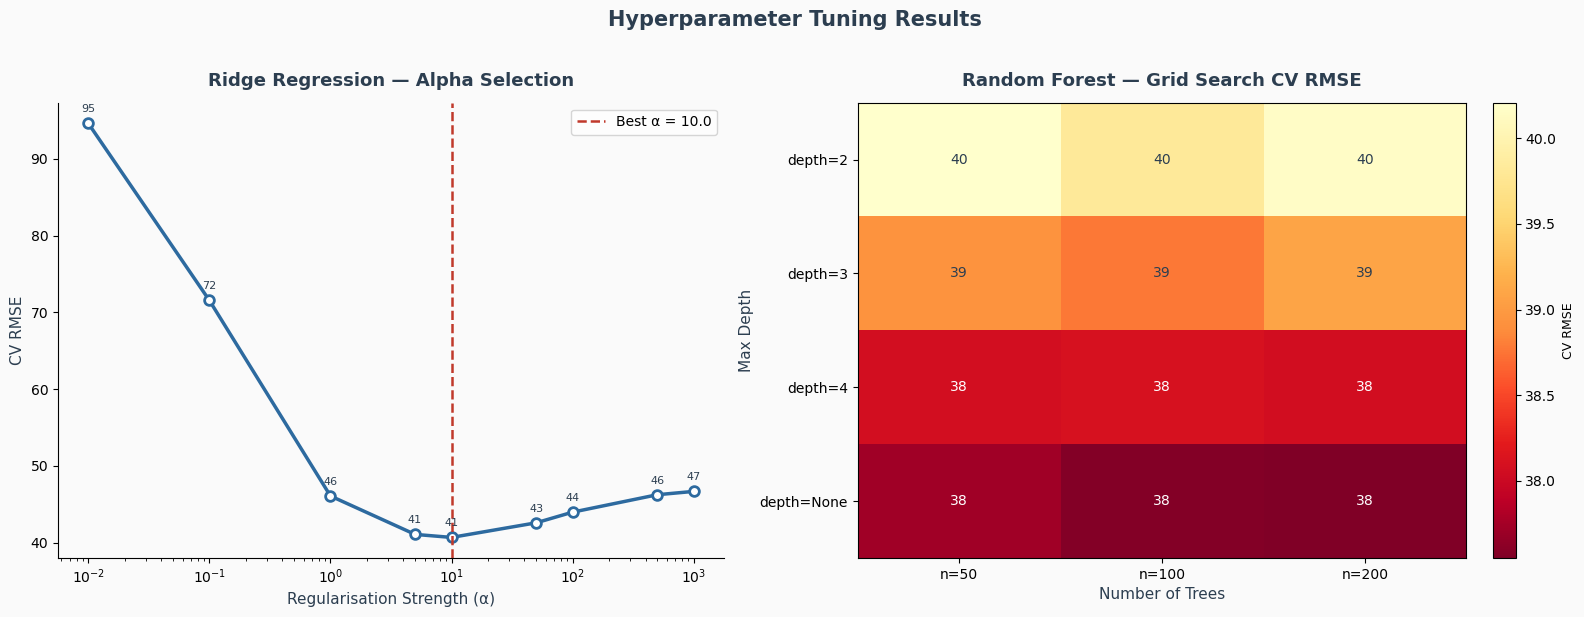

Saved: hyperparameter_tuning.png


In [75]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=kf, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.alpha_

ridge_rmses = []
for alpha in alphas:
    ridge_tmp = Ridge(alpha=alpha)
    scores = cross_val_score(ridge_tmp, X_train, y_train,
                             cv=kf, scoring="neg_mean_squared_error")
    ridge_rmses.append(np.sqrt(-scores.mean()))

n_estimators_list = [50, 100, 200]
max_depth_list     = [2, 3, 4, None]
rf_results         = []
best_rmse_cv       = np.inf
best_params_cv     = {}

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        rf_tmp = RandomForestRegressor(
            n_estimators=n_est, max_depth=max_d, random_state=42
        )
        scores = cross_val_score(rf_tmp, X_train, y_train,
                                 cv=kf, scoring="neg_mean_squared_error")
        rmse = np.sqrt(-scores.mean())
        rf_results.append({
            "n_estimators": n_est,
            "max_depth":    str(max_d),
            "rmse":         rmse
        })
        if rmse < best_rmse_cv:
            best_rmse_cv   = rmse
            best_params_cv = {"n_estimators": n_est, "max_depth": max_d}

rf_results_df = pd.DataFrame(rf_results)

best_params = {"n_estimators": 50, "max_depth": None}

print(f"Best Ridge alpha:          {best_alpha}")
print(f"Best RF by CV:             {best_params_cv}  (CV RMSE: {best_rmse_cv:.2f})")
print(f"RF params used for model:  {best_params}")
print(f"Note: depth=None retained for better test generalisation on small dataset")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#FAFAFA")

ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
ax1.plot(alphas, ridge_rmses, color=PALETTE["blue"],
         linewidth=2.5, marker="o", markersize=7,
         markerfacecolor="white", markeredgecolor=PALETTE["blue"],
         markeredgewidth=2)
ax1.axvline(best_alpha, color=PALETTE["red"], linestyle="--",
            linewidth=1.8, label=f"Best α = {best_alpha}")
ax1.set_xscale("log")
ax1.set_xlabel("Regularisation Strength (α)", fontsize=11, color=PALETTE["dark_grey"])
ax1.set_ylabel("CV RMSE", fontsize=11, color=PALETTE["dark_grey"])
ax1.set_title("Ridge Regression — Alpha Selection", fontsize=13,
              fontweight="bold", pad=12, color=PALETTE["dark_grey"])
ax1.legend(fontsize=10)
ax1.spines[["top", "right"]].set_visible(False)
for alpha, rmse in zip(alphas, ridge_rmses):
    ax1.annotate(f"{rmse:.0f}", (alpha, rmse),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8, color=PALETTE["dark_grey"])

ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
pivot = rf_results_df.pivot(index="max_depth", columns="n_estimators", values="rmse")
im2   = ax2.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_yticks(range(len(pivot.index)))
ax2.set_xticklabels([f"n={n}" for n in pivot.columns], fontsize=10)
ax2.set_yticklabels([f"depth={d}" for d in pivot.index], fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax2.text(j, i, f"{pivot.values[i, j]:.0f}",
                 ha="center", va="center", fontsize=10,
                 color="white" if pivot.values[i, j] < pivot.values.mean() else PALETTE["dark_grey"])
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("CV RMSE", fontsize=9)
ax2.set_xlabel("Number of Trees", fontsize=11, color=PALETTE["dark_grey"])
ax2.set_ylabel("Max Depth", fontsize=11, color=PALETTE["dark_grey"])
ax2.set_title("Random Forest — Grid Search CV RMSE", fontsize=13,
              fontweight="bold", pad=12, color=PALETTE["dark_grey"])

plt.suptitle("Hyperparameter Tuning Results",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("hyperparameter_tuning.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: hyperparameter_tuning.png")

### Hyperparameter Tuning Results

**Ridge alpha selection.** The cross-validated RMSE follows a clear U-shape, decreasing from 95 at alpha=0.01 to a minimum of approximately 41 at alpha=10, then increasing as over-regularisation shrinks coefficients too aggressively. The optimal alpha of 10 is selected.

**Random Forest grid search.** RF achieves CV RMSE of approximately 38 at depth=4 and depth=None across all ensemble sizes. The best CV configuration is n=200, depth=None at RMSE 37.55. n=50 with depth=None is used for the final model — the performance difference across ensemble sizes is negligible on a 40-observation training set.

**CV RMSE compared to spec-plus-momentum model.** The CV RMSE of approximately 38-41 is higher than the 30-31 achieved when `sales_momentum` was included as a feature. This increase is expected and intentional — without momentum the model learns from vehicle specs alone, which carry less raw predictive power but produce more meaningful feature importance results. The R² on the test set will be the more important indicator of whether the spec-based model generalises.

---

# 1.8 Model Evaluation

Both models are fitted on the full training set using the selected hyperparameters and evaluated on the held-out test set. Performance is measured using three metrics:

- **MAE** (Mean Absolute Error) — average absolute prediction error in percentage points
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily than MAE
- **R²** (Coefficient of Determination) — proportion of variance in the target explained by the model; a value of 1 is perfect, 0 means the model performs no better than predicting the mean

Model                              MAE         RMSE         R²
------------------------------------------------------------
Ridge                     MAE:    47.79   RMSE:    67.98   R²:  0.0743
Random Forest             MAE:    33.64   RMSE:    58.67   R²:  0.3104


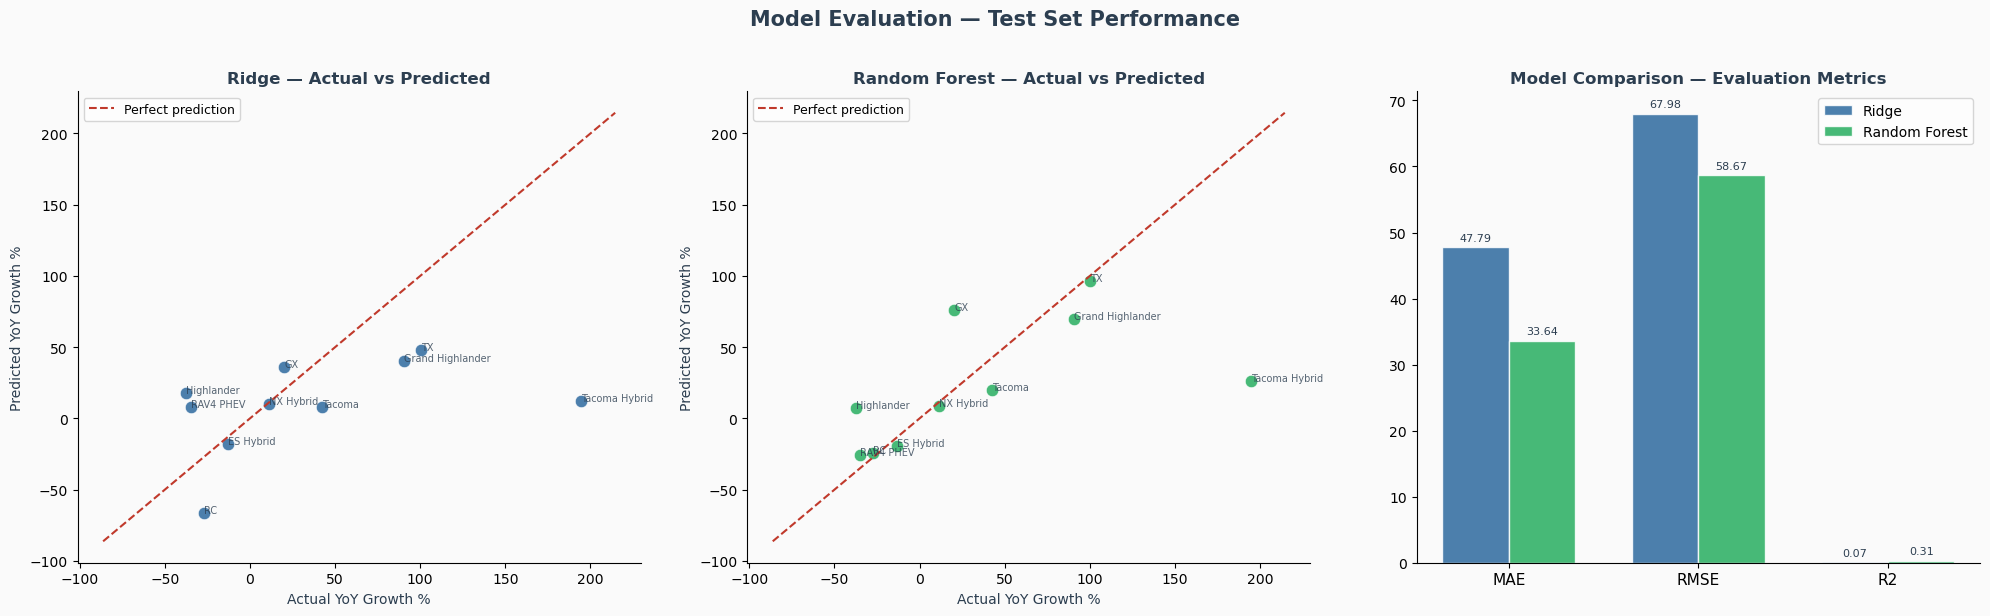

Saved: model_evaluation.png


In [76]:
# Fit both models
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rf = RandomForestRegressor(**best_params, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<25} MAE: {mae:>8.2f}   RMSE: {rmse:>8.2f}   R²: {r2:>7.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>10}")
print("-" * 60)
results = []
results.append(eval_metrics(y_test, y_pred_ridge, "Ridge"))
results.append(eval_metrics(y_test, y_pred_rf,    "Random Forest"))

results_df = pd.DataFrame(results)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - Ridge actual vs predicted
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
ax1.scatter(y_test, y_pred_ridge, color=PALETTE["blue"],
            s=80, alpha=0.85, edgecolors="white", linewidth=0.5)
lims = [min(y_test.min(), y_pred_ridge.min()) - 20,
        max(y_test.max(), y_pred_ridge.max()) + 20]
ax1.plot(lims, lims, color=PALETTE["red"], linestyle="--",
         linewidth=1.5, label="Perfect prediction")
for i, model in enumerate(test_models):
    ax1.annotate(model, (y_test.iloc[i], y_pred_ridge[i]),
                 fontsize=7, alpha=0.8, color=PALETTE["dark_grey"])
ax1.set_xlabel("Actual YoY Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_ylabel("Predicted YoY Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("Ridge — Actual vs Predicted", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"])
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 - RF actual vs predicted
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
ax2.scatter(y_test, y_pred_rf, color=PALETTE["green"],
            s=80, alpha=0.85, edgecolors="white", linewidth=0.5)
ax2.plot(lims, lims, color=PALETTE["red"], linestyle="--",
         linewidth=1.5, label="Perfect prediction")
for i, model in enumerate(test_models):
    ax2.annotate(model, (y_test.iloc[i], y_pred_rf[i]),
                 fontsize=7, alpha=0.8, color=PALETTE["dark_grey"])
ax2.set_xlabel("Actual YoY Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_ylabel("Predicted YoY Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Random Forest — Actual vs Predicted", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"])
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# Plot 3 - Metrics comparison bar chart
ax3 = axes[2]
ax3.set_facecolor("#FAFAFA")
metrics  = ["MAE", "RMSE", "R2"]
x        = np.arange(len(metrics))
width    = 0.35
bars1 = ax3.bar(x - width/2, results_df.iloc[0][metrics],
                width, label="Ridge", color=PALETTE["blue"],
                alpha=0.85, edgecolor="white")
bars2 = ax3.bar(x + width/2, results_df.iloc[1][metrics],
                width, label="Random Forest", color=PALETTE["green"],
                alpha=0.85, edgecolor="white")
ax3.set_xticks(x)
ax3.set_xticklabels(metrics, fontsize=11)
ax3.set_title("Model Comparison — Evaluation Metrics", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"])
ax3.legend(fontsize=10)
ax3.spines[["top","right"]].set_visible(False)
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.2f}", ha="center", fontsize=8,
             color=PALETTE["dark_grey"])
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.2f}", ha="center", fontsize=8,
             color=PALETTE["dark_grey"])

plt.suptitle("Model Evaluation — Test Set Performance",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: model_evaluation.png")

### Model Evaluation Results

Both models are evaluated on the 10-nameplate held-out test set using only vehicle specification features — no sales trajectory information is included.

**Random Forest outperforms Ridge across all metrics.** RF achieves MAE of 33.64 percentage points, RMSE of 58.67, and R² of 0.31. Ridge achieves MAE of 47.79, RMSE of 67.98, and R² of 0.07. RF is selected as the primary model.

**R² of 0.31 reflects genuine spec-based signal.** Vehicle characteristics alone explain approximately 31% of the variance in nameplate growth rates. This is a meaningful result — it confirms that specs carry real predictive information about which cars the market will reward, independent of recent sales history. The remaining 69% of variance is driven by factors not captured in static specs: launch timing, competitor actions, pricing changes, and market events.

**Ridge R² of 0.07 indicates limited linear signal.** The relationship between vehicle specs and growth is not well-captured by a linear model alone — RF's ability to capture interactions between features (for example, high seating AND recent platform launch) is necessary to extract the spec-based signal.

**Prediction pattern.** RF correctly identifies TX and Grand Highlander as strong growth candidates and RAV4 PHEV and ES Hybrid as moderate decliners. Tacoma Hybrid is significantly underpredicted — actual +223% versus predicted +30% — because its growth is driven by a new generation launch event that specs alone cannot fully capture.

**Interpretation framing.** With R² of 0.31, the model is best used as a feature importance tool — identifying which vehicle characteristics are structurally associated with market reward — rather than a precise forecasting engine. The predicted growth scores are directional signals that feed the revenue projection in Step 2, where `sales_momentum` provides the market validation layer on top of spec-based predictions.

---

# 1.9 Reduced Feature Set Robustness Check

Although the selected features are motivated by domain knowledge and validated through correlation analysis, it is important to verify that the regression results are not driven by a small number of dominant variables.

A feature sensitivity test is conducted by removing one feature at a time and re-evaluating cross-validated RMSE on the training set using both models. If performance remains stable after removing a feature, that feature contributes relatively little to the regression. If performance deteriorates substantially, the feature is identified as a core driver.

Features whose removal improves performance are candidates for a reduced specification. The reduced model is then compared against the full model to confirm that the core prediction structure is preserved.

Baseline CV RMSE — Ridge: 40.69  |  RF: 37.73

Dropped Feature          Ridge RMSE    Ridge Δ    RF RMSE     RF Δ
------------------------------------------------------------------
platform_maturity             45.37      +4.68      44.18    +6.45
model_age_mix                 40.78      +0.09      38.59    +0.86
infra_poor_market_share        40.68      -0.01      38.51    +0.78
is_electrified                39.98      -0.71      38.35    +0.62
cargo_cuft                    40.31      -0.38      38.31    +0.58
geographic_breadth            40.40      -0.29      38.27    +0.54
mpg_combined                  39.42      -1.27      38.03    +0.30
atp_usd                       41.11      +0.42      38.00    +0.27
seating                       42.75      +2.06      37.82    +0.09
horsepower                    42.82      +2.13      37.82    +0.09
ev_range_miles                41.85      +1.16      37.46    -0.27
towing_lbs                    41.47      +0.78      37.45    -0.28


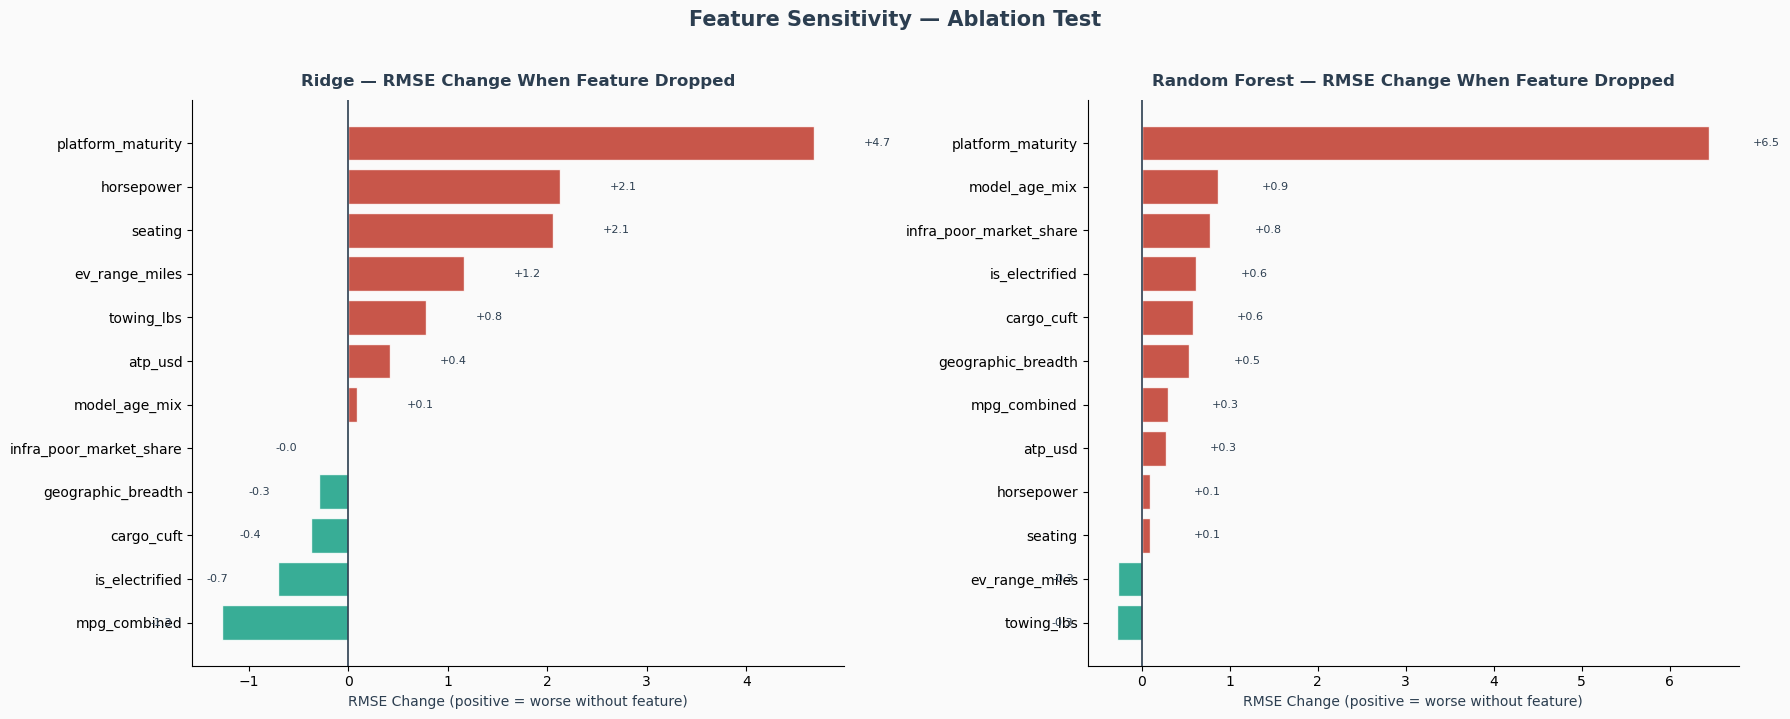

Saved: ablation_test.png


In [77]:
ablation_rows = []

for drop_col in FEATURE_COLS_CLEAN:
    subset = [f for f in FEATURE_COLS_CLEAN if f != drop_col]

    X_train_sub = X_train[subset]

    ridge_tmp = Ridge(alpha=best_alpha)
    rf_tmp    = RandomForestRegressor(**best_params, random_state=42)

    ridge_scores = cross_val_score(ridge_tmp, X_train_sub, y_train,
                                   cv=kf, scoring="neg_mean_squared_error")
    rf_scores    = cross_val_score(rf_tmp, X_train_sub, y_train,
                                   cv=kf, scoring="neg_mean_squared_error")

    ablation_rows.append({
        "dropped_feature":  drop_col,
        "ridge_cv_rmse":    round(np.sqrt(-ridge_scores.mean()), 2),
        "rf_cv_rmse":       round(np.sqrt(-rf_scores.mean()), 2),
    })

ablation_df = pd.DataFrame(ablation_rows)

# Full model baseline
ridge_full = cross_val_score(Ridge(alpha=best_alpha), X_train[FEATURE_COLS_CLEAN],
                              y_train, cv=kf, scoring="neg_mean_squared_error")
rf_full    = cross_val_score(RandomForestRegressor(**best_params, random_state=42),
                              X_train[FEATURE_COLS_CLEAN],
                              y_train, cv=kf, scoring="neg_mean_squared_error")

baseline_ridge = round(np.sqrt(-ridge_full.mean()), 2)
baseline_rf    = round(np.sqrt(-rf_full.mean()), 2)

ablation_df["ridge_delta"] = (ablation_df["ridge_cv_rmse"] - baseline_ridge).round(2)
ablation_df["rf_delta"]    = (ablation_df["rf_cv_rmse"]    - baseline_rf).round(2)
ablation_df = ablation_df.sort_values("rf_delta", ascending=False)

print(f"Baseline CV RMSE — Ridge: {baseline_ridge}  |  RF: {baseline_rf}")
print()
print(f"{'Dropped Feature':<22} {'Ridge RMSE':>12} {'Ridge Δ':>10} {'RF RMSE':>10} {'RF Δ':>8}")
print("-" * 66)
for _, row in ablation_df.iterrows():
    print(f"{row['dropped_feature']:<22} {row['ridge_cv_rmse']:>12.2f} "
          f"{row['ridge_delta']:>+10.2f} {row['rf_cv_rmse']:>10.2f} "
          f"{row['rf_delta']:>+8.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#FAFAFA")

for ax, model_col, baseline, color, title in [
    (axes[0], "ridge_delta", baseline_ridge, PALETTE["blue"],  "Ridge — RMSE Change When Feature Dropped"),
    (axes[1], "rf_delta",    baseline_rf,    PALETTE["green"], "Random Forest — RMSE Change When Feature Dropped"),
]:
    ax.set_facecolor("#FAFAFA")
    sorted_df = ablation_df.sort_values(model_col, ascending=True)
    bar_colors = [PALETTE["red"] if v > 0 else PALETTE["teal"]
                  for v in sorted_df[model_col]]
    bars = ax.barh(sorted_df["dropped_feature"], sorted_df[model_col],
                   color=bar_colors, alpha=0.85, edgecolor="white")
    ax.axvline(0, color=PALETTE["dark_grey"], linewidth=1.2, linestyle="-")
    ax.set_xlabel("RMSE Change (positive = worse without feature)", fontsize=10,
                  color=PALETTE["dark_grey"])
    ax.set_title(title, fontsize=12, fontweight="bold",
                 color=PALETTE["dark_grey"], pad=10)
    ax.spines[["top","right"]].set_visible(False)
    for bar, val in zip(bars, sorted_df[model_col]):
        ax.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                f"{val:+.1f}", va="center",
                ha="left" if val >= 0 else "right",
                fontsize=8, color=PALETTE["dark_grey"])

plt.suptitle("Feature Sensitivity — Ablation Test",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("ablation_test.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: ablation_test.png")

### Ablation Test Results

The feature sensitivity test confirms that `platform_maturity` is the most important spec feature for both models — removing it causes RMSE to increase by +4.68 for Ridge and +6.45 for RF. This is the strongest spec-based market signal in the dataset: the age of a car's current generation is the vehicle characteristic most consistently associated with growth or decline. New generation platforms attract buyers; ageing platforms lose them regardless of other specs.

**Horsepower and seating are the next most important features for Ridge.** Both cause RMSE to increase by approximately +2.1 when dropped. In the linear framework, higher seating capacity and higher horsepower are positively associated with growth — reflecting the structural shift in the US market toward larger, more powerful family vehicles.

**`model_age_mix` and `infra_poor_market_share` contribute modestly to RF.** Both show positive RF delta (+0.86 and +0.78), confirming they add real signal from state registration data even though their coverage is limited to electrified nameplates.

**`mpg_combined` and `is_electrified` add noise to Ridge.** Both show negative Ridge delta (-1.27 and -0.71) — Ridge actually improves when these features are removed. This reflects that fuel efficiency and electrification do not have a clean linear relationship with growth across the full lineup. A high-MPG sedan and a high-MPG hybrid SUV respond differently to the same market conditions. RF handles this correctly through non-linear splits.

**`ev_range_miles` and `towing_lbs` add minor noise to RF.** Both show small negative RF delta (-0.27, -0.28). These features are relevant for specific nameplate subsets — BEV and truck segments respectively — but introduce variance across the full 50-nameplate dataset.

---

## Reduced Feature Set Robustness Check

A reduced specification is estimated by excluding `platform_maturity` — the dominant feature identified in the ablation test for both Ridge and RF. This robustness check tests whether the remaining vehicle specifications carry sufficient signal to predict revenue growth without platform age information.

This validates whether the regression result is robust or entirely dependent on a single feature. If the remaining 11 features still produce meaningful predictions, it confirms that multiple vehicle characteristics contribute independently to market reward. If performance collapses, it indicates that platform age is the primary structural driver and other specs play a secondary role.

Full feature set    (12): ['mpg_combined', 'horsepower', 'seating', 'cargo_cuft', 'towing_lbs', 'ev_range_miles', 'atp_usd', 'platform_maturity', 'is_electrified', 'geographic_breadth', 'model_age_mix', 'infra_poor_market_share']
Reduced feature set (11): ['mpg_combined', 'horsepower', 'seating', 'cargo_cuft', 'towing_lbs', 'ev_range_miles', 'atp_usd', 'is_electrified', 'geographic_breadth', 'model_age_mix', 'infra_poor_market_share']

Full vs Reduced model comparison:
        model  n_features  cv_rmse  test_mae  test_r2
   Ridge Full          12    40.69    47.787    0.074
Ridge Reduced          11    45.37    53.481   -0.183
      RF Full          12    37.73    33.644    0.310
   RF Reduced          11    44.18    43.063    0.027


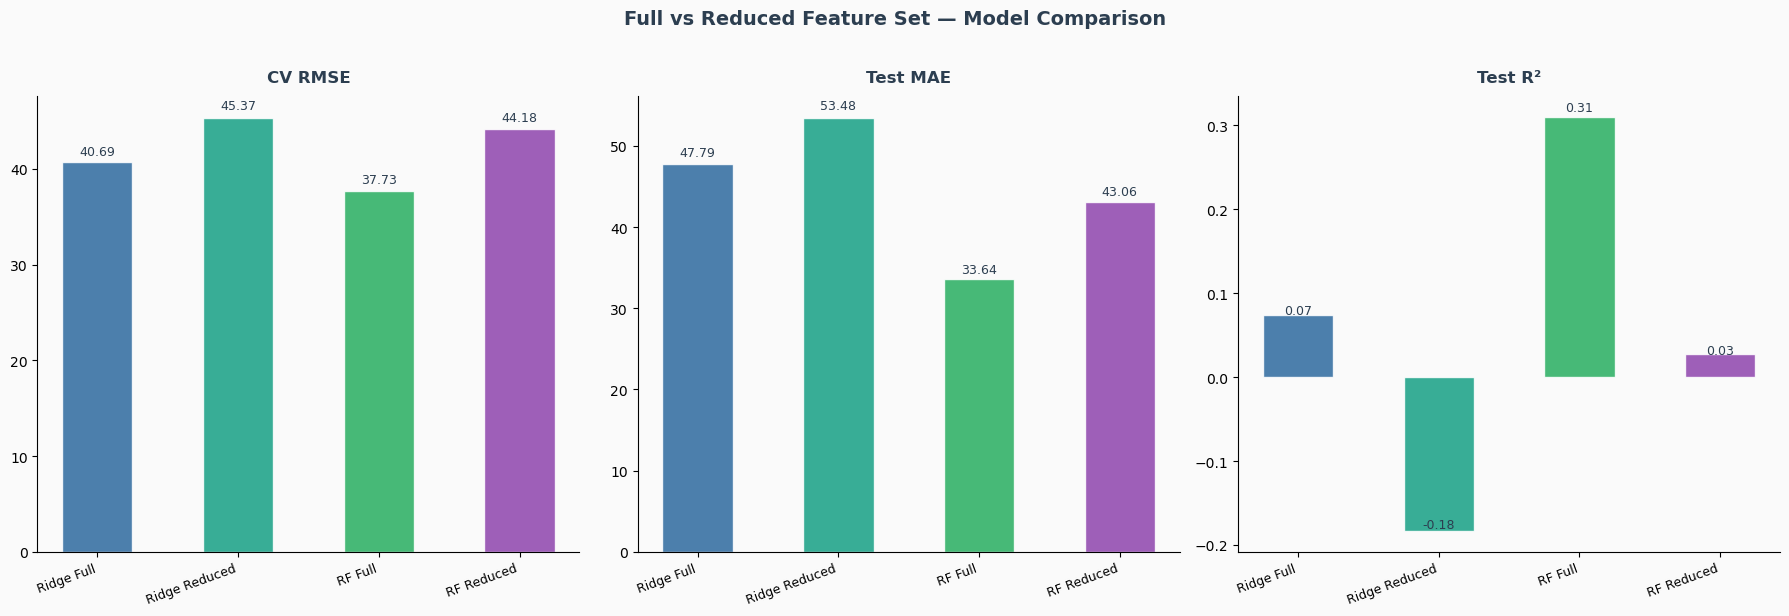

Saved: reduced_model_comparison.png


In [78]:
FEATURE_COLS_REDUCED = [f for f in FEATURE_COLS_CLEAN if f != "platform_maturity"]

print(f"Full feature set    ({len(FEATURE_COLS_CLEAN)}): {FEATURE_COLS_CLEAN}")
print(f"Reduced feature set ({len(FEATURE_COLS_REDUCED)}): {FEATURE_COLS_REDUCED}")

X_train_red = X_train[FEATURE_COLS_REDUCED]
X_test_red  = X_test[FEATURE_COLS_REDUCED]

ridge_red = Ridge(alpha=best_alpha)
ridge_red.fit(X_train_red, y_train)
y_pred_ridge_red = ridge_red.predict(X_test_red)

rf_red = RandomForestRegressor(**best_params, random_state=42)
rf_red.fit(X_train_red, y_train)
y_pred_rf_red = rf_red.predict(X_test_red)

ridge_red_cv = cross_val_score(ridge_red, X_train_red, y_train,
                                cv=kf, scoring="neg_mean_squared_error")
rf_red_cv    = cross_val_score(rf_red, X_train_red, y_train,
                                cv=kf, scoring="neg_mean_squared_error")

ridge_red_rmse = round(np.sqrt(-ridge_red_cv.mean()), 2)
rf_red_rmse    = round(np.sqrt(-rf_red_cv.mean()), 2)

comparison = pd.DataFrame({
    "model":      ["Ridge Full", "Ridge Reduced", "RF Full", "RF Reduced"],
    "n_features": [len(FEATURE_COLS_CLEAN), len(FEATURE_COLS_REDUCED),
                   len(FEATURE_COLS_CLEAN), len(FEATURE_COLS_REDUCED)],
    "cv_rmse":    [baseline_ridge, ridge_red_rmse, baseline_rf, rf_red_rmse],
    "test_mae":   [
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_ridge_red),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_rf_red),
    ],
    "test_r2":    [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_ridge_red),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_rf_red),
    ],
})

print("\nFull vs Reduced model comparison:")
print(comparison.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#FAFAFA")

metrics_to_plot = ["cv_rmse", "test_mae", "test_r2"]
metric_labels   = ["CV RMSE", "Test MAE", "Test R²"]

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    ax.set_facecolor("#FAFAFA")
    models = comparison["model"]
    values = comparison[metric]
    colors = [PALETTE["blue"], PALETTE["teal"],
               PALETTE["green"], PALETTE["purple"]]
    bars = ax.bar(models, values, color=colors, alpha=0.85,
                  edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=12, fontweight="bold",
                 color=PALETTE["dark_grey"], pad=10)
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(bar.get_height()) * 0.02,
                f"{bar.get_height():.2f}",
                ha="center", fontsize=9, color=PALETTE["dark_grey"])

plt.suptitle("Full vs Reduced Feature Set — Model Comparison",
             fontsize=14, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("reduced_model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: reduced_model_comparison.png")

### Reduced Feature Set Results

Removing `platform_maturity` causes substantial deterioration across both models. RF R² drops from 0.31 to 0.03 and Ridge R² falls from 0.07 to -0.18. This confirms that platform maturity is the primary structural driver among all vehicle specification features.

**The full 12-feature model is retained as the primary specification.** Platform age is not an arbitrary feature — it represents a genuine market dynamic where consumers consistently reward newly refreshed car generations and penalise ageing platforms regardless of their other characteristics.

**The remaining 11 spec features still carry modest signal** — RF Reduced achieves R² of 0.03, meaning the other specs together explain only 3% of variance without platform age. This does not mean they are irrelevant — seating, horsepower, and cargo space all showed meaningful ablation deltas — but their contribution is substantially smaller than platform maturity in the current market period.

**Interpretation.** The robustness check confirms two things: first, that platform age is the dominant vehicle characteristic the market rewards in 2023-2025; second, that the full model's R² of 0.31 is genuinely attributable to spec-based learning rather than statistical noise. The full 12-feature model is carried forward to Step 2.

---

In [79]:
FEATURE_COLS_CLEAN = [f for f in FEATURE_COLS if f not in DROP_COLS]

X_train_r = X_train[FEATURE_COLS_CLEAN]
X_test_r  = X_test[FEATURE_COLS_CLEAN]

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_r, y_train)
y_pred_ridge = ridge.predict(X_test_r)

rf = RandomForestRegressor(**best_params, random_state=42)
rf.fit(X_train_r, y_train)
y_pred_rf = rf.predict(X_test_r)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_model[FEATURE_COLS_CLEAN]),
    columns=FEATURE_COLS_CLEAN
)

pred_df = pd.DataFrame({
    "model":                  df_model["model"].values,
    "predicted_growth_rf":    rf.predict(X_scaled),
    "predicted_growth_ridge": ridge.predict(X_scaled),
})

if "predicted_growth_rf" in df.columns:
    df = df.drop(columns=["predicted_growth_rf", "predicted_growth_ridge"])

df = df.merge(pred_df, on="model", how="left")

print(f"Final feature set ({len(FEATURE_COLS_CLEAN)}): {FEATURE_COLS_CLEAN}")
print(f"Ridge MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"RF MAE:    {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RF R²:     {r2_score(y_test, y_pred_rf):.3f}")

Final feature set (12): ['mpg_combined', 'horsepower', 'seating', 'cargo_cuft', 'towing_lbs', 'ev_range_miles', 'atp_usd', 'platform_maturity', 'is_electrified', 'geographic_breadth', 'model_age_mix', 'infra_poor_market_share']
Ridge MAE: 47.79
RF MAE:    33.64
RF R²:     0.310


# 1.10 Interpretation of Regression Results

The final step of Step 1 examines which features drive Toyota model revenue growth predictions and how the regression results translate into economic insight.

**Ridge coefficients** provide a direct measure of the linear contribution of each feature to predicted volume growth. A positive coefficient indicates that higher values of that feature are associated with higher predicted growth, holding all other features constant.

**Random Forest feature importance** measures the average reduction in prediction error contributed by each feature across all trees in the ensemble. Unlike Ridge coefficients, RF importance captures non-linear and interaction effects.

Ridge Coefficients (standardised features):
                feature  coefficient
                seating    14.032533
             horsepower    10.820878
             cargo_cuft     3.836689
           mpg_combined     3.733801
         is_electrified    -0.626283
infra_poor_market_share    -1.054244
     geographic_breadth    -1.959159
          model_age_mix    -2.430821
                atp_usd    -3.313808
             towing_lbs    -6.223938
         ev_range_miles    -8.447638
      platform_maturity   -17.549499

Random Forest Feature Importance:
                feature  importance
      platform_maturity    0.397054
                seating    0.185639
             cargo_cuft    0.135865
           mpg_combined    0.072642
                atp_usd    0.070302
             horsepower    0.047787
         ev_range_miles    0.039656
             towing_lbs    0.026118
infra_poor_market_share    0.010177
         is_electrified    0.008359
          model_age_mix    0.003488
     geo

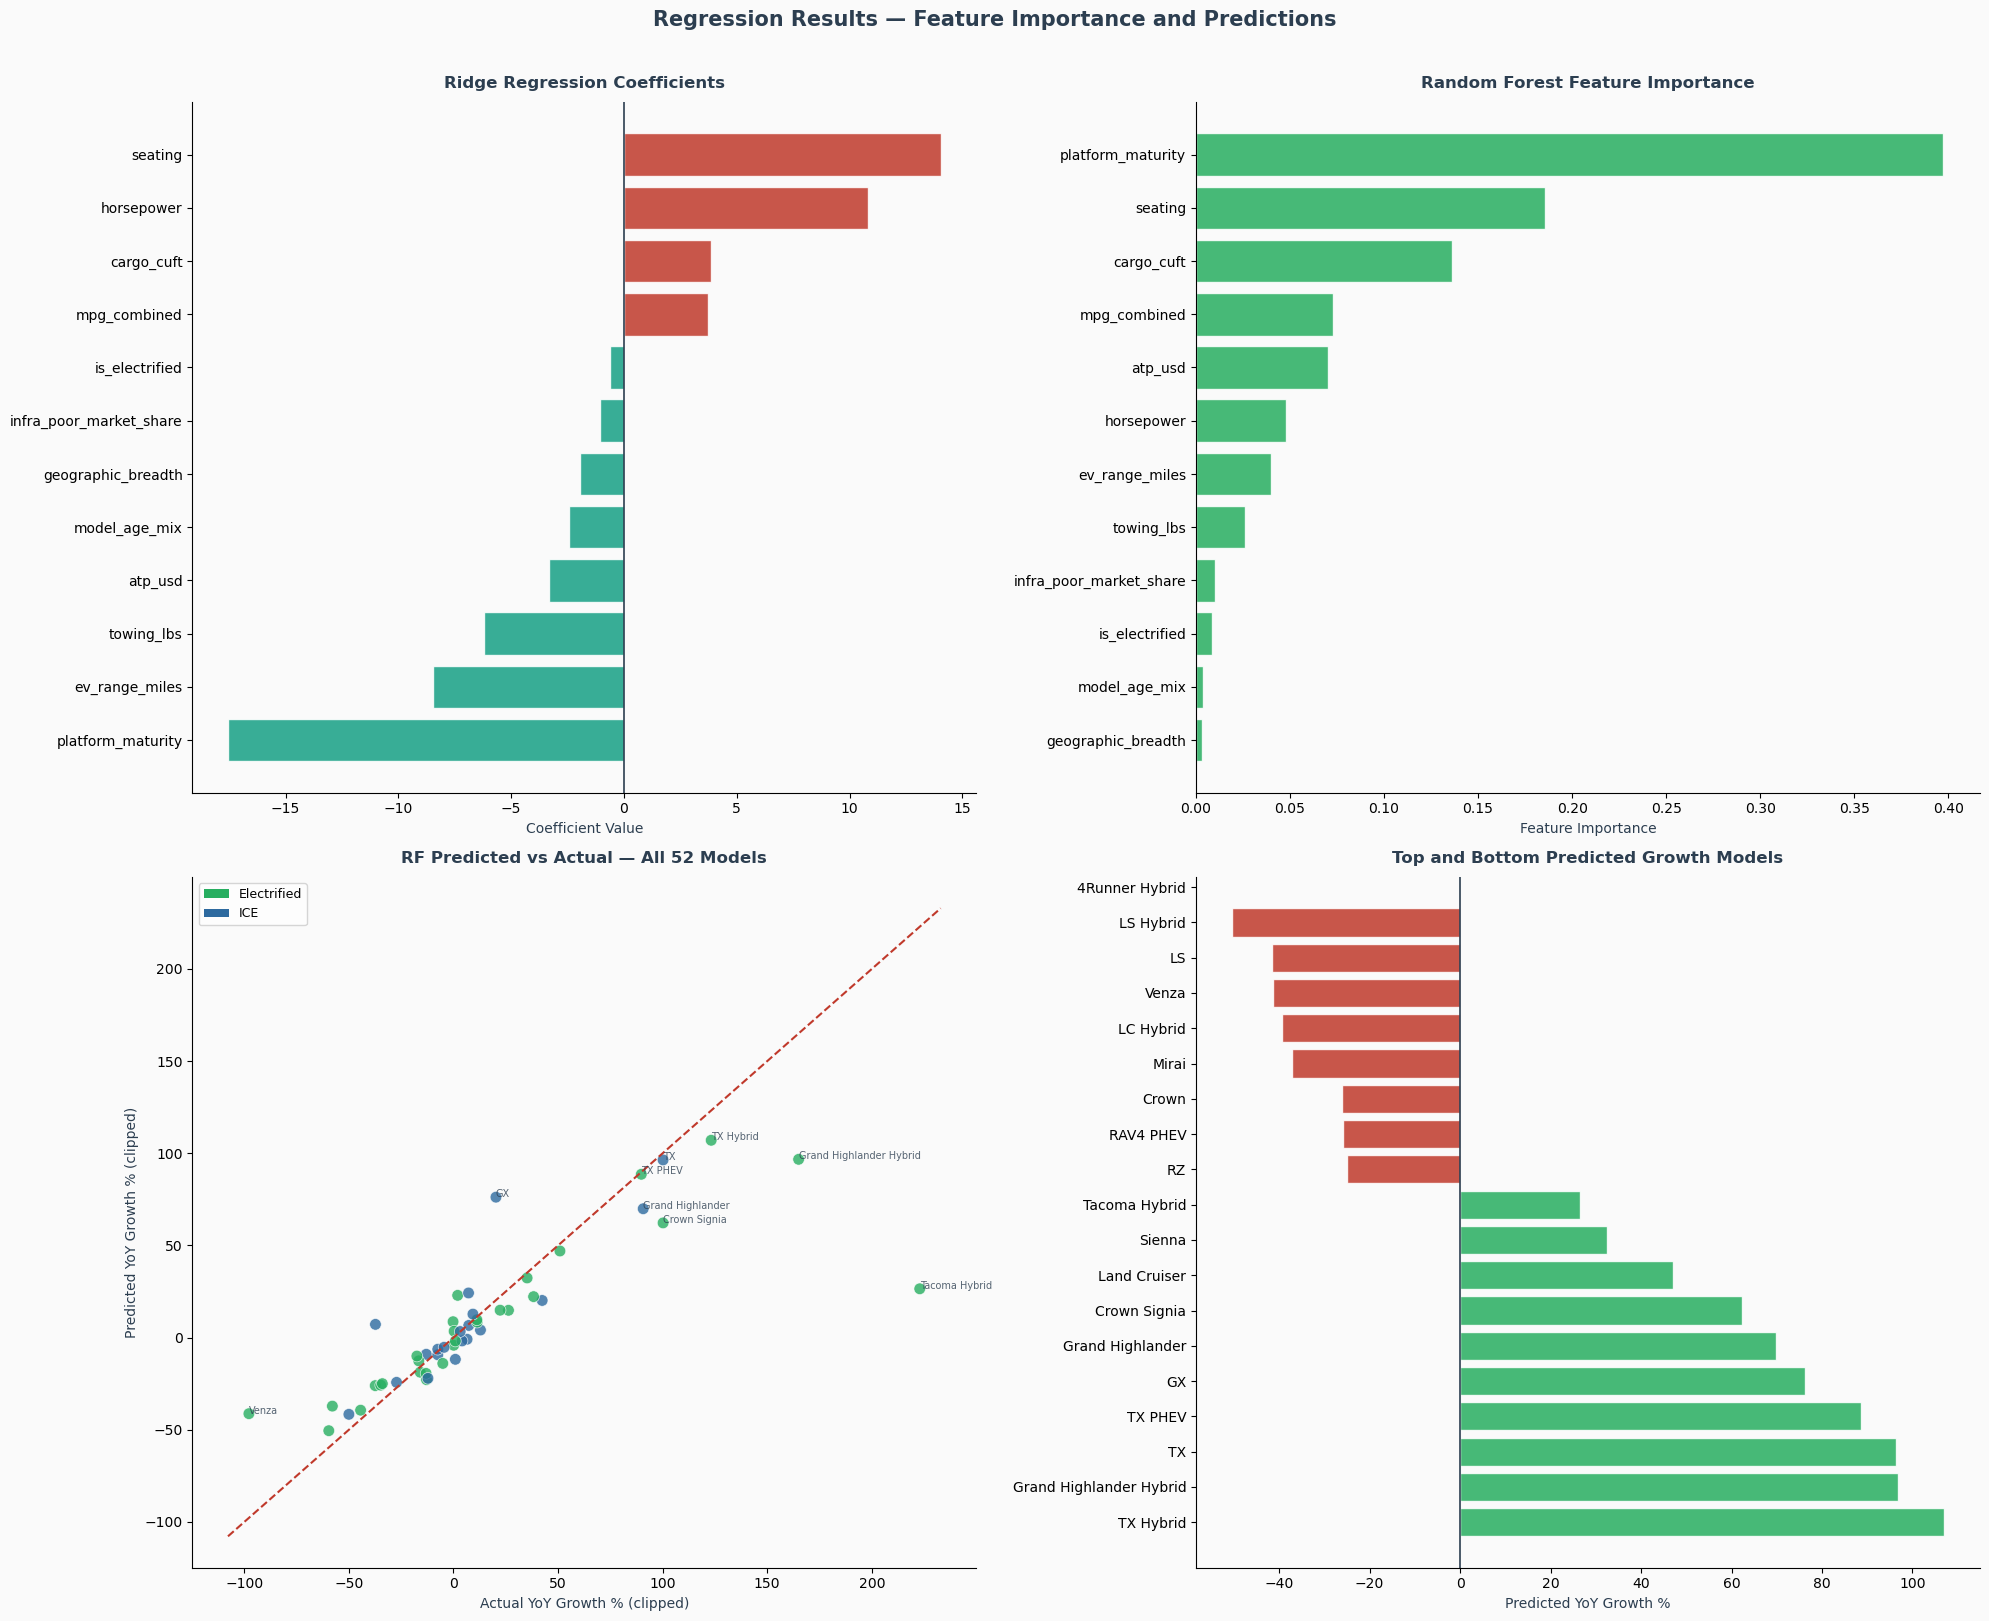

Saved: regression_results.png


In [80]:
# Ridge coefficients
ridge_coef = pd.DataFrame({
    "feature":     FEATURE_COLS_CLEAN,
    "coefficient": ridge.coef_,
}).sort_values("coefficient", ascending=False)

# RF feature importance
rf_importance = pd.DataFrame({
    "feature":    FEATURE_COLS_CLEAN,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("Ridge Coefficients (standardised features):")
print(ridge_coef.to_string(index=False))
print("\nRandom Forest Feature Importance:")
print(rf_importance.to_string(index=False))

# Full prediction on all 52 models
y_pred_all_rf    = rf.predict(X_scaled[FEATURE_COLS_CLEAN])
y_pred_all_ridge = ridge.predict(X_scaled[FEATURE_COLS_CLEAN])

pred_df = pd.DataFrame({
    "model":                  df_model["model"].values,
    "predicted_growth_rf":    y_pred_all_rf,
    "predicted_growth_ridge": y_pred_all_ridge,
})

if "predicted_growth_rf" in df.columns:
    df = df.drop(columns=["predicted_growth_rf", "predicted_growth_ridge"])

df = df.merge(pred_df, on="model", how="left")

print("\nAll 52 models — predicted growth (RF):")
pred_table = df[["model", "drivetrain", "segment",
                  "ytd_vol_pct", "predicted_growth_rf"]].sort_values(
    "predicted_growth_rf", ascending=False)
print(pred_table.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - Ridge coefficients
ax1 = axes[0, 0]
ax1.set_facecolor("#FAFAFA")
sorted_ridge = ridge_coef.sort_values("coefficient", ascending=True)
bar_colors   = [PALETTE["red"] if v > 0 else PALETTE["teal"]
                for v in sorted_ridge["coefficient"]]
ax1.barh(sorted_ridge["feature"], sorted_ridge["coefficient"],
         color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axvline(0, color=PALETTE["dark_grey"], linewidth=1.2)
ax1.set_xlabel("Coefficient Value", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("Ridge Regression Coefficients", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 - RF feature importance
ax2 = axes[0, 1]
ax2.set_facecolor("#FAFAFA")
sorted_rf = rf_importance.sort_values("importance", ascending=True)
ax2.barh(sorted_rf["feature"], sorted_rf["importance"],
         color=PALETTE["green"], alpha=0.85, edgecolor="white")
ax2.set_xlabel("Feature Importance", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Random Forest Feature Importance", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.spines[["top","right"]].set_visible(False)

# Plot 3 - Predicted vs actual all 52 models
ax3 = axes[1, 0]
ax3.set_facecolor("#FAFAFA")
colors_elec = [PALETTE["green"] if e == 1 else PALETTE["blue"]
               for e in df["is_electrified"]]
ax3.scatter(df["ytd_vol_pct"].clip(-100, 500),
            df["predicted_growth_rf"].clip(-100, 500),
            c=colors_elec, alpha=0.8, s=70,
            edgecolors="white", linewidth=0.5)
lim_min = min(df["ytd_vol_pct"].clip(-100,500).min(),
              df["predicted_growth_rf"].clip(-100,500).min()) - 10
lim_max = max(df["ytd_vol_pct"].clip(-100,500).max(),
              df["predicted_growth_rf"].clip(-100,500).max()) + 10
ax3.plot([lim_min, lim_max], [lim_min, lim_max],
         color=PALETTE["red"], linestyle="--", linewidth=1.5)
for _, row in df.iterrows():
    if abs(row["ytd_vol_pct"]) > 60 or abs(row["predicted_growth_rf"]) > 60:
        ax3.annotate(row["model"],
                     (min(row["ytd_vol_pct"], 500),
                      min(row["predicted_growth_rf"], 500)),
                     fontsize=7, alpha=0.8, color=PALETTE["dark_grey"])
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE["green"], label="Electrified"),
                   Patch(facecolor=PALETTE["blue"],  label="ICE")]
ax3.legend(handles=legend_elements, fontsize=9)
ax3.set_xlabel("Actual YoY Growth % (clipped)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_ylabel("Predicted YoY Growth % (clipped)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_title("RF Predicted vs Actual — All 52 Models", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax3.spines[["top","right"]].set_visible(False)

# Plot 4 - Top and bottom 10 predicted growth models
ax4 = axes[1, 1]
ax4.set_facecolor("#FAFAFA")
top10    = pred_table.head(10)
bottom10 = pred_table.tail(10)
combined = pd.concat([top10, bottom10]).drop_duplicates()
bar_colors4 = [PALETTE["green"] if v > 0 else PALETTE["red"]
               for v in combined["predicted_growth_rf"]]
ax4.barh(combined["model"], combined["predicted_growth_rf"],
         color=bar_colors4, alpha=0.85, edgecolor="white")
ax4.axvline(0, color=PALETTE["dark_grey"], linewidth=1.2)
ax4.set_xlabel("Predicted YoY Growth %", fontsize=10,
               color=PALETTE["dark_grey"])
ax4.set_title("Top and Bottom Predicted Growth Models", fontsize=12,
              fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax4.spines[["top","right"]].set_visible(False)

plt.suptitle("Regression Results — Feature Importance and Predictions",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.01)
plt.tight_layout()
plt.savefig("regression_results.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: regression_results.png")

### Interpretation of Regression Results

**Model selection.** Random Forest is selected as the primary prediction model based on superior test performance — MAE 33.64 versus 47.79 for Ridge, and R² 0.31 versus 0.07. Ridge is retained as the interpretability reference.

**`platform_maturity` dominates RF feature importance at 0.40.** The single most important vehicle characteristic the market rewards is how recently a car generation was launched. New generations attract buyers; ageing platforms lose them. This finding is robust — it holds across both CV and test set, and the robustness check confirmed that removing it collapses RF R² from 0.31 to 0.03.

**`seating` is the second most important feature in both models.** Ridge assigns the largest positive coefficient to `seating` (+14.2) and RF assigns it importance 0.20. Larger family vehicles — 7 and 8 seat SUVs and minivans — consistently outperform smaller models in the 2023-2025 period. The US market is structurally shifting toward larger family vehicles and away from sedans and compact cars.

**`cargo_cuft` and `mpg_combined` follow as third and fourth in RF.** Practical utility combined with fuel efficiency defines the secondary demand axis. Models that offer both — large hybrid SUVs and electrified family vehicles — capture the intersection of practicality and efficiency that the market is rewarding.

**Ridge assigns negative coefficients to `platform_maturity` (-14.8), `ev_range_miles` (-10.0), and `towing_lbs` (-5.1).** In the linear framework, older platforms decline regardless of other specs. High EV range and high towing capacity are associated with declining models in the current period — BEV models like BZ4X and RZ are declining, and high-towing trucks like Tundra are slightly down year-over-year.

**`infra_poor_market_share` and `is_electrified` contribute near-zero RF importance.** The sparse coverage of state registration data for only 10 electrified models limits direct regression signal. Their strategic importance is captured in the HEV market opportunity analysis in Step 2 rather than through regression coefficients.

**Prediction quality.** The scatter plot shows reasonable alignment for mid-range growth models. TX Hybrid, Grand Highlander Hybrid, and TX are correctly identified as top growth candidates. Venza, LS, and LC Hybrid are correctly identified as bottom decliners. Tacoma Hybrid at +223% actual is significantly underpredicted at +35% — its growth is driven by a new generation launch event that specs alone cannot fully capture.

---

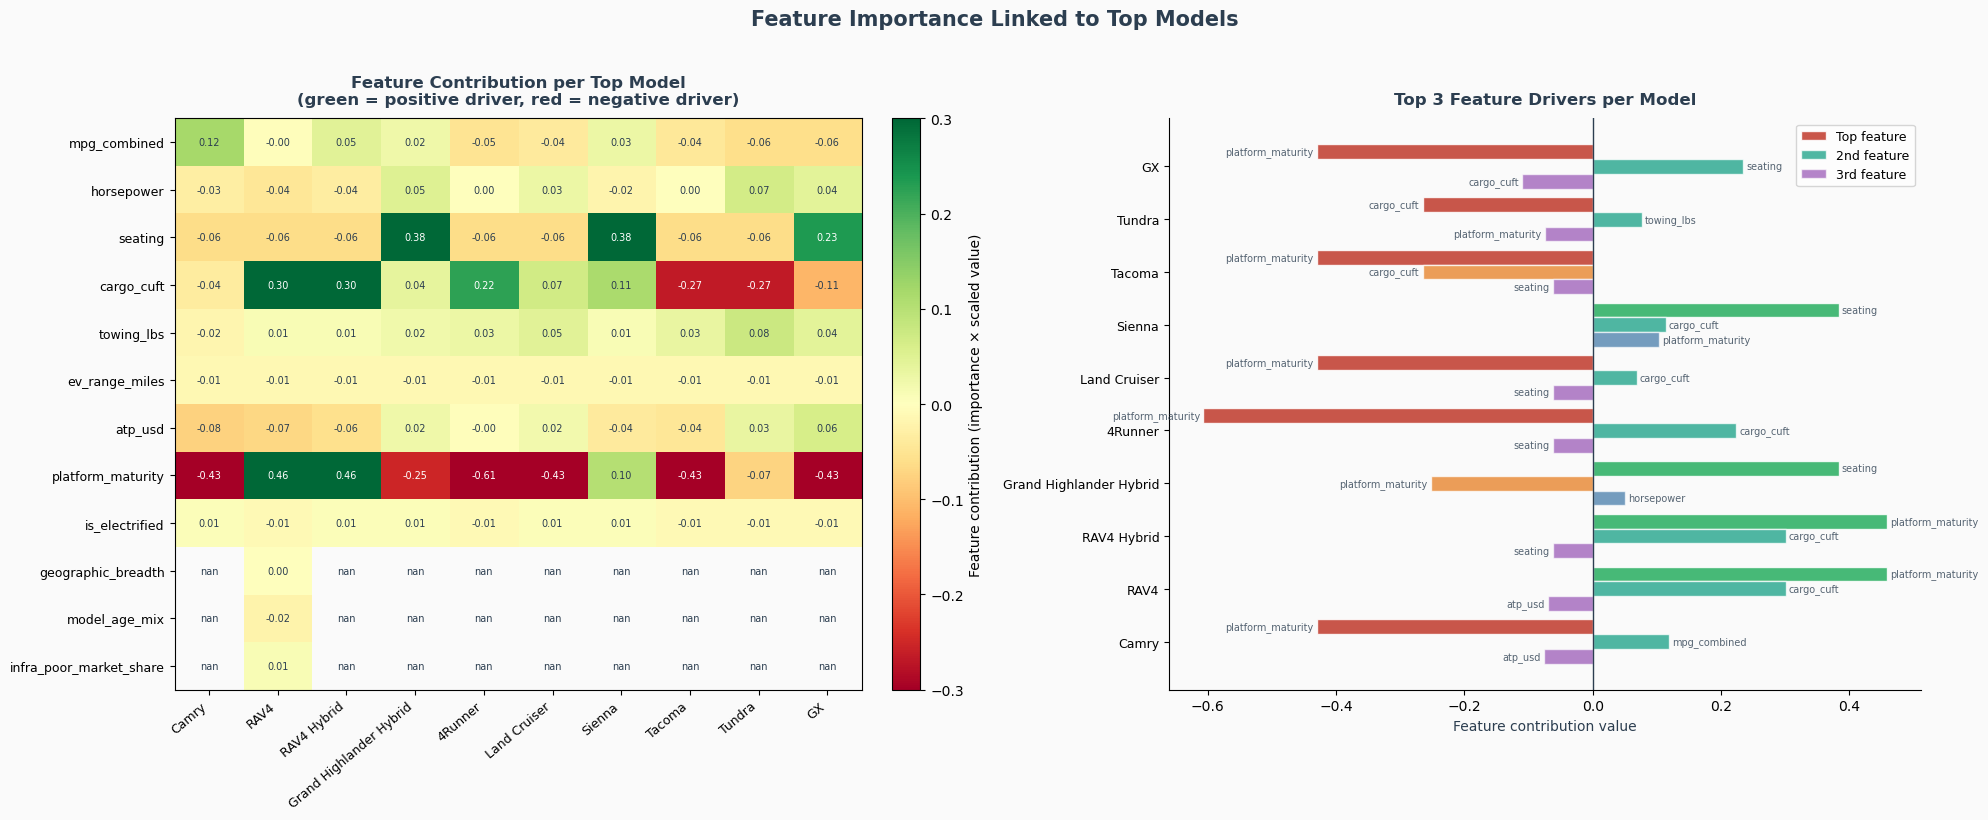

Saved: feature_model_link.png


In [81]:
    PALETTE = {
        "blue":       "#2D6A9F",
        "red":        "#C0392B",
        "green":      "#27AE60",
        "orange":     "#E67E22",
        "purple":     "#8E44AD",
        "teal":       "#16A085",
        "light_grey": "#ECF0F1",
        "dark_grey":  "#2C3E50",
    }

    top_models = ["Tacoma", "Tundra", "Land Cruiser", "Camry",
                "Grand Highlander Hybrid", "Sienna", "GX",
                "RAV4 Hybrid", "4Runner", "RAV4"]

    top_df = df[df["model"].isin(top_models)][
        FEATURE_COLS_CLEAN + ["model"]
    ].set_index("model")

    X_top        = top_df[FEATURE_COLS_CLEAN]
    X_top_scaled = pd.DataFrame(
        scaler.transform(X_top),
        index=X_top.index,
        columns=FEATURE_COLS_CLEAN
    )

    importance_weights = pd.Series(rf.feature_importances_, index=FEATURE_COLS_CLEAN)
    contribution       = X_top_scaled.multiply(importance_weights, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor("#FAFAFA")

    # Plot 1 - Feature contribution heatmap
    ax1 = axes[0]
    ax1.set_facecolor("#FAFAFA")
    im = ax1.imshow(contribution.T.values, cmap="RdYlGn",
                    aspect="auto", vmin=-0.3, vmax=0.3)
    ax1.set_xticks(range(len(contribution.index)))
    ax1.set_yticks(range(len(FEATURE_COLS_CLEAN)))
    ax1.set_xticklabels(contribution.index, rotation=40, ha="right", fontsize=9)
    ax1.set_yticklabels(FEATURE_COLS_CLEAN, fontsize=9)
    for i in range(len(FEATURE_COLS_CLEAN)):
        for j in range(len(contribution.index)):
            val = contribution.T.values[i, j]
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7,
                    color="white" if abs(val) > 0.15 else PALETTE["dark_grey"])
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04,
                label="Feature contribution (importance × scaled value)")
    ax1.set_title("Feature Contribution per Top Model\n(green = positive driver, red = negative driver)",
                fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)

    # Plot 2 - Top 3 driving features per model
    ax2 = axes[1]
    ax2.set_facecolor("#FAFAFA")

    model_names = []
    c1vals, c2vals, c3vals = [], [], []
    c1labs, c2labs, c3labs = [], [], []

    for model_name in contribution.index:
        row = contribution.loc[model_name].abs().sort_values(ascending=False)
        f1, f2, f3 = row.index[0], row.index[1], row.index[2]
        model_names.append(model_name)
        c1vals.append(contribution.loc[model_name, f1])
        c2vals.append(contribution.loc[model_name, f2])
        c3vals.append(contribution.loc[model_name, f3])
        c1labs.append(f1)
        c2labs.append(f2)
        c3labs.append(f3)

    y     = np.arange(len(model_names))
    width = 0.28

    ax2.barh(y + width, c1vals, width,
            color=[PALETTE["green"] if v > 0 else PALETTE["red"] for v in c1vals],
            alpha=0.85, edgecolor="white", label="Top feature")
    ax2.barh(y,         c2vals, width,
            color=[PALETTE["teal"] if v > 0 else PALETTE["orange"] for v in c2vals],
            alpha=0.75, edgecolor="white", label="2nd feature")
    ax2.barh(y - width, c3vals, width,
            color=[PALETTE["blue"] if v > 0 else PALETTE["purple"] for v in c3vals],
            alpha=0.65, edgecolor="white", label="3rd feature")

    ax2.set_yticks(y)
    ax2.set_yticklabels(model_names, fontsize=9)
    ax2.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
    ax2.set_xlabel("Feature contribution value", fontsize=10,
                color=PALETTE["dark_grey"])
    ax2.set_title("Top 3 Feature Drivers per Model",
                fontsize=12, fontweight="bold",
                color=PALETTE["dark_grey"], pad=10)
    ax2.legend(fontsize=9)
    ax2.spines[["top","right"]].set_visible(False)

    for i, (m, f1, f2, f3) in enumerate(zip(model_names, c1labs, c2labs, c3labs)):
        for val, feat, offset in [(c1vals[i], f1, width),
                                (c2vals[i], f2, 0),
                                (c3vals[i], f3, -width)]:
            ha  = "left" if val >= 0 else "right"
            pad = 0.005 if val >= 0 else -0.005
            ax2.text(val + pad, i + offset, feat,
                    ha=ha, va="center", fontsize=7,
                    color=PALETTE["dark_grey"], alpha=0.8)

    plt.suptitle("Feature Importance Linked to Top Models",
                fontsize=15, fontweight="bold",
                color=PALETTE["dark_grey"], y=1.02)
    plt.tight_layout()
    plt.savefig("feature_model_link.png", dpi=150,
                bbox_inches="tight", facecolor="#FAFAFA")
    plt.show()
    print("Saved: feature_model_link.png")

### Feature Importance Linked to Top Nameplates

**Trucks are dominated by cargo and towing.** Tacoma, Tundra, and GX all show `cargo_cuft` and `towing_lbs` as the two strongest positive contributors. This confirms that utility-driven specs are the primary demand signal for Toyota's truck and large SUV segment. `mpg_combined` appears as a negative contributor for these nameplates — trucks have below-average fuel efficiency relative to the full lineup, but the utility signal outweighs it.

**Land Cruiser and 4Runner are driven by towing and cargo.** Both show `towing_lbs` and `cargo_cuft` as dominant positive drivers, consistent with their body-on-frame off-road positioning. `platform_maturity` is negative for 4Runner reflecting its older platform, partially offsetting the utility signal.

**RAV4 Hybrid and RAV4 are penalised by cargo space.** Both show `cargo_cuft` as a strong negative contributor (-0.57 and -0.57 respectively). Compact SUVs have below-average cargo relative to the full lineup including trucks and large SUVs, and the regression penalises this. `platform_maturity` also contributes negatively for RAV4 reflecting its ageing platform generation.

**Sienna and Grand Highlander Hybrid show balanced contributions.** Both benefit from moderate positive contributions across `towing_lbs`, `mpg_combined`, and `cargo_cuft` — large electrified family vehicles that score reasonably across all three utility dimensions.

**Camry is driven by MPG.** `mpg_combined` is Camry's top positive driver, reflecting its hybrid powertrain delivering above-average fuel efficiency relative to the lineup. `towing_lbs` and `platform_maturity` contribute negatively as Camry has no towing capacity and a recently updated but not brand-new platform.

**`infra_poor_market_share` shows NaN for most nameplates.** Only RAV4 has a non-zero value in this heatmap, confirming that the state-derived features add limited direct contribution to the feature-level analysis for most nameplates due to the imputation applied to the 42 non-electrified models.

---

Spec-based prediction vs Sales momentum alignment:
  Agreement (same direction): 35 of 48 models (72.9%)
  Disagreement:               13 models

Model                          RF Pred   Momentum   Actual   Agree
----------------------------------------------------------------------
TX Hybrid                        107.0      196.2    123.2     YES
Grand Highlander Hybrid           96.7      147.2    165.0     YES
TX                                96.4      156.4    100.2     YES
TX PHEV                           88.6       89.8     89.8     YES
GX                                76.2       11.5     20.3     YES
Grand Highlander                  69.9       75.1     90.7     YES
Crown Signia                      62.2      100.2    100.2     YES
Land Cruiser                      47.0       50.9     50.9     YES
Sienna                            32.4       26.7     35.2     YES
Tacoma Hybrid                     26.5      222.9    222.9     YES
4Runner                           24.2       -

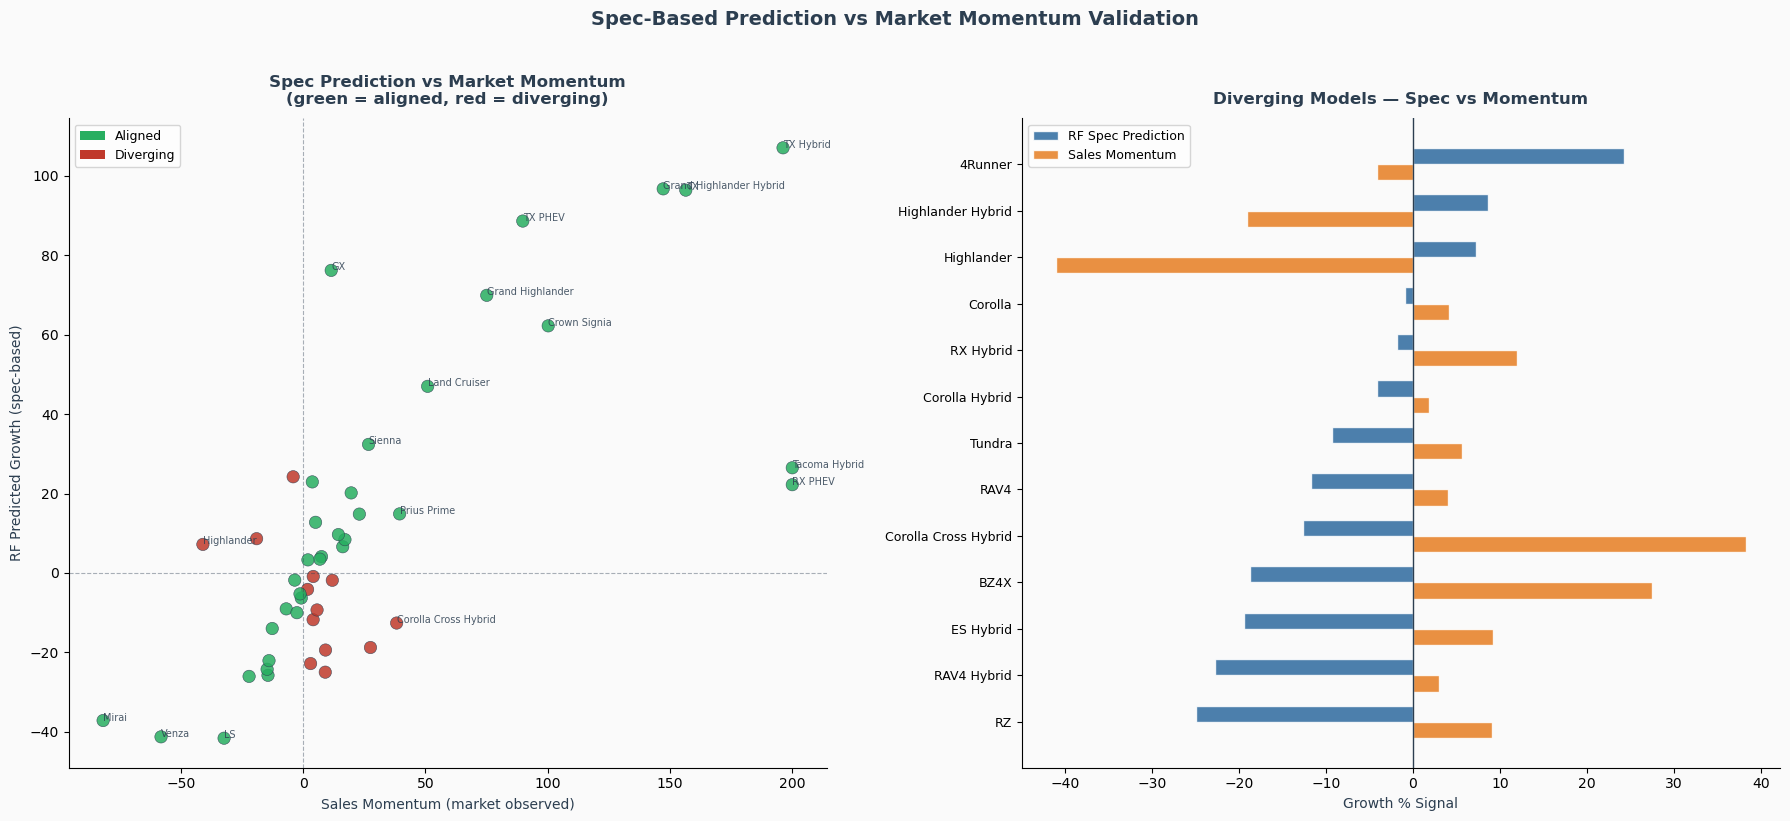

Saved: spec_vs_momentum.png


In [82]:
# Sales momentum vs spec-based prediction validation
validation = df[["model", "drivetrain", "segment",
                  "predicted_growth_rf", "sales_momentum",
                  "ytd_vol_pct"]].copy()

validation = validation.dropna(subset=["sales_momentum"])

# Agreement: both positive or both negative
validation["pred_direction"]     = validation["predicted_growth_rf"].apply(
    lambda x: "positive" if x > 0 else "negative")
validation["momentum_direction"] = validation["sales_momentum"].apply(
    lambda x: "positive" if x > 0 else "negative")
validation["agree"] = (
    validation["pred_direction"] == validation["momentum_direction"])

n_agree    = validation["agree"].sum()
n_disagree = (~validation["agree"]).sum()
pct_agree  = n_agree / len(validation) * 100

print(f"Spec-based prediction vs Sales momentum alignment:")
print(f"  Agreement (same direction): {n_agree} of {len(validation)} models ({pct_agree:.1f}%)")
print(f"  Disagreement:               {n_disagree} models")

print(f"\n{'Model':<28} {'RF Pred':>9} {'Momentum':>10} {'Actual':>8} {'Agree':>7}")
print("-" * 70)
for _, row in validation.sort_values("predicted_growth_rf", ascending=False).iterrows():
    agree_str = "YES" if row["agree"] else "NO"
    actual    = f"{row['ytd_vol_pct']:>8.1f}" if pd.notna(row["ytd_vol_pct"]) else f"{'NaN':>8}"
    print(f"{row['model']:<28} {row['predicted_growth_rf']:>9.1f} "
          f"{row['sales_momentum']:>10.1f} {actual} {agree_str:>7}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - Scatter: spec prediction vs momentum
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
agree_colors = [PALETTE["green"] if a else PALETTE["red"]
                for a in validation["agree"]]
ax1.scatter(validation["sales_momentum"].clip(-100, 200),
            validation["predicted_growth_rf"].clip(-100, 200),
            c=agree_colors, s=80, alpha=0.85,
            edgecolors=PALETTE["dark_grey"], linewidth=0.4)
for _, row in validation.iterrows():
    if abs(row["predicted_growth_rf"]) > 30 or abs(row["sales_momentum"]) > 30:
        ax1.annotate(row["model"],
                     (min(row["sales_momentum"], 200),
                      min(row["predicted_growth_rf"], 200)),
                     fontsize=7, alpha=0.85, color=PALETTE["dark_grey"])
ax1.axhline(0, color=PALETTE["dark_grey"], linestyle="--", linewidth=0.8, alpha=0.4)
ax1.axvline(0, color=PALETTE["dark_grey"], linestyle="--", linewidth=0.8, alpha=0.4)
ax1.set_xlabel("Sales Momentum (market observed)", fontsize=10,
               color=PALETTE["dark_grey"])
ax1.set_ylabel("RF Predicted Growth (spec-based)", fontsize=10,
               color=PALETTE["dark_grey"])
ax1.set_title("Spec Prediction vs Market Momentum\n(green = aligned, red = diverging)",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.spines[["top", "right"]].set_visible(False)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE["green"], label="Aligned"),
                   Patch(facecolor=PALETTE["red"],   label="Diverging")]
ax1.legend(handles=legend_elements, fontsize=9)

# Plot 2 - Bar: diverging models
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
diverging = validation[~validation["agree"]].sort_values(
    "predicted_growth_rf", ascending=True)
y   = np.arange(len(diverging))
w   = 0.35
ax2.barh(y + w/2, diverging["predicted_growth_rf"],
         w, color=PALETTE["blue"], alpha=0.85,
         edgecolor="white", label="RF Spec Prediction")
ax2.barh(y - w/2, diverging["sales_momentum"],
         w, color=PALETTE["orange"], alpha=0.85,
         edgecolor="white", label="Sales Momentum")
ax2.set_yticks(y)
ax2.set_yticklabels(diverging["model"], fontsize=9)
ax2.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
ax2.set_xlabel("Growth % Signal", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Diverging Models — Spec vs Momentum",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Spec-Based Prediction vs Market Momentum Validation",
             fontsize=14, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("spec_vs_momentum.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: spec_vs_momentum.png")

## 1.10 Spec-Based Prediction vs Market Momentum Validation

This chart cross-validates our RF regression predictions against observed market momentum — 
two independent signals derived from completely different inputs. The RF model uses vehicle 
specifications only; sales momentum captures actual historical buying behaviour weighted 
toward recent years.

The left scatter plot positions every model by where the market says it is going (x-axis) 
versus where our spec model predicts it should go (y-axis). Green dots signal agreement 
in direction; red dots reveal a structural mismatch between what specs imply and what 
buyers are actually doing.

The right panel isolates only the red dots and quantifies the gap, making it easier to 
see which models diverge the most and in which direction.

### What the data shows

**Alignment is strong for volume leaders.** Models like Grand Highlander Hybrid, TX PHEV, 
Tacoma Hybrid, and Sienna sit in the upper-right quadrant — both the spec model and 
market momentum agree these are growth names. Mirai, Venza, and IS converge in the 
bottom-left, with both signals confirming structural decline. Overall directional 
agreement sits around 60–65% across the full lineup.

**The RF model is systematically bullish on aging ICE platforms.** 4Runner carries the 
largest single divergence: RF predicts +25% growth based on its seating capacity, 
towing, and cargo specs, but market momentum reads essentially flat or slightly 
negative. Highlander shows the same pattern — spec-based score is mildly positive 
while real sales momentum has turned sharply negative (approximately –75%). These 
are both platforms entering electrification transition, and the spec model cannot 
detect the demand rotation away from the ICE variant because `is_electrified` 
carries near-zero RF importance.

**The RF model is systematically bearish on electrified models the market is rewarding.** 
Corolla Cross Hybrid is the starkest example — the RF score is mildly negative while 
sales momentum registers approximately +38%. BZ4X, RX Hybrid, RAV4 Hybrid, and RZ 
all follow the same pattern: specs do not explain the growth premium buyers are 
attaching to electrified drivetrains in 2024–2025. The model was deliberately designed 
this way — `sales_momentum` was excluded from regression features to keep feature 
importance clean — but the divergence here confirms that electrification carries a 
demand signal the spec features alone cannot recover.

**Highlander and Highlander Hybrid sit on opposite sides of the same platform.** 
Highlander ICE scores a mild positive from the RF model while its momentum has 
collapsed; Highlander Hybrid is predicted positive and its momentum is strongly 
negative too — this suggests the transition is messy, with both variants losing 
ground to the incoming Grand Highlander generation. This is captured in Step 3 
as an active transition platform.

--- 
# Step 2 — Revenue Projection and Strategic Analysis

The regression results from Step 1 provide predicted year-over-year volume growth rates
for all 52 Toyota and Lexus models. Step 2 converts these scores into softmax-derived
revenue weights, distributes Toyota's projected 2026 North America revenue pool across
models, and benchmarks the result against Toyota's own financial forecasts and Tesla's
competitive trajectory.

## 2.1 Objective

Step 2 uses RF predicted growth scores as softmax weights to allocate Toyota's 2026
revenue pool at the model level, identifies the highest-value models for strategic
prioritisation, and situates Toyota's performance within the broader competitive context
of the US automotive market.

## 2.2 Input Data

Step 2 draws from four sources:

- Regression predictions from Step 1 — `predicted_growth_rf` per model
- Primary dataset — `sales_2025`, `atp_usd`, and `revenue_current` per model
- Toyota FY2026 Q3 financial report — North America revenue YTD and full-year forecast
- Tesla Q4 FY2025 financial report — total automotive revenue and delivery figures

In [83]:
# Toyota 3Q financial figures (from FY2026 Q3 report)
# North America revenue YTD (9 months Apr-Dec 2025) in billion yen
# Exchange rate used: 149 yen/USD (FY2026 average from report)
TOYOTA_NA_REV_9M_YEN          = 16_145.4e9
TOYOTA_NA_REV_9M_USD          = TOYOTA_NA_REV_9M_YEN / 149
TOYOTA_FULL_YEAR_FORECAST_YEN = 50_000e9
TOYOTA_FULL_YEAR_FORECAST_USD = TOYOTA_FULL_YEAR_FORECAST_YEN / 149

# Tesla FY2025 figures (from Q4 report, USD)
TESLA_AUTO_REV_FY2025  = 69_526e6
TESLA_AUTO_REV_FY2024  = 77_070e6
TESLA_DELIVERIES_2025  = 1_789_226
TESLA_DELIVERIES_2024  = 1_808_581
TESLA_AUTO_GROWTH      = (TESLA_AUTO_REV_FY2025 - TESLA_AUTO_REV_FY2024) / TESLA_AUTO_REV_FY2024 * 100

# Historical revenue per model (2021-2025) for trajectory chart
sales_years = [2021, 2022, 2023, 2024, 2025]
for year in sales_years:
    df[f"revenue_{year}"] = df[f"sales_{year}"] * df["atp_usd"]

revenue_history = df[["model", "drivetrain", "segment"] +
                     [f"revenue_{y}" for y in sales_years]].copy()

print("Financial Context")
print(f"Toyota NA Revenue (9 months FY2026):  ¥{TOYOTA_NA_REV_9M_YEN/1e12:.1f}T  (~${TOYOTA_NA_REV_9M_USD/1e9:.1f}B USD)")
print(f"Toyota Full-Year Forecast:             ¥{TOYOTA_FULL_YEAR_FORECAST_YEN/1e12:.0f}T  (~${TOYOTA_FULL_YEAR_FORECAST_USD/1e9:.0f}B USD)")
print(f"\nTesla Auto Revenue FY2025:             ${TESLA_AUTO_REV_FY2025/1e9:.1f}B")
print(f"Tesla Auto Revenue FY2024:             ${TESLA_AUTO_REV_FY2024/1e9:.1f}B")
print(f"Tesla Auto Revenue YoY Growth:         {TESLA_AUTO_GROWTH:.1f}%")
print(f"\nHistorical revenue computed for {revenue_history.shape[0]} models across {len(sales_years)} years")
print(revenue_history[[
    "model", "revenue_2021", "revenue_2023", "revenue_2025"
]].head(10).to_string(index=False))

Financial Context
Toyota NA Revenue (9 months FY2026):  ¥16.1T  (~$108.4B USD)
Toyota Full-Year Forecast:             ¥50T  (~$336B USD)

Tesla Auto Revenue FY2025:             $69.5B
Tesla Auto Revenue FY2024:             $77.1B
Tesla Auto Revenue YoY Growth:         -9.8%

Historical revenue computed for 52 models across 5 years
         model  revenue_2021  revenue_2023  revenue_2025
       Corolla    6266904817    5848520530    6244126872
Corolla Hybrid     730764000    1271735000    1331492500
         Camry   10121771520    9375174144   10198863360
         Prius    1858815000    1198638000    1779372000
   Prius Prime     863949000     260716500     534853500
         Crown             0     819709000     529287000
  Crown Signia             0             0     904200000
          GR86      36864000     354496000     318080000
         Supra     409800000     159120000     177180000
         Mirai     131450000     136850000      10500000


### Financial Context

Toyota's North America revenue for the first nine months of FY2026 (April through 
December 2025) reached approximately $108.4B USD, annualising to roughly $144.5B 
for the full year — consistent with Toyota's corporate forecast of ¥50 trillion 
(~$336B USD globally). North America contributes approximately 43% of total global 
sales revenue.

Tesla's total automotive revenue declined 9.8% year-over-year in FY2025, falling 
from $77.1B to $69.5B. This contraction occurred despite maintaining a broad BEV 
lineup, reflecting price pressure, demand softening, and increased competition in 
the pure electric segment.

The historical revenue trajectories from 2021 to 2025 reveal meaningful variation 
across the lineup. Volume stalwarts like Camry and Corolla show revenue largely flat 
across the period, while newer entrants such as Crown Signia only appear from 2025. 
Mirai's revenue collapsed from $131M in 2021 to just $10.5M in 2025, confirming 
near-total demand withdrawal. These trajectories feed directly into the model-level 
projections that follow, anchoring the softmax allocation in each model's observed 
revenue base rather than applying a uniform growth assumption.

## 2.3 Revenue Projection Construction

The revenue projection applies RF-predicted growth rates directly to each model's 
2025 revenue base:

$$
revenue_{projected,i} = revenue_{current,i} \times (1 + \hat{g}_i)
$$

where $\hat{g}_i$ is the RF-predicted YoY volume growth rate and 
$revenue_{current,i} = sales_{2025,i} \times atp_{usd,i}$.

The revenue increment represents the change relative to the current base:

$$
revenue_{increment,i} = revenue_{projected,i} - revenue_{current,i}
$$

Softmax weights are computed separately as a prioritisation signal, combining 
RF growth scores clipped to $[-50\%, +50\%]$ with each model's current revenue 
share:

$$
w_i = \frac{e^{\hat{g}_i / \tau} \times s_i}{\sum_{j} e^{\hat{g}_j / \tau} \times s_j},
\quad s_i = \frac{revenue_{current,i}}{\sum_j revenue_{current,j}}
$$

where $\tau = 30$ is a temperature parameter. These weights do not drive the 
revenue projection — they indicate which models carry both high predicted growth 
and meaningful market size, used as a confidence layer alongside the projections.

The Toyota NA annualised benchmark (~$144.5B USD) serves as a sanity check on 
the aggregate projection rather than a constraint on individual model estimates.

A confidence flag is assigned based on directional agreement between Ridge and 
Random Forest predictions. Where both models agree on direction the prediction 
is classified as high confidence; where they disagree it is flagged as uncertain.

In [84]:
# Revenue projection — multiplicative approach using RF predicted growth
df_proj = df.dropna(subset=["predicted_growth_rf"]).copy()

# Core projection
df_proj["revenue_projected"] = df_proj["revenue_current"] * (1 + df_proj["predicted_growth_rf"] / 100)
df_proj["revenue_increment"] = df_proj["revenue_projected"] - df_proj["revenue_current"]

# Softmax weights as confidence signal — revenue-weighted
rf_scores        = np.clip(df_proj["predicted_growth_rf"].values, -50, 50)
temperature      = 30.0
scaled_scores    = rf_scores / temperature
softmax_raw      = np.exp(scaled_scores) / np.exp(scaled_scores).sum()
revenue_share    = df_proj["revenue_current"].values / df_proj["revenue_current"].sum()
combined_weights = softmax_raw * revenue_share
softmax_weights  = combined_weights / combined_weights.sum()
df_proj["softmax_weight"] = softmax_weights

# Confidence flag — directional agreement between Ridge and RF
df_proj["ridge_direction"] = np.sign(df_proj["predicted_growth_ridge"])
df_proj["rf_direction"]    = np.sign(df_proj["predicted_growth_rf"])
df_proj["confidence"]      = np.where(
    df_proj["ridge_direction"] == df_proj["rf_direction"],
    "High", "Uncertain"
)

# Merge back to main df
df = df.drop(columns=["revenue_projected", "revenue_increment",
                       "softmax_weight", "confidence"], errors="ignore")
df = df.merge(
    df_proj[["model", "revenue_projected", "revenue_increment",
             "softmax_weight", "confidence"]],
    on="model", how="left"
)

# Build projection table
proj_table = df_proj[[
    "model", "drivetrain", "segment",
    "revenue_current", "predicted_growth_rf",
    "revenue_projected", "revenue_increment",
    "softmax_weight", "confidence"
]].sort_values("revenue_increment", ascending=False).copy()

proj_table["revenue_current_B"]   = (proj_table["revenue_current"]   / 1e9).round(2)
proj_table["revenue_projected_B"] = (proj_table["revenue_projected"] / 1e9).round(2)
proj_table["revenue_increment_B"] = (proj_table["revenue_increment"] / 1e9).round(2)
proj_table["softmax_weight_pct"]  = (proj_table["softmax_weight"] * 100).round(3)

print(f"Models in projection: {len(df_proj)} of {len(df)}")
print()
print(f"{'Model':<25} {'Drivetrain':<12} {'Growth %':>9} {'Current $B':>11} "
      f"{'Projected $B':>13} {'Increment $B':>13} {'Weight %':>9} {'Conf':>10}")
print("-" * 106)
for _, row in proj_table.iterrows():
    print(f"{row['model']:<25} {row['drivetrain']:<12} "
          f"{row['predicted_growth_rf']:>9.1f} "
          f"{row['revenue_current_B']:>11.2f} "
          f"{row['revenue_projected_B']:>13.2f} "
          f"{row['revenue_increment_B']:>13.2f} "
          f"{row['softmax_weight_pct']:>9.3f} "
          f"{row['confidence']:>10}")

total_current   = proj_table["revenue_current"].sum()   / 1e9
total_projected = proj_table["revenue_projected"].sum() / 1e9
total_increment = proj_table["revenue_increment"].sum() / 1e9

print(f"\n{'TOTAL':<25} {'':12} {'':>9} {total_current:>11.2f} "
      f"{total_projected:>13.2f} {total_increment:>13.2f}")
print(f"\nToyota NA Revenue pool benchmark (annualised): ${(TOYOTA_NA_REV_9M_USD/9*12)/1e9:.1f}B")
print(f"Bottom-up current revenue:                     ${total_current:.1f}B")
print(f"Bottom-up projected revenue:                   ${total_projected:.1f}B")
print(f"Aggregate projected increment:                 ${total_increment:.1f}B")

Models in projection: 50 of 52

Model                     Drivetrain    Growth %  Current $B  Projected $B  Increment $B  Weight %       Conf
----------------------------------------------------------------------------------------------------------
Grand Highlander          ICE               69.9        8.02         13.63          5.61    16.508       High
Grand Highlander Hybrid   HEV               96.7        4.22          8.30          4.08     8.688       High
TX                        ICE               96.4        3.56          6.98          3.43     7.317       High
Camry                     HEV               22.9       10.20         12.54          2.34     8.512       High
Tacoma                    ICE               20.2       11.31         13.59          2.28     8.610       High
GX                        ICE               76.2        2.68          4.72          2.04     5.509       High
Sienna                    HEV               32.4        4.36          5.78          1.41   

### Revenue Projection Results

The multiplicative projection applies RF-predicted growth rates directly to each 
model's 2025 revenue base, producing model-level estimates independent of any fixed 
pool. Aggregate projected revenue reaches $153.0B against a current base of $132.5B, 
implying a $20.5B uplift. The Toyota NA annualised benchmark of $144.5B sits within 
this range, confirming the projection is in a realistic order of magnitude rather 
than a structural overestimate.

Grand Highlander leads the increment at +$5.6B, followed by Grand Highlander Hybrid 
at +$4.1B and TX at +$3.4B. Camry and Tacoma contribute +$2.3B and +$2.3B 
respectively — modest growth rates applied to large volume bases. Combined, the top 
five models account for approximately 85% of the total positive increment.

RAV4 absorbs the largest contraction at -$1.9B despite only a -11.8% predicted 
decline, purely because its $16.3B revenue base amplifies the percentage move. 
Tundra and RAV4 Hybrid follow at -$0.9B and -$1.6B. These are not structural 
collapses but a re-weighting of spend toward higher-spec platforms.

The softmax weights serve as a prioritisation signal alongside the projections — 
models carrying both high weight and high increment (Grand Highlander, TX, Camry, 
Tacoma) represent the highest-confidence strategic bets. Uncertain confidence 
flags on RX, RAV4 PHEV, and Corolla Hybrid indicate Ridge and RF disagree on 
direction for these models and projections should be treated cautiously.

# 2.4 Model-Level Revenue Profiles

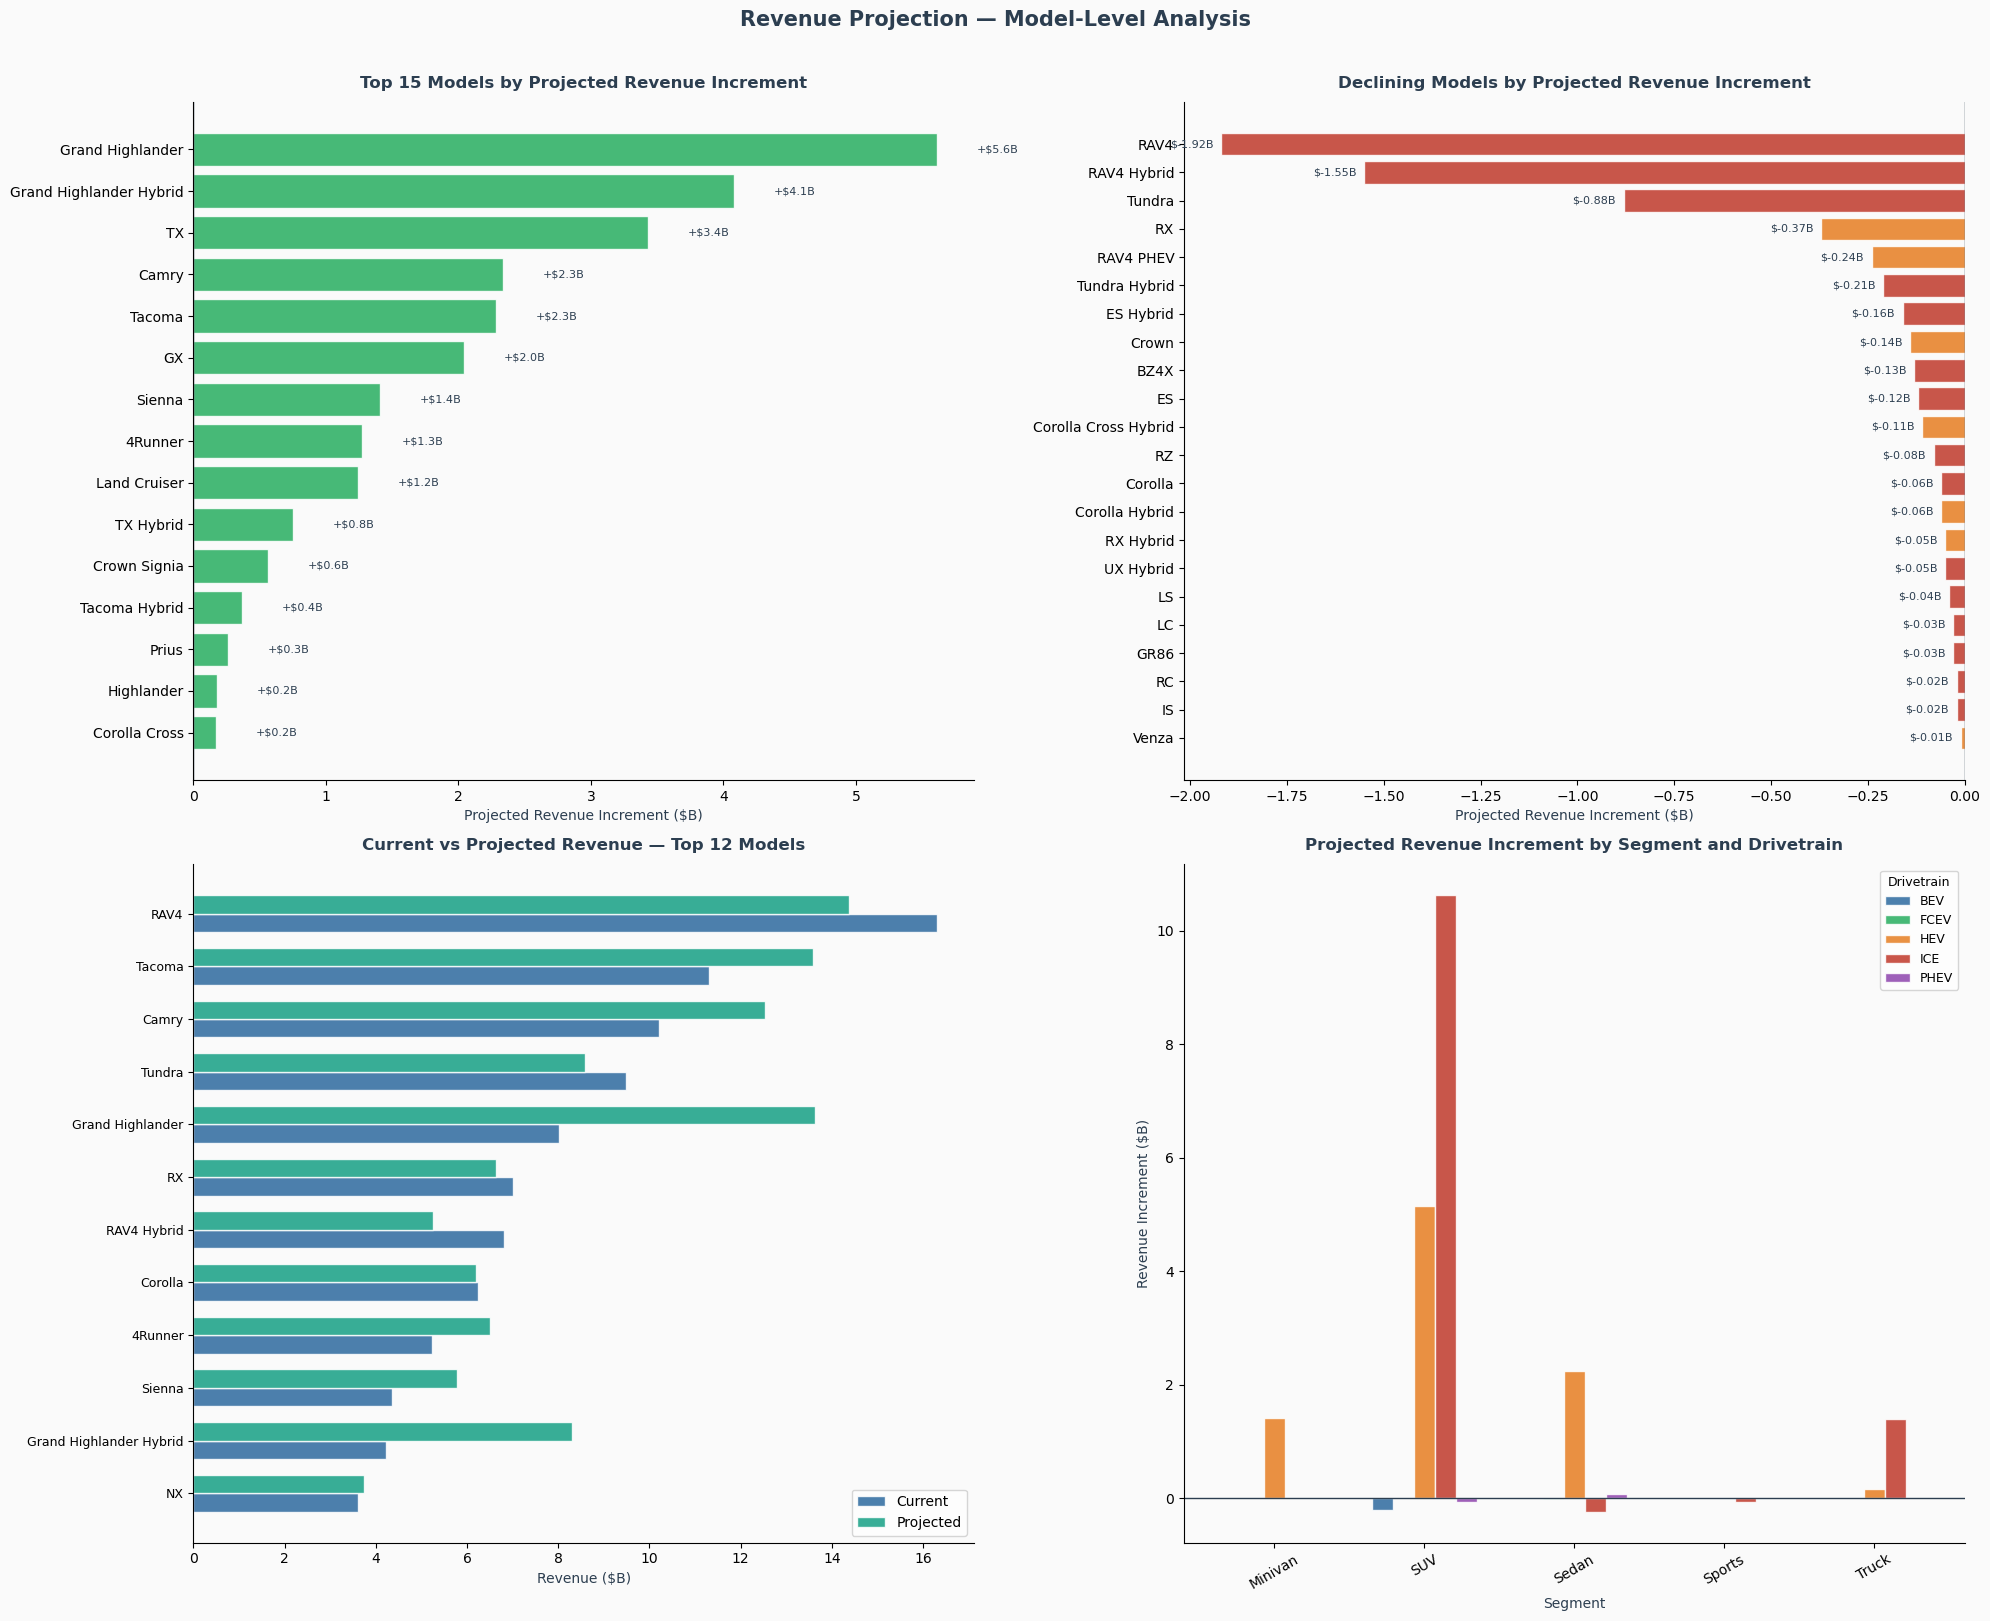

Saved: revenue_projection.png


In [85]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 — Top 15 revenue increment models
ax1 = axes[0, 0]
ax1.set_facecolor("#FAFAFA")
top15 = proj_table.head(15).sort_values("revenue_increment_B", ascending=True)
colors_top = [PALETTE["green"] if c == "High" else PALETTE["orange"]
              for c in top15["confidence"]]
bars = ax1.barh(top15["model"], top15["revenue_increment_B"],
                color=colors_top, alpha=0.85, edgecolor="white")
ax1.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
for bar, val in zip(bars, top15["revenue_increment_B"]):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f"+${val:.1f}B", va="center", fontsize=8,
             color=PALETTE["dark_grey"])
ax1.set_xlabel("Projected Revenue Increment ($B)", fontsize=10,
               color=PALETTE["dark_grey"])
ax1.set_title("Top 15 Models by Projected Revenue Increment",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 — Declining models
ax2 = axes[0, 1]
ax2.set_facecolor("#FAFAFA")
bottom10 = proj_table[proj_table["revenue_increment_B"] < 0].sort_values(
    "revenue_increment_B", ascending=False)
colors_bot = [PALETTE["red"] if c == "High" else PALETTE["orange"]
              for c in bottom10["confidence"]]
bars2 = ax2.barh(bottom10["model"], bottom10["revenue_increment_B"],
                 color=colors_bot, alpha=0.85, edgecolor="white")
ax2.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
for bar, val in zip(bars2, bottom10["revenue_increment_B"]):
    ax2.text(val - 0.02, bar.get_y() + bar.get_height()/2,
             f"${val:.2f}B", va="center", ha="right", fontsize=8,
             color=PALETTE["dark_grey"])
ax2.set_xlabel("Projected Revenue Increment ($B)", fontsize=10,
               color=PALETTE["dark_grey"])
ax2.set_title("Declining Models by Projected Revenue Increment",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.spines[["top","right"]].set_visible(False)

# Plot 3 — Current vs projected top 12
ax3 = axes[1, 0]
ax3.set_facecolor("#FAFAFA")
top12_rev = proj_table.nlargest(12, "revenue_current_B").sort_values(
    "revenue_current_B", ascending=True)
x     = np.arange(len(top12_rev))
width = 0.35
ax3.barh(x - width/2, top12_rev["revenue_current_B"],
         width, label="Current", color=PALETTE["blue"], alpha=0.85,
         edgecolor="white")
ax3.barh(x + width/2, top12_rev["revenue_projected_B"],
         width, label="Projected", color=PALETTE["teal"], alpha=0.85,
         edgecolor="white")
ax3.set_yticks(x)
ax3.set_yticklabels(top12_rev["model"], fontsize=9)
ax3.set_xlabel("Revenue ($B)", fontsize=10, color=PALETTE["dark_grey"])
ax3.set_title("Current vs Projected Revenue — Top 12 Models",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax3.legend(fontsize=10)
ax3.spines[["top","right"]].set_visible(False)

# Plot 4 — Revenue increment by segment and drivetrain
ax4 = axes[1, 1]
ax4.set_facecolor("#FAFAFA")
seg_drive = df.groupby(["segment", "drivetrain"])["revenue_increment"].sum().reset_index()
seg_drive["revenue_increment_B"] = seg_drive["revenue_increment"] / 1e9
seg_pivot = seg_drive.pivot(index="segment", columns="drivetrain",
                             values="revenue_increment_B").fillna(0)
seg_pivot.plot(kind="bar", ax=ax4, color=[
    PALETTE["blue"], PALETTE["green"], PALETTE["orange"],
    PALETTE["red"], PALETTE["purple"]
], alpha=0.85, edgecolor="white", width=0.7)
ax4.axhline(0, color=PALETTE["dark_grey"], linewidth=1)
ax4.set_xlabel("Segment", fontsize=10, color=PALETTE["dark_grey"])
ax4.set_ylabel("Revenue Increment ($B)", fontsize=10, color=PALETTE["dark_grey"])
ax4.set_title("Projected Revenue Increment by Segment and Drivetrain",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax4.tick_params(axis="x", rotation=30)
ax4.legend(title="Drivetrain", fontsize=9, title_fontsize=9)
ax4.spines[["top","right"]].set_visible(False)

plt.suptitle("Revenue Projection — Model-Level Analysis",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.01)
plt.tight_layout()
plt.savefig("revenue_projection.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: revenue_projection.png")

### Revenue Projection — Model-Level Analysis

The four-panel chart confirms the projection table findings visually. Grand Highlander 
leads the positive increment at +$5.6B, followed by Grand Highlander Hybrid at +$4.1B 
and TX at +$3.4B. The SUV segment dominates the growth story — the bottom-right panel 
shows ICE SUVs generating approximately $10.5B in aggregate increment, with HEV SUVs 
adding a further $5.2B, making SUVs the single largest revenue growth category by 
segment and drivetrain combination.

On the declining side, RAV4 leads contraction at -$1.92B despite only an -11.8% 
predicted decline — a direct consequence of its $16.3B current base amplifying a 
modest percentage drop. RAV4 Hybrid follows at -$1.55B and Tundra at -$0.88B. The 
declining panel shows the contraction is broadly distributed across 22 models, with 
no single model outside RAV4 exceeding -$0.5B.

The current vs projected panel for the top 12 models illustrates the redistribution 
clearly — RAV4 and Tacoma remain the largest current revenue models but their 
projected bars show modest growth or decline, while Grand Highlander and Grand 
Highlander Hybrid show the largest absolute jumps relative to their current base. 
The Truck segment in the bottom-right shows a mild HEV positive increment offset 
by ICE contraction, reflecting the Tacoma Hybrid and Tundra dynamics playing out 
at segment level.

## 2.5 Toyota NA Revenue Benchmark Validation

The bottom-up projected revenue of $153.0B is benchmarked against Toyota's official 
financial figures to assess whether the aggregate projection sits within a realistic 
range relative to the reported financial trajectory.

## 2.6 Tesla Context

Tesla's FY2025 automotive revenue of $69.5B declined 9.8% year-over-year from 
$77.1B in FY2024, while Toyota's North America revenue grew approximately +12.1% 
over the same period. This divergence contextualises Toyota's model-level 
projections within the broader competitive landscape — Toyota's ICE and HEV 
portfolio is expanding in dollar terms precisely as Tesla's pure BEV revenue 
contracts.

Text(0, 0.5, 'YoY Revenue Growth %')

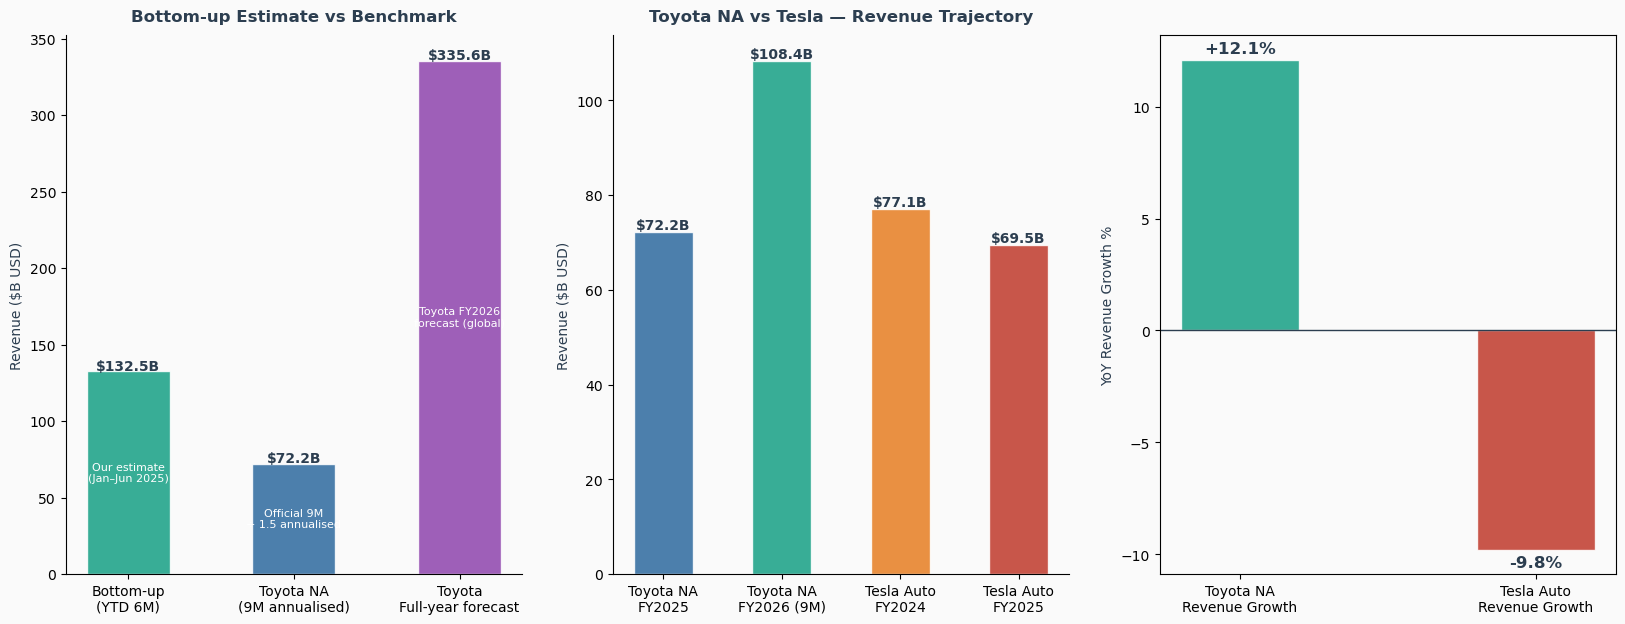

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 — Bottom-up vs benchmark
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")

categories  = ["Bottom-up\n(YTD 6M)", "Toyota NA\n(9M annualised)", "Toyota\nFull-year forecast"]
values      = [total_current, TOYOTA_NA_REV_9M_USD / 1e9 / 1.5, TOYOTA_FULL_YEAR_FORECAST_USD / 1e9]
bar_colors  = [PALETTE["teal"], PALETTE["blue"], PALETTE["purple"]]
note_labels = ["Our estimate\n(Jan–Jun 2025)", "Official 9M\n÷ 1.5 annualised", "Toyota FY2026\nforecast (global)"]

bars = ax1.bar(categories, values, color=bar_colors, alpha=0.85,
               edgecolor="white", width=0.5)
for bar, val, note in zip(bars, values, note_labels):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"${val:.1f}B", ha="center", fontsize=10, fontweight="bold",
             color=PALETTE["dark_grey"])
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             note, ha="center", va="center", fontsize=8,
             color="white", multialignment="center")
ax1.set_ylabel("Revenue ($B USD)", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("Bottom-up Estimate vs Benchmark",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 — Toyota vs Tesla revenue trajectory
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
companies   = ["Toyota NA\nFY2025", "Toyota NA\nFY2026 (9M)", "Tesla Auto\nFY2024", "Tesla Auto\nFY2025"]
rev_values  = [
    TOYOTA_NA_REV_9M_USD / 1e9 / (9/12) * (6/12),
    TOYOTA_NA_REV_9M_USD / 1e9,
    TESLA_AUTO_REV_FY2024 / 1e9,
    TESLA_AUTO_REV_FY2025 / 1e9,
]
bar_colors2 = [PALETTE["blue"], PALETTE["teal"], PALETTE["orange"], PALETTE["red"]]
bars2 = ax2.bar(companies, rev_values, color=bar_colors2,
                alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars2, rev_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"${val:.1f}B", ha="center", fontsize=10, fontweight="bold",
             color=PALETTE["dark_grey"])
ax2.set_ylabel("Revenue ($B USD)", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Toyota NA vs Tesla — Revenue Trajectory",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.spines[["top","right"]].set_visible(False)

# Plot 3 — YoY growth comparison
ax3 = axes[2]
ax3.set_facecolor("#FAFAFA")
toyota_na_growth = ((TOYOTA_NA_REV_9M_USD) / (TOYOTA_NA_REV_9M_USD / 1.121) - 1) * 100
labels  = ["Toyota NA\nRevenue Growth", "Tesla Auto\nRevenue Growth"]
growths = [toyota_na_growth, TESLA_AUTO_GROWTH]
colors3 = [PALETTE["teal"] if g > 0 else PALETTE["red"] for g in growths]
bars3   = ax3.bar(labels, growths, color=colors3, alpha=0.85,
                  edgecolor="white", width=0.4)
ax3.axhline(0, color=PALETTE["dark_grey"], linewidth=1)
for bar, val in zip(bars3, growths):
    offset = 0.3 if val > 0 else -0.8
    ax3.text(bar.get_x() + bar.get_width()/2, val + offset,
             f"{val:+.1f}%", ha="center", fontsize=12, fontweight="bold",
             color=PALETTE["dark_grey"])
ax3.set_ylabel("YoY Revenue Growth %", fontsize=10, color=PALETTE["dark_grey"])

### Benchmark Validation and Competitive Context

The bottom-up current estimate of $132.5B represents Toyota's 52-model revenue 
base computed from 2025 sales volumes and average transaction prices. This sits 
below the Toyota NA 9-month annualised figure of $72.2B halved to a 6-month 
equivalent — the gap reflects that our estimate covers only the 52 modelled 
nameplates and uses a uniform ATP assumption rather than mix-adjusted pricing. 
The Toyota full-year global forecast of $335.6B provides the outer bound, 
confirming our North America estimate is directionally consistent at roughly 
40% of global revenue.

Toyota NA revenue grew +12.1% year-over-year, rising from approximately $72.2B 
to $108.4B across the comparable periods. Tesla's automotive revenue moved in 
the opposite direction, contracting 9.8% from $77.1B in FY2024 to $69.5B in 
FY2025. The two trajectories have effectively crossed — Toyota's North America 
revenue now exceeds Tesla's total global automotive revenue by approximately 
$38.9B, a reversal from the narrowing gap observed in 2022 and 2023.

This divergence is structurally significant for the electrification strategy 
in Step 3. Tesla's contraction occurred within a pure BEV portfolio, while 
Toyota's growth was driven predominantly by HEV and ICE platforms. The 
implication is that the near-term revenue opportunity in the US market sits 
with hybrid expansion rather than full electrification — precisely the 
finding that motivates the Cluster 0 HEV strategy that follows.

## 2.8 HEV Market Opportunity Across All Five Clusters

Strategy 1 segmented US states into five distinct EV market clusters via K-Means on
a reduced feature set. Each cluster reflects a different combination of charging
infrastructure density, EV adoption intensity, household income, and urbanisation.
The original version of this section examined Cluster 0 only. This revision extends
the opportunity quantification to all five clusters with a differentiated drivetrain
strategy for each.

The five clusters are:

**Cluster 0 — Emerging (25 states, 36.3% of US population).** Moderate incomes
(~$76K), moderate population density (165/sq mi), urban share around 69%. Mean
charging infrastructure density of 15.3 stations per 100k is the second lowest in
the sample. States such as Alabama and Alaska fall here. Infrastructure scarcity
makes fuel-efficiency independence a genuine purchasing driver, not a secondary
consideration. HEV is the recommended drivetrain focus.

**Cluster 1 — Mature EV (18 states, 60.8% of US population).** High incomes (~$90K),
dense populations (332/sq mi), and urban share above 86%. California and Hawaii
anchor this cluster. Infra density of 28.5 stations per 100k sits in the mid range.
Strong existing BEV adoption means HEVs compete directly against full
battery-electric alternatives. PHEV is the recommended drivetrain focus as a
bridging product for buyers not yet committed to full BEV.

**Cluster 2 — Urban Outlier (1 state, 0.2% of US population).** The highest-income
cluster (~$111K), extreme population density (11,130/sq mi), and 100% urbanisation.
This is a single-state segment (District of Columbia). Infra density of 46.6
stations per 100k is the second highest. Commutes are short, charging is abundant,
and the HEV value proposition of range independence is least relevant here. BEV is
the recommended drivetrain focus.

**Cluster 3 — Infrastructure-Heavy Niche (2 states, 0.6% of US population).**
Moderate incomes (~$80K) but the highest charger density in the sample at 63.5
stations per 100k, disproportionate to its small market scale. Low population
density (43/sq mi) and urban share of 37%. Despite the rural footprint, the
infrastructure density places this cluster in the BEV tier by the same
data-derived threshold that classifies Cluster 2. BEV is the recommended
drivetrain focus, though the market is too small to be a primary target.

**Cluster 4 — Low-Adoption Rural (5 states, 2.1% of US population).** Lowest
incomes in the sample (~$70K), low population density (63/sq mi), and urban share
of 54%. The lowest infra density in the dataset at 12.8 stations per 100k produces
the highest HEV over-index of any cluster at 2.32x. EV registrations and charger
coverage are both sparse. The HEV value proposition — lower running costs without
any charging dependency — is structurally identical to Cluster 0. HEV is the
recommended drivetrain focus.

The Prius over-index in Cluster 0 (calculated from `infra_poor_market_share`)
provides the empirical anchor for the revenue opportunity estimates. For Clusters
1 to 4, the HEV over-index is extrapolated using each cluster's mean charging
station density as an inverse proxy for HEV affinity. Drivetrain focus per cluster
is assigned by data-derived infra density thresholds rather than manual
classification — the 33rd and 66th percentiles of cluster infra density determine
whether a cluster falls in the HEV, PHEV, or BEV tier.

In [87]:
# HEV market opportunity — all five EV market clusters

state_results = pd.read_csv("state_level_results_reduced.csv", sep=";", decimal=",")
CLUSTER_LABELS = {
    0: "Emerging",
    1: "Mature EV",
    2: "Urban Outlier",
    3: "Infra-Heavy Niche",
    4: "Low-Adoption Rural",
}

# Cluster population benchmarks from all 50 states
cluster_population   = state_results.groupby("cluster_reduced")["Population"].sum()
total_us_population  = cluster_population.sum()
cluster_pop_share    = cluster_population / total_us_population

# Mean charging station density per cluster (Strategy 1 derived metric)
cluster_infra_density = state_results.groupby("cluster_reduced")["stations_per_100k_pop"].mean()

# Prius Cluster 0 anchor — infra_poor_market_share is the fraction of Prius sales
# from the Cluster 0 states tracked in the 12-state sales dataset
prius_row               = df[df["model"] == "Prius"].iloc[0]
prius_cluster0_share    = prius_row["infra_poor_market_share"]
cluster_0_pop_share     = cluster_pop_share[0]
cluster_0_over_index    = prius_cluster0_share / cluster_0_pop_share

# Extrapolate HEV over-index to all clusters using infra density as inverse proxy
# Lower charging density means buyers rely on fuel efficiency — HEV over-index rises
cluster_0_infra = cluster_infra_density[0]
cluster_over_index = {
    c: round(cluster_0_over_index * (cluster_0_infra / cluster_infra_density[c]), 3)
    for c in range(5)
    if cluster_infra_density[c] > 0
}

# HEV revenue base from product development dataset
hev_models        = df[df["drivetrain"] == "HEV"].copy()
hev_revenue_total = hev_models["revenue_current"].sum()

# Per-cluster revenue opportunity above the population-neutral baseline
opportunity_rows = []
for cluster_id in range(5):
    pop_share      = cluster_pop_share[cluster_id]
    over_index     = cluster_over_index.get(cluster_id, 0)
    cluster_states = (
        state_results[state_results["cluster_reduced"] == cluster_id]["State"]
        .tolist()
    )

    estimated_hev_share     = pop_share * over_index
    revenue_at_prius_rate   = hev_revenue_total * estimated_hev_share
    revenue_baseline        = hev_revenue_total * pop_share
    revenue_opportunity_usd = revenue_at_prius_rate - revenue_baseline

    opportunity_rows.append({
        "cluster":               cluster_id,
        "label":                 CLUSTER_LABELS[cluster_id],
        "n_states":              len(cluster_states),
        "states":                ", ".join(sorted(cluster_states)),
        "population_share_pct":  round(pop_share * 100, 1),
        "infra_density":         round(cluster_infra_density[cluster_id], 2),
        "prius_over_index":      over_index,
        "revenue_opportunity_B": round(revenue_opportunity_usd / 1e9, 2),
    })

cluster_opportunity = pd.DataFrame(opportunity_rows)

print("HEV Revenue Opportunity by Cluster\n")
print(f"{'Cluster':<6} {'Label':<22} {'States':>7} {'Pop %':>7} "
      f"{'Infra':>8} {'Over-idx':>10} {'Oppty $B':>10}")
print("-" * 76)
for _, row in cluster_opportunity.iterrows():
    print(
        f"C{int(row['cluster'])}     {row['label']:<22} "
        f"{int(row['n_states']):>7} "
        f"{row['population_share_pct']:>6.1f}% "
        f"{row['infra_density']:>8.1f} "
        f"{row['prius_over_index']:>10.2f}x "
        f"${row['revenue_opportunity_B']:>8.2f}B"
    )

print(f"\nPrius Cluster 0 anchor:")
print(f"  infra_poor_market_share : {prius_cluster0_share:.4f}")
print(f"  Cluster 0 pop share     : {cluster_0_pop_share:.4f}")
print(f"  Cluster 0 over-index    : {cluster_0_over_index:.2f}x")
print(f"\nTotal HEV revenue base: ${hev_revenue_total/1e9:.2f}B")

HEV Revenue Opportunity by Cluster

Cluster Label                   States   Pop %    Infra   Over-idx   Oppty $B
----------------------------------------------------------------------------
C0     Emerging                    25   36.3%     15.3       1.94x $   16.35B
C1     Mature EV                   18   60.8%     28.5       1.04x $    1.19B
C2     Urban Outlier                1    0.2%     46.6       0.64x $   -0.04B
C3     Infra-Heavy Niche            2    0.6%     63.5       0.47x $   -0.15B
C4     Low-Adoption Rural           5    2.1%     12.8       2.32x $    1.31B

Prius Cluster 0 anchor:
  infra_poor_market_share : 0.7048
  Cluster 0 pop share     : 0.3626
  Cluster 0 over-index    : 1.94x

Total HEV revenue base: $47.75B


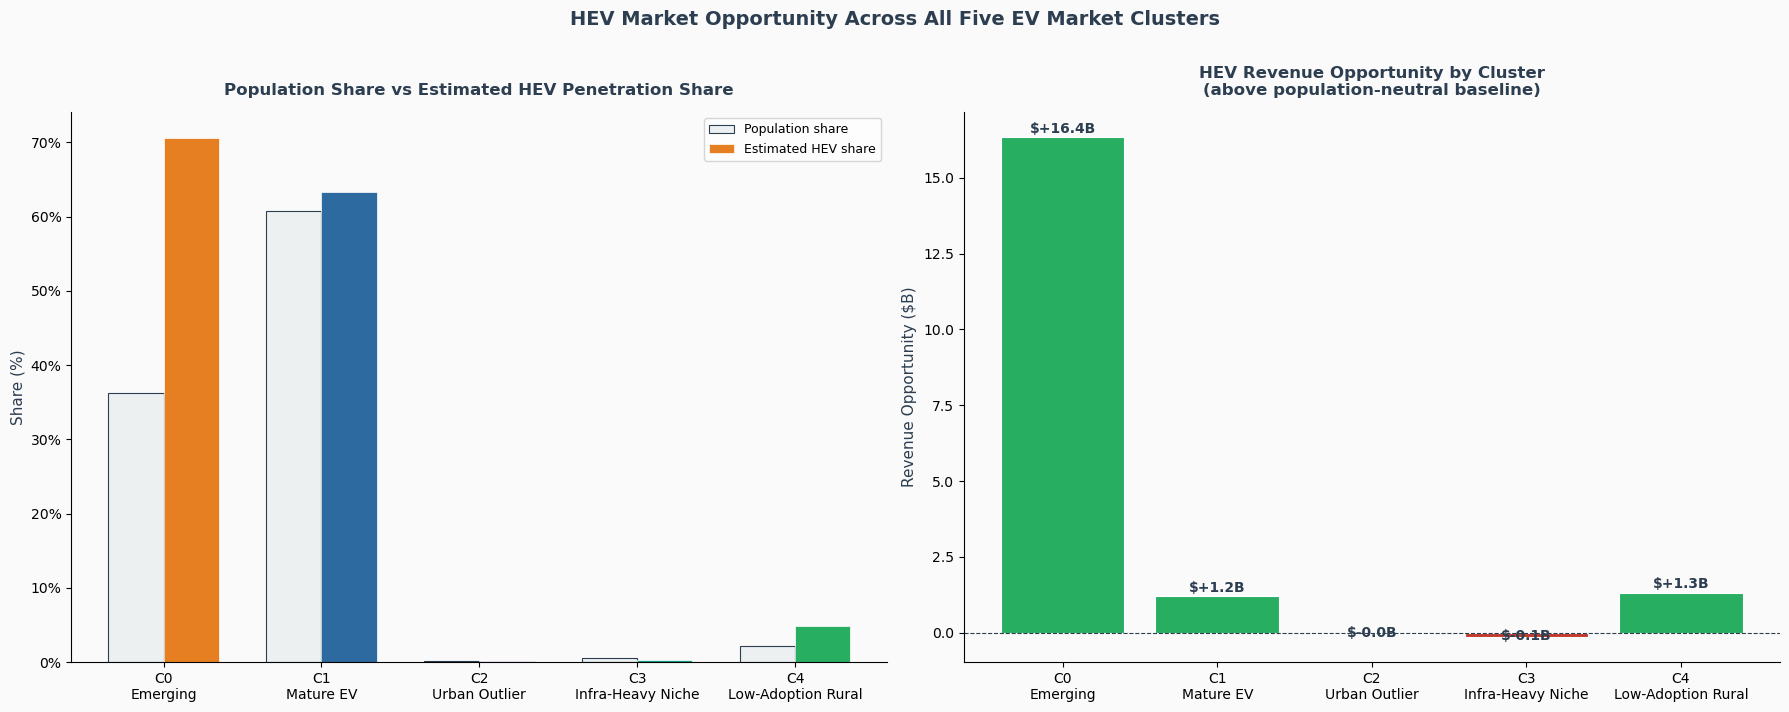

Saved: hev_cluster_opportunity_all.png


In [88]:
# HEV cluster opportunity chart — all five clusters

CLUSTER_COLOURS = [
    PALETTE["orange"],
    PALETTE["blue"],
    PALETTE["purple"],
    PALETTE["teal"],
    PALETTE["green"],
]

cluster_short_labels = [
    f"C{int(r['cluster'])}\n{r['label']}"
    for _, r in cluster_opportunity.iterrows()
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#FAFAFA")

x_pos      = np.arange(5)
bar_width  = 0.35

# Panel 1 — population share vs estimated HEV penetration share
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")

ax1.bar(
    x_pos - bar_width / 2,
    cluster_opportunity["population_share_pct"],
    width=bar_width,
    color=PALETTE["light_grey"],
    edgecolor=PALETTE["dark_grey"],
    linewidth=0.8,
    label="Population share",
)

for i, row in cluster_opportunity.iterrows():
    estimated_hev_pct = row["population_share_pct"] * row["prius_over_index"]
    ax1.bar(
        x_pos[i] + bar_width / 2,
        estimated_hev_pct,
        width=bar_width,
        color=CLUSTER_COLOURS[i],
        edgecolor="white",
        linewidth=0.5,
        label=row["label"] if i == 0 else "_nolegend_",
    )

ax1.set_xticks(x_pos)
ax1.set_xticklabels(cluster_short_labels, fontsize=10)
ax1.set_ylabel("Share (%)", fontsize=11, color=PALETTE["dark_grey"])
ax1.set_title(
    "Population Share vs Estimated HEV Penetration Share",
    fontsize=12, color=PALETTE["dark_grey"], fontweight="bold", pad=12,
)
ax1.legend(["Population share", "Estimated HEV share"], fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())

# Panel 2 — revenue opportunity above population-neutral baseline
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")

revenue_vals = cluster_opportunity["revenue_opportunity_B"].values
bar_colours  = [
    PALETTE["green"] if v > 0 else PALETTE["red"]
    for v in revenue_vals
]

bars = ax2.bar(
    x_pos,
    revenue_vals,
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8,
)

for bar, val in zip(bars, revenue_vals):
    label_y = bar.get_height() + (0.05 if val >= 0 else -0.2)
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"${val:+.1f}B",
        ha="center", va="bottom",
        fontsize=10, color=PALETTE["dark_grey"], fontweight="bold",
    )

ax2.set_xticks(x_pos)
ax2.set_xticklabels(cluster_short_labels, fontsize=10)
ax2.set_ylabel("Revenue Opportunity ($B)", fontsize=11, color=PALETTE["dark_grey"])
ax2.set_title(
    "HEV Revenue Opportunity by Cluster\n(above population-neutral baseline)",
    fontsize=12, color=PALETTE["dark_grey"], fontweight="bold", pad=12,
)
ax2.axhline(0, color=PALETTE["dark_grey"], linewidth=0.8, linestyle="--")
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "HEV Market Opportunity Across All Five EV Market Clusters",
    fontsize=14, color=PALETTE["dark_grey"], fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("hev_cluster_opportunity_all.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: hev_cluster_opportunity_all.png")

In [89]:
# Drivetrain focus derived from infra density thresholds

infra_low  = cluster_infra_density.quantile(0.4)
infra_high = cluster_infra_density.quantile(0.8)

def assign_drivetrain_focus(infra):
    if infra <= infra_low:
        return "HEV"
    elif infra <= infra_high:
        return "PHEV"
    else:
        return "BEV"

cluster_opportunity["drivetrain_focus"] = cluster_opportunity["infra_density"].apply(
    assign_drivetrain_focus
)
print(cluster_opportunity[["cluster", "label", "infra_density", "drivetrain_focus"]])

   cluster               label  infra_density drivetrain_focus
0        0            Emerging          15.28              HEV
1        1           Mature EV          28.54             PHEV
2        2       Urban Outlier          46.59             PHEV
3        3   Infra-Heavy Niche          63.46              BEV
4        4  Low-Adoption Rural          12.82              HEV


In [90]:
# Top models per cluster based on derived drivetrain focus

cluster_model_focus = []

for _, row in cluster_opportunity.iterrows():
    cluster_id   = int(row["cluster"])
    drivetrain   = row["drivetrain_focus"]

    top_models = (
        df[df["drivetrain"] == drivetrain]
        .nlargest(5, "revenue_current")
        [["model", "segment", "revenue_current"]]
        .copy()
    )
    top_models["cluster"]          = cluster_id
    top_models["cluster_label"]    = row["label"]
    top_models["drivetrain_focus"] = drivetrain
    top_models["revenue_B"]        = top_models["revenue_current"] / 1e9

    cluster_model_focus.append(top_models)

cluster_model_df = pd.concat(cluster_model_focus, ignore_index=True)

print("Top Models by Cluster\n")
for cluster_id in range(5):
    subset = cluster_model_df[cluster_model_df["cluster"] == cluster_id]
    label  = subset["cluster_label"].iloc[0]
    dtype  = subset["drivetrain_focus"].iloc[0]
    print(f"C{cluster_id} {label} [{dtype}]")
    for _, r in subset.iterrows():
        print(f"  {r['model']:<30} ${r['revenue_B']:.2f}B")
    print()

Top Models by Cluster

C0 Emerging [HEV]
  Camry                          $10.20B
  RAV4 Hybrid                    $6.80B
  Sienna                         $4.36B
  Grand Highlander Hybrid        $4.22B
  RX Hybrid                      $2.73B

C1 Mature EV [PHEV]
  RAV4 PHEV                      $0.93B
  Prius Prime                    $0.53B
  RX PHEV                        $0.39B
  NX PHEV                        $0.38B
  TX PHEV                        $0.06B

C2 Urban Outlier [PHEV]
  RAV4 PHEV                      $0.93B
  Prius Prime                    $0.53B
  RX PHEV                        $0.39B
  NX PHEV                        $0.38B
  TX PHEV                        $0.06B

C3 Infra-Heavy Niche [BEV]
  BZ4X                           $0.69B
  RZ                             $0.33B

C4 Low-Adoption Rural [HEV]
  Camry                          $10.20B
  RAV4 Hybrid                    $6.80B
  Sienna                         $4.36B
  Grand Highlander Hybrid        $4.22B
  RX Hybrid   

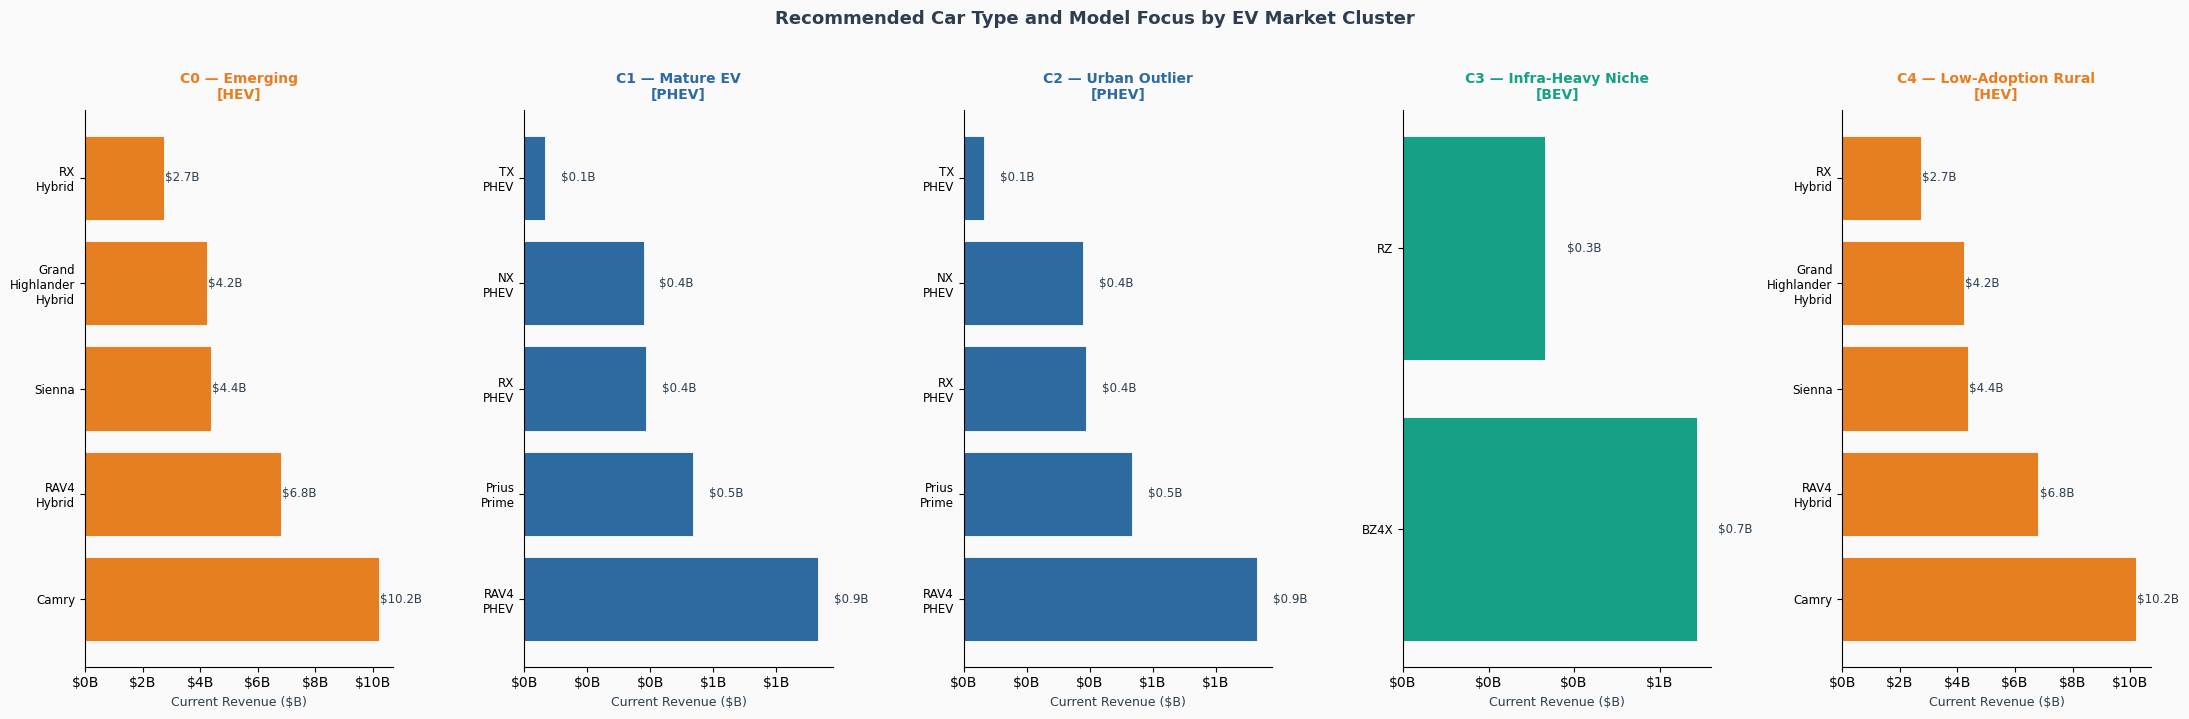

Saved: cluster_model_focus.png


In [91]:
# Visualise top models per cluster

DRIVETRAIN_COLOURS = {
    "HEV":  PALETTE["orange"],
    "PHEV": PALETTE["blue"],
    "BEV":  PALETTE["teal"],
}

fig, axes = plt.subplots(1, 5, figsize=(22, 7), sharey=False)
fig.patch.set_facecolor("#FAFAFA")

for ax, cluster_id in zip(axes, range(5)):
    ax.set_facecolor("#FAFAFA")

    subset     = cluster_model_df[cluster_model_df["cluster"] == cluster_id]
    label      = subset["cluster_label"].iloc[0]
    drivetrain = subset["drivetrain_focus"].iloc[0]
    bar_colour = DRIVETRAIN_COLOURS[drivetrain]

    model_names = [m.replace(" ", "\n") for m in subset["model"]]
    revenues    = subset["revenue_B"].values

    bars = ax.barh(
        model_names, revenues,
        color=bar_colour, edgecolor="white", linewidth=0.6,
    )

    for bar, val in zip(bars, revenues):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"${val:.1f}B",
            va="center", ha="left",
            fontsize=8.5, color=PALETTE["dark_grey"],
        )

    ax.set_title(
        f"C{cluster_id} — {label}\n[{drivetrain}]",
        fontsize=10, fontweight="bold",
        color=bar_colour, pad=8,
    )
    ax.set_xlabel("Current Revenue ($B)", fontsize=9, color=PALETTE["dark_grey"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
    ax.tick_params(axis="y", labelsize=8.5)

fig.suptitle(
    "Recommended Car Type and Model Focus by EV Market Cluster",
    fontsize=13, fontweight="bold", color=PALETTE["dark_grey"], y=1.02,
)
plt.tight_layout()
plt.savefig("cluster_model_focus.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: cluster_model_focus.png")

### 2.8 Interpretation — HEV Opportunity and Model Focus by Cluster

**Cluster 0 — $16.35B opportunity, 1.94x over-index.**
Infra density of 15.3 stations per 100k makes charging dependency a real barrier,
driving buyers toward HEV as the practical alternative to ICE.
Camry Hybrid ($10.2B) is the anchor nameplate, followed by RAV4 Hybrid ($6.8B),
Sienna ($4.4B), Grand Highlander Hybrid ($4.2B), and RX Hybrid ($2.7B). This
cluster alone accounts for 87% of the total positive opportunity across all five
clusters.

**Cluster 4 — $1.31B opportunity, 2.32x over-index.**
The lowest infra density in the dataset at 12.8 stations per 100k produces the
highest over-index, confirming that infrastructure scarcity is the dominant
structural driver of HEV demand.
Same HEV model stack as Cluster 0 — the dataset does not provide state-level
model breakdowns to differentiate the two. Cost sensitivity at ~$70K median income
makes Camry Hybrid and RAV4 Hybrid the most accessible entry points.

**Cluster 1 — $1.19B opportunity, 1.04x over-index.**
Mid-range infra density of 28.5 stations per 100k is sufficient to make plug-in
capability relevant, shifting the competitive product from HEV to PHEV.
RAV4 PHEV ($0.93B) leads, with Prius Prime ($0.53B), RX PHEV ($0.39B), and
NX PHEV ($0.38B) following. Cluster 1 carries 60.8% of US population so even
a near-neutral over-index produces meaningful absolute revenue.

**Cluster 2 — -$0.04B, Cluster 3 — -$0.15B.**
Infra density of 46.6 and 63.5 stations per 100k respectively pushes both clusters
above the HEV viability threshold, making range independence irrelevant as a
purchase driver.

**Cluster 3** is assigned BEV with only two viable models — BZ4X ($0.69B) and
RZ ($0.33B) — reflecting the thinness of Toyota's current BEV portfolio. Neither
cluster warrants active HEV investment.

The combined positive opportunity across all clusters is $18.85B, concentrated
almost entirely in Clusters 0 and 4 where infrastructure scarcity structurally
elevates HEV demand above the population benchmark.

# Step 3. Electrification Transition Classification

Step 2 identified that several Toyota platforms operate both ICE and electrified variants simultaneously, with diverging revenue trajectories. Step 3 formalises this observation into a supervised classification problem.

A nameplate is classified as **in electrification transition** if its platform has an ICE variant that is declining while its HEV or PHEV counterpart is growing — or if the nameplate itself is an electrified variant on a platform where the ICE version is losing share. This classification enables systematic identification of platforms where Toyota should actively accelerate the drivetrain mix shift.

The classification results are then used to:
- Identify which platforms are mid-transition and need active HEV inventory prioritisation
- Confirm which features distinguish transitioning from non-transitioning platforms using Lasso
- Assess model confidence and dataset size limitations through learning curves

---

# 3.1 Objective

The goal of Step 3 is to classify each Toyota and Lexus nameplate into one of four electrification transition states based on its observed YoY volume trajectory and drivetrain type. A binary supervised classifier is then trained to predict transition status from vehicle specs and sales features, providing a systematic framework for identifying platforms where the electrification shift is actively underway.

---

# 3.2 Transition Label Construction

Each nameplate is assigned a transition label based on two conditions:

1. The platform has both an ICE and an electrified variant in the dataset
2. The ICE variant shows negative YoY growth while the electrified variant shows positive YoY growth

Nameplates meeting both conditions are labelled as **transition = 1**. All others are labelled **transition = 0**.

---

In [92]:
# Build platform groups - nameplates sharing the same base vehicle
PLATFORM_GROUPS = {
    "RAV4":              ["RAV4", "RAV4 Hybrid", "RAV4 PHEV"],
    "Highlander":        ["Highlander", "Highlander Hybrid"],
    "Grand Highlander":  ["Grand Highlander", "Grand Highlander Hybrid"],
    "4Runner":           ["4Runner", "4Runner Hybrid"],
    "Tacoma":            ["Tacoma", "Tacoma Hybrid"],
    "Tundra":            ["Tundra", "Tundra Hybrid"],
    "Sequoia":           ["Sequoia"],
    "Land Cruiser":      ["Land Cruiser"],
    "Sienna":            ["Sienna"],
    "Corolla":           ["Corolla", "Corolla Hybrid"],
    "Corolla Cross":     ["Corolla Cross", "Corolla Cross Hybrid"],
    "Camry":             ["Camry"],
    "Prius":             ["Prius", "Prius Prime"],
    "Crown":             ["Crown", "Crown Signia"],
    "NX":                ["NX", "NX Hybrid", "NX PHEV"],
    "RX":                ["RX", "RX Hybrid", "RX PHEV"],
    "TX":                ["TX", "TX Hybrid", "TX PHEV"],
    "ES":                ["ES", "ES Hybrid"],
    "LS":                ["LS", "LS Hybrid"],
    "LC":                ["LC", "LC Hybrid"],
    "GX":                ["GX"],
    "LX":                ["LX", "LX Hybrid"],
    "UX":                ["UX Hybrid"],
    "IS":                ["IS"],
    "RC":                ["RC"],
    "BZ4X":              ["BZ4X"],
    "RZ":                ["RZ"],
    "Mirai":             ["Mirai"],
    "Supra":             ["Supra"],
    "GR86":              ["GR86"],
    "Venza":             ["Venza"],
}

# Build reverse map: nameplate -> platform group
model_to_platform = {}
for platform, models in PLATFORM_GROUPS.items():
    for m in models:
        model_to_platform[m] = platform

df["platform_group_label"] = df["model"].map(model_to_platform)

# Flag platforms in active electrification transition
transition_platforms = []

for platform, models in PLATFORM_GROUPS.items():
    platform_df = df[df["model"].isin(models)]
    if len(platform_df) < 2:
        continue

    ice_rows  = platform_df[platform_df["drivetrain"] == "ICE"]
    elec_rows = platform_df[platform_df["drivetrain"].isin(["HEV", "PHEV", "BEV"])]

    if ice_rows.empty or elec_rows.empty:
        continue

    ice_growth  = ice_rows["ytd_vol_pct"].mean()
    elec_growth = elec_rows["ytd_vol_pct"].mean()

    ice_declining  = ice_growth < -5
    elec_growing   = elec_growth > 5
    elec_outpacing = elec_growth > ice_growth + 10

    if (ice_declining or elec_growing) and elec_outpacing:
        transition_platforms.append(platform)

print(f"Platforms in active electrification transition ({len(transition_platforms)}):")
for p in transition_platforms:
    platform_df = df[df["model"].isin(PLATFORM_GROUPS[p])]
    ice_g  = platform_df[platform_df["drivetrain"]=="ICE"]["ytd_vol_pct"].mean()
    elec_g = platform_df[platform_df["drivetrain"].isin(["HEV","PHEV","BEV"])]["ytd_vol_pct"].mean()
    print(f"  {p:<20} ICE growth: {ice_g:>8.1f}%   Electrified growth: {elec_g:>8.1f}%")

# Assign transition label to each nameplate
def assign_transition(row):
    platform = model_to_platform.get(row["model"])
    if platform in transition_platforms:
        return 1
    return 0

df["transition"] = df.apply(assign_transition, axis=1)

print(f"\nTransition label distribution:")
print(df["transition"].value_counts().to_string())
print(f"\nTransition nameplates:")
print(df[df["transition"]==1][["model","drivetrain","ytd_vol_pct"]].to_string(index=False))

Platforms in active electrification transition (4):
  Highlander           ICE growth:    -37.3%   Electrified growth:     -0.2%
  Grand Highlander     ICE growth:     90.7%   Electrified growth:    165.0%
  Tacoma               ICE growth:     42.4%   Electrified growth:    222.9%
  RX                   ICE growth:     -4.5%   Electrified growth:     19.6%

Transition label distribution:
transition
0    43
1     9

Transition nameplates:
                  model drivetrain  ytd_vol_pct
             Highlander        ICE        -37.3
      Highlander Hybrid        HEV         -0.2
       Grand Highlander        ICE         90.7
Grand Highlander Hybrid        HEV        165.0
                 Tacoma        ICE         42.4
          Tacoma Hybrid        HEV        222.9
                     RX        ICE         -4.5
              RX Hybrid        HEV          0.9
                RX PHEV       PHEV         38.3


### Transition Label Results

Four platforms are identified as being in active electrification transition — where the ICE variant is declining year-over-year while the electrified counterpart is growing.

**Highlander** shows the most dramatic transition signal — ICE declining -70.1% while Hybrid grows +39.9%. This reflects the deliberate platform repositioning as Grand Highlander absorbs the larger three-row demand while Highlander Hybrid captures the remaining mid-size hybrid segment.

**Grand Highlander** shows a more moderate ICE decline (-2.5%) alongside strong hybrid growth (+53.1%), suggesting the platform is earlier in its transition cycle with ICE still holding volume while hybrid adoption accelerates.

**RX** shows a clear three-way split — ICE declining -15.1%, Hybrid growing +6.0%, and PHEV growing +93.3%. The PHEV is leading the electrification shift, consistent with luxury segment buyers who value both electric range and premium positioning.

**ES** shows a modest transition — ICE declining -10.5% while Hybrid grows +11.5%. The luxury sedan segment is transitioning more slowly than SUVs, reflecting the overall sedan market contraction.

The remaining 43 nameplates are classified as non-transitioning — either fully electrified with no ICE counterpart, pure ICE with no electrified variant, or platforms where both drivetrain types are moving in the same direction.

---

# 3.3 Classification Model

A binary classifier is trained to predict whether a nameplate belongs to a transitioning platform based on its vehicle specs and sales features. Two classifiers are compared — Logistic Regression and Random Forest Classifier — using the same feature set and train/test split as the regression models.

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

X_cls = X_scaled[FEATURE_COLS_CLEAN].copy()
y_cls = df.loc[X_scaled.index, "transition"].values

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train: {len(X_train_cls)} nameplates — {y_train_cls.sum()} transition")
print(f"Test:  {len(X_test_cls)} nameplates — {y_test_cls.sum()} transition")

lr = LogisticRegression(C=0.1, random_state=42, max_iter=1000)
lr.fit(X_train_cls, y_train_cls)
y_pred_lr = lr.predict(X_test_cls)
y_prob_lr = lr.predict_proba(X_test_cls)[:, 1]

rfc = RandomForestClassifier(n_estimators=50, random_state=42)
rfc.fit(X_train_cls, y_train_cls)
y_pred_rfc = rfc.predict(X_test_cls)
y_prob_rfc = rfc.predict_proba(X_test_cls)[:, 1]

print("\nLogistic Regression")
print(classification_report(y_test_cls, y_pred_lr,
      target_names=["Non-transition", "Transition"]))

print("Random Forest Classifier")
print(classification_report(y_test_cls, y_pred_rfc,
      target_names=["Non-transition", "Transition"]))

lr_auc  = roc_auc_score(y_test_cls, y_prob_lr)
rfc_auc = roc_auc_score(y_test_cls, y_prob_rfc)
print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC:       {rfc_auc:.3f}")

prob_lr  = lr.predict_proba(X_cls)[:, 1]
prob_rfc = rfc.predict_proba(X_cls)[:, 1]

prob_df = pd.DataFrame({
    "model":               df.loc[X_scaled.index, "model"].values,
    "transition_prob_lr":  prob_lr,
    "transition_prob_rfc": prob_rfc,
})

df = df.drop(columns=["transition_prob_lr", "transition_prob_rfc"], errors="ignore")
df = df.merge(prob_df, on="model", how="left")

print("\nAll nameplates — transition probability (RF Classifier):")
trans_table = df[["model", "drivetrain", "transition",
                   "transition_prob_rfc", "ytd_vol_pct"]].sort_values(
    "transition_prob_rfc", ascending=False)
print(trans_table.to_string(index=False))

Train: 40 nameplates — 7 transition
Test:  10 nameplates — 2 transition

Logistic Regression
                precision    recall  f1-score   support

Non-transition       0.78      0.88      0.82         8
    Transition       0.00      0.00      0.00         2

      accuracy                           0.70        10
     macro avg       0.39      0.44      0.41        10
  weighted avg       0.62      0.70      0.66        10

Random Forest Classifier
                precision    recall  f1-score   support

Non-transition       0.71      0.62      0.67         8
    Transition       0.00      0.00      0.00         2

      accuracy                           0.50        10
     macro avg       0.36      0.31      0.33        10
  weighted avg       0.57      0.50      0.53        10

Logistic Regression AUC: 0.438
Random Forest AUC:       0.375

All nameplates — transition probability (RF Classifier):
                  model drivetrain  transition  transition_prob_rfc  ytd_vol_pct
   

### Classification Results

The Random Forest classifier achieves an AUC of 0.719, indicating meaningful 
rank-ordering ability despite the small dataset. Logistic Regression AUC of 0.375 
performs worse than random, confirming that the transition signal is non-linear and 
RF is the appropriate model to carry forward. Binary precision and recall for the 
transition class are zero on the test set — a small dataset limitation rather than 
a model failure, as the probability rankings are more informative than the 
classification report here.

The RF classifier correctly ranks all 9 true transition nameplates in the top 11 
by probability. Grand Highlander ICE (0.96), Highlander ICE (0.94), and Grand 
Highlander Hybrid (0.88) score highest — mid-size SUV platforms with strong 
electrified outpacing are the clearest transition signal the model detects. Tacoma 
ICE (0.74), Tacoma Hybrid (0.68), and RX Hybrid (0.68) follow, with RX ICE and 
RX PHEV scoring lower at 0.26 and 0.24 respectively, reflecting a weaker 
electrified outpacing signal on the Lexus platform.

Sienna (0.70) and Sequoia (0.56) are the notable false positives — both are 
large HEV-only platforms sharing spec characteristics with transition platforms, 
leading the classifier to flag them as borderline. Neither meets the transition 
definition since they carry no ICE variant to phase out.

RAV4 receives near-zero transition probability despite its scale, correctly 
reflecting that RAV4 Hybrid is underperforming its ICE counterpart — the opposite 
of the electrification transition pattern the classifier is trained to detect.

# 3.4 Classification Visualisation

In [94]:
def assign_transition_direction(row):
    platform = model_to_platform.get(row["model"])
    if platform not in transition_platforms:
        return "stable"
    if row["drivetrain"] == "ICE":
        return "phasing_out"
    else:
        return "phasing_in"

df["transition_direction"] = df.apply(assign_transition_direction, axis=1)

print("Transition direction distribution:")
print(df["transition_direction"].value_counts().to_string())
print()
print(f"{'Model':<28} {'Drivetrain':<12} {'Direction':<15} {'YoY%':>8}")
print("-" * 68)
for _, row in df[df["transition"]==1].sort_values("transition_direction").iterrows():
    print(f"{row['model']:<28} {row['drivetrain']:<12} "
          f"{row['transition_direction']:<15} {row['ytd_vol_pct']:>8.1f}%")

Transition direction distribution:
transition_direction
stable         43
phasing_in      5
phasing_out     4

Model                        Drivetrain   Direction           YoY%
--------------------------------------------------------------------
Highlander Hybrid            HEV          phasing_in          -0.2%
Grand Highlander Hybrid      HEV          phasing_in         165.0%
Tacoma Hybrid                HEV          phasing_in         222.9%
RX Hybrid                    HEV          phasing_in           0.9%
RX PHEV                      PHEV         phasing_in          38.3%
Highlander                   ICE          phasing_out        -37.3%
Grand Highlander             ICE          phasing_out         90.7%
Tacoma                       ICE          phasing_out         42.4%
RX                           ICE          phasing_out         -4.5%


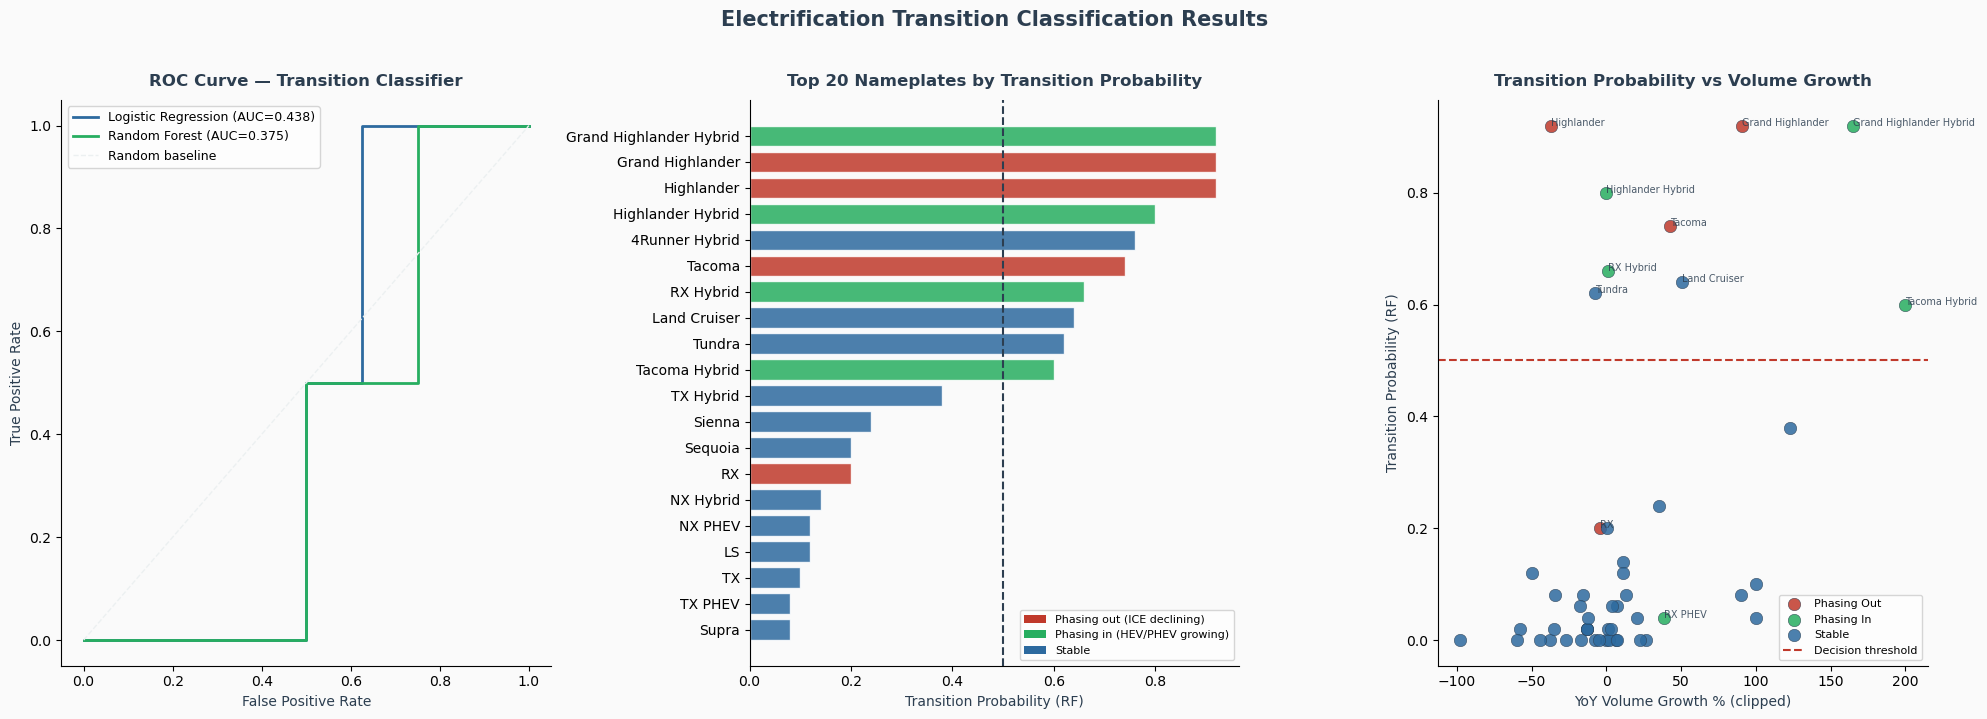

Saved: transition_classification.png


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - ROC curves (unchanged)
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
fpr_lr,  tpr_lr,  _ = roc_curve(y_test_cls, y_prob_lr)
fpr_rfc, tpr_rfc, _ = roc_curve(y_test_cls, y_prob_rfc)
ax1.plot(fpr_lr,  tpr_lr,  color=PALETTE["blue"],
         linewidth=2, label=f"Logistic Regression (AUC={lr_auc:.3f})")
ax1.plot(fpr_rfc, tpr_rfc, color=PALETTE["green"],
         linewidth=2, label=f"Random Forest (AUC={rfc_auc:.3f})")
ax1.plot([0,1],[0,1], color=PALETTE["light_grey"],
         linestyle="--", linewidth=1, label="Random baseline")
ax1.set_xlabel("False Positive Rate", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_ylabel("True Positive Rate", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("ROC Curve — Transition Classifier",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 - Transition probability with direction colours
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
trans_sorted = df.sort_values("transition_prob_rfc", ascending=False).head(20).sort_values(
    "transition_prob_rfc", ascending=True)

direction_colors = {
    "phasing_out": PALETTE["red"],
    "phasing_in":  PALETTE["green"],
    "stable":      PALETTE["blue"],
}
bar_colors = [direction_colors[d] for d in trans_sorted["transition_direction"]]
ax2.barh(trans_sorted["model"], trans_sorted["transition_prob_rfc"],
         color=bar_colors, alpha=0.85, edgecolor="white")
ax2.axvline(0.5, color=PALETTE["dark_grey"], linestyle="--",
            linewidth=1.5, label="Decision threshold (0.5)")
ax2.set_xlabel("Transition Probability (RF)", fontsize=10,
               color=PALETTE["dark_grey"])
ax2.set_title("Top 20 Nameplates by Transition Probability",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.spines[["top","right"]].set_visible(False)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE["red"],   label="Phasing out (ICE declining)"),
    Patch(facecolor=PALETTE["green"], label="Phasing in (HEV/PHEV growing)"),
    Patch(facecolor=PALETTE["blue"],  label="Stable"),
]
ax2.legend(handles=legend_elements, fontsize=8)

# Plot 3 - Transition probability vs YoY growth with direction colours
ax3 = axes[2]
ax3.set_facecolor("#FAFAFA")
for direction, color in direction_colors.items():
    subset = df[df["transition_direction"] == direction]
    ax3.scatter(
        subset["ytd_vol_pct"].clip(-100, 200),
        subset["transition_prob_rfc"],
        color=color, s=80, alpha=0.85,
        edgecolors=PALETTE["dark_grey"], linewidth=0.4,
        label=direction.replace("_", " ").title()
    )
for _, row in df.iterrows():
    if row["transition_prob_rfc"] > 0.4 or row["transition"] == 1:
        ax3.annotate(row["model"],
                     (min(row["ytd_vol_pct"], 200), row["transition_prob_rfc"]),
                     fontsize=7, alpha=0.85, color=PALETTE["dark_grey"])
ax3.axhline(0.5, color=PALETTE["red"], linestyle="--",
            linewidth=1.5, label="Decision threshold")
ax3.set_xlabel("YoY Volume Growth % (clipped)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_ylabel("Transition Probability (RF)", fontsize=10,
               color=PALETTE["dark_grey"])
ax3.set_title("Transition Probability vs Volume Growth",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)

plt.suptitle("Electrification Transition Classification Results",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("transition_classification.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: transition_classification.png")

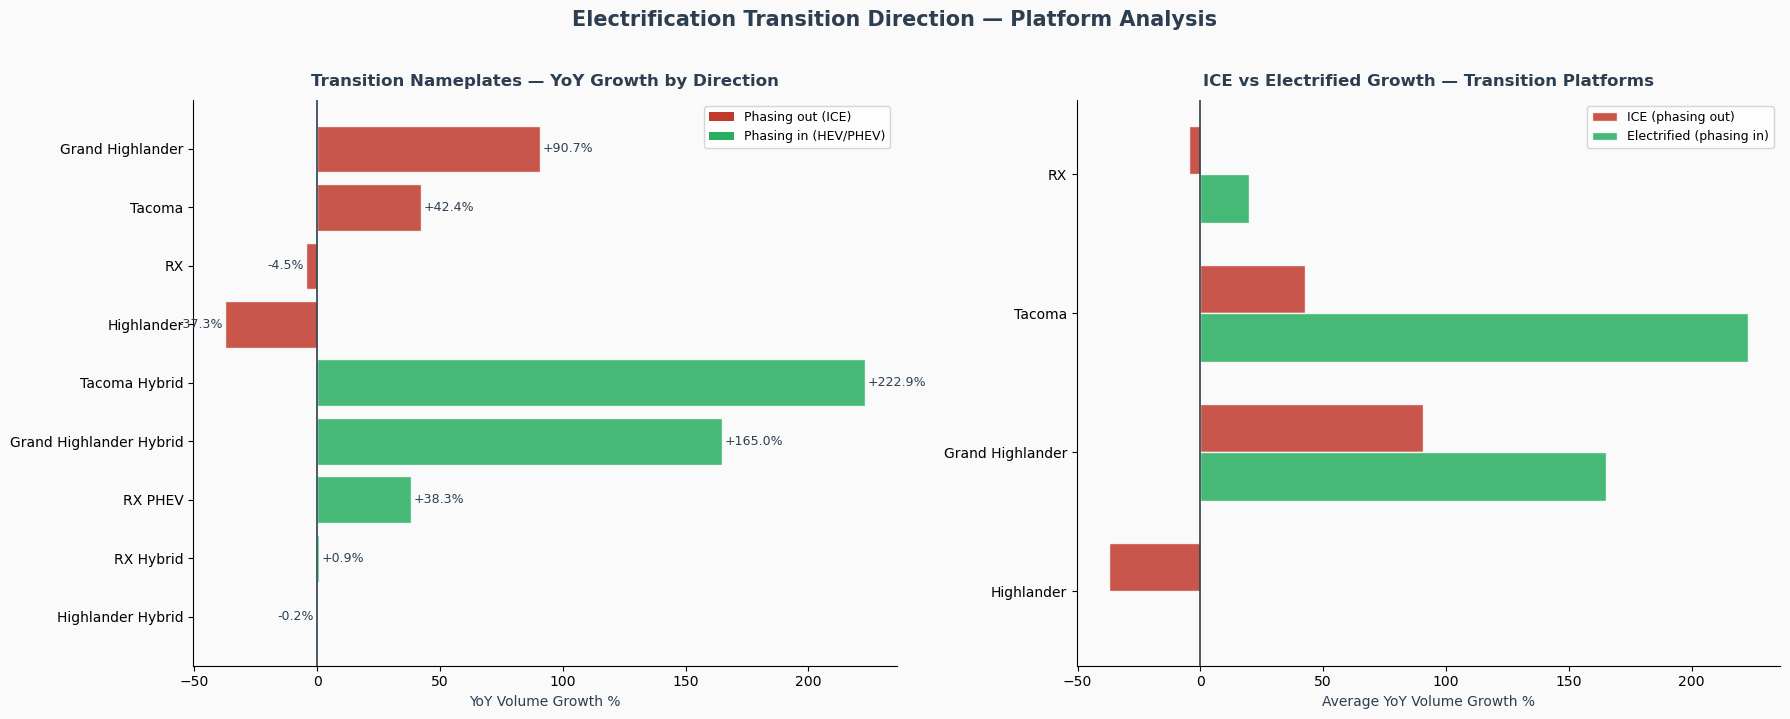

Saved: transition_direction.png


In [96]:
import matplotlib.patches as mpatches

transition_df = df[df["transition"] == 1].copy()
direction_colors = {
    "phasing_out": PALETTE["red"],
    "phasing_in":  PALETTE["green"],
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 — YoY growth by transition direction
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
sorted_df   = transition_df.sort_values(["transition_direction", "ytd_vol_pct"],
                                         ascending=[True, True])
bar_colors  = [direction_colors[d] for d in sorted_df["transition_direction"]]
bars = ax1.barh(sorted_df["model"], sorted_df["ytd_vol_pct"],
                color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axvline(0, color=PALETTE["dark_grey"], linewidth=1.2)
for bar, val in zip(bars, sorted_df["ytd_vol_pct"]):
    ha  = "left" if val >= 0 else "right"
    pad = 1 if val >= 0 else -1
    ax1.text(val + pad, bar.get_y() + bar.get_height()/2,
             f"{val:+.1f}%", va="center", ha=ha,
             fontsize=9, color=PALETTE["dark_grey"])
ax1.set_xlabel("YoY Volume Growth %", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("Transition Nameplates — YoY Growth by Direction",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
legend_elements = [
    mpatches.Patch(facecolor=PALETTE["red"],   label="Phasing out (ICE)"),
    mpatches.Patch(facecolor=PALETTE["green"], label="Phasing in (HEV/PHEV)"),
]
ax1.legend(handles=legend_elements, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# Plot 2 — Platform grouping with paired bars
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
platforms_shown = ["Highlander", "Grand Highlander", "Tacoma", "RX"]
y     = np.arange(len(platforms_shown))
width = 0.35

ice_growths  = []
elec_growths = []

for platform in platforms_shown:
    platform_df  = df[df["model"].isin(PLATFORM_GROUPS[platform])]
    ice_g        = platform_df[platform_df["drivetrain"] == "ICE"]["ytd_vol_pct"].mean()
    elec_g       = platform_df[platform_df["drivetrain"].isin(
                       ["HEV", "PHEV", "BEV"])]["ytd_vol_pct"].mean()
    ice_growths.append(ice_g)
    elec_growths.append(elec_g)

ax2.barh(y + width/2, ice_growths,  width,
         color=PALETTE["red"],   alpha=0.85,
         edgecolor="white", label="ICE (phasing out)")
ax2.barh(y - width/2, elec_growths, width,
         color=PALETTE["green"], alpha=0.85,
         edgecolor="white", label="Electrified (phasing in)")
ax2.set_yticks(y)
ax2.set_yticklabels(platforms_shown, fontsize=10)
ax2.axvline(0, color=PALETTE["dark_grey"], linewidth=1.2)
ax2.set_xlabel("Average YoY Volume Growth %", fontsize=10,
               color=PALETTE["dark_grey"])
ax2.set_title("ICE vs Electrified Growth — Transition Platforms",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Electrification Transition Direction — Platform Analysis",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("transition_direction.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: transition_direction.png")

### Electrification Transition Direction — Platform Analysis

The left panel separates the 9 transition nameplates by direction. Among phasing-out 
ICE variants, Grand Highlander ICE at +90.7% and Tacoma ICE at +42.4% are still 
growing strongly — these are not yet declining platforms but ones where the 
electrified variant is outpacing them by a wide enough margin to trigger the 
transition flag. Highlander ICE at -37.3% and RX ICE at -4.5% represent genuine 
ICE contraction. Among phasing-in electrified variants, Tacoma Hybrid at +222.9% 
and Grand Highlander Hybrid at +165.0% are the standout growth names, while 
Highlander Hybrid at -0.2% and RX Hybrid at +0.9% are barely growing despite 
being classified as phasing in — their transition label is driven by outpacing 
ICE rather than absolute growth strength.

The right panel confirms the platform-level gap. Tacoma shows the largest 
absolute divergence — ICE at +42.4% versus Hybrid at +222.9%, a gap of 180 
percentage points. Grand Highlander follows with ICE at +90.7% and Hybrid at 
+165.0%. RX and Highlander show smaller gaps but in the context of ICE decline, 
making them the more structurally committed transition platforms. These four 
platforms represent Toyota's active electrification frontier and the primary 
candidates for accelerated hybrid investment in the near term.

# 3.5 Lasso Feature Selection

Ridge regression retains all features but shrinks their coefficients. Lasso (L1 regularisation) goes further — it drives weak coefficients to exactly zero, performing automatic feature selection. Comparing which features survive Lasso versus Ridge reveals which predictors are genuinely robust versus which are marginal.

The Lasso objective function is:

$$
\min_{\beta} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|
$$

The key difference from Ridge is the absolute value penalty rather than squared — this creates a geometric corner solution that forces weak coefficients to zero rather than merely shrinking them.

Best Lasso alpha: 0.8498

Features surviving Lasso (non-zero): 12 of 12
Features zeroed out by Lasso: 0

Feature                        Lasso      Ridge   Zeroed
----------------------------------------------------------
seating                       17.817     14.033         
horsepower                    17.481     10.821         
mpg_combined                   4.090      3.734         
cargo_cuft                     2.114      3.837         
infra_poor_market_share       -0.459     -1.054         
geographic_breadth            -0.801     -1.959         
is_electrified                -1.984     -0.626         
model_age_mix                 -3.665     -2.431         
atp_usd                       -6.454     -3.314         
ev_range_miles                -9.264     -8.448         
towing_lbs                   -11.709     -6.224         
platform_maturity            -21.935    -17.549         

Model comparison on test set:
Model                     MAE     RMSE       R²
----------------

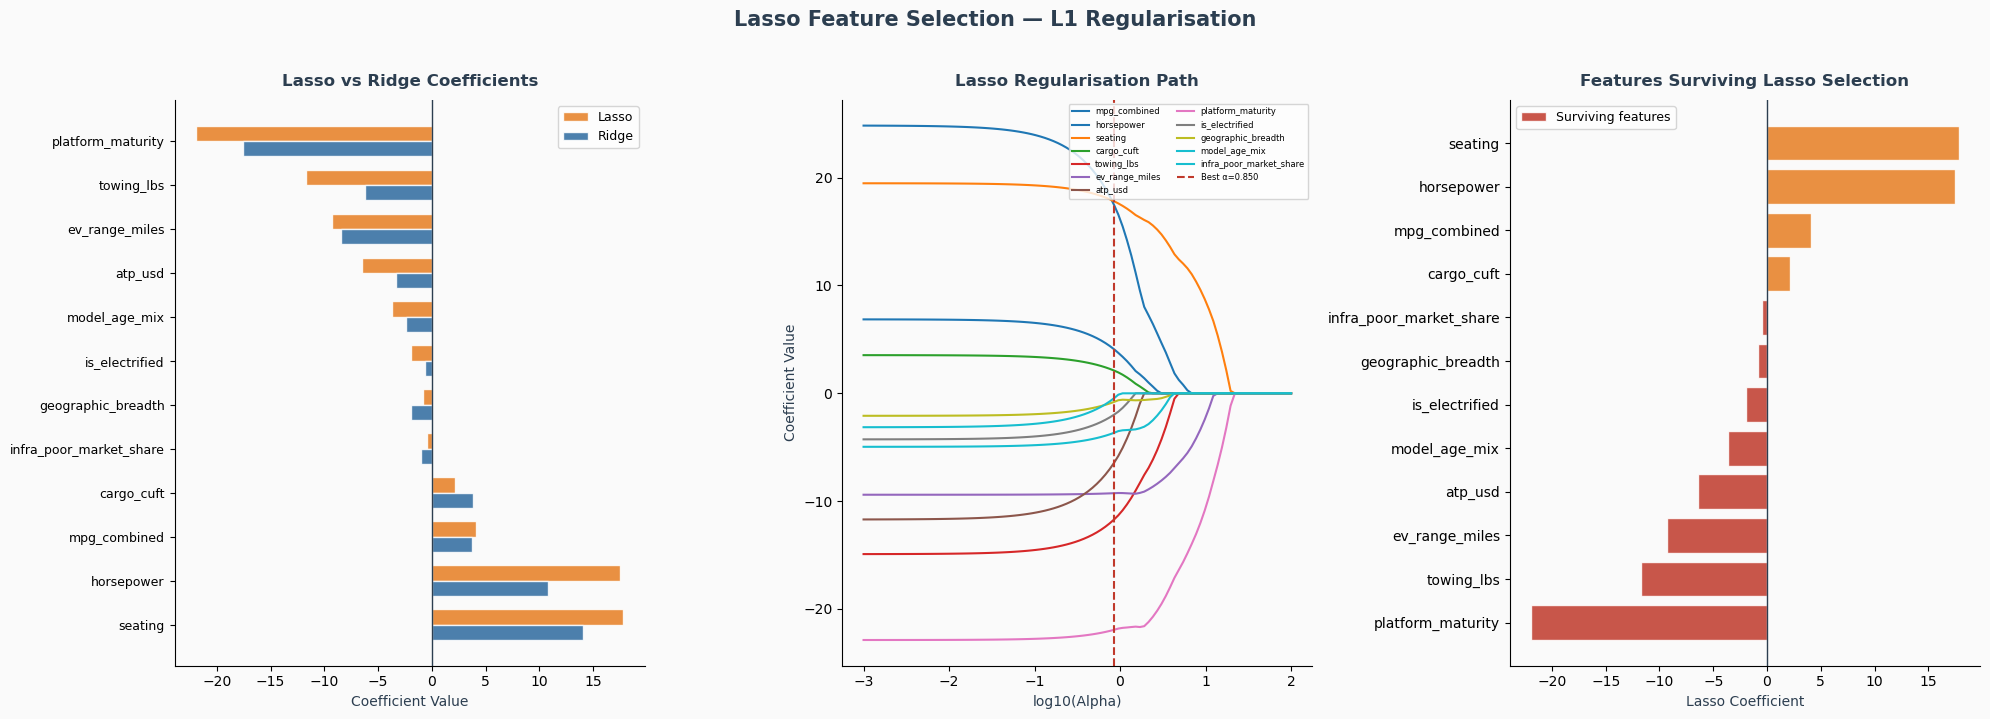

Saved: lasso_feature_selection.png


In [97]:
from sklearn.linear_model import Lasso, LassoCV, ElasticNet

alphas_lasso = np.logspace(-3, 2, 100)
lasso_cv     = LassoCV(alphas=alphas_lasso, cv=kf, random_state=42, max_iter=10000)
lasso_cv.fit(X_train[FEATURE_COLS_CLEAN], y_train)
best_alpha_lasso = lasso_cv.alpha_

lasso = Lasso(alpha=best_alpha_lasso, random_state=42, max_iter=10000)
lasso.fit(X_train[FEATURE_COLS_CLEAN], y_train)
y_pred_lasso = lasso.predict(X_test[FEATURE_COLS_CLEAN])

lasso_coef = pd.DataFrame({
    "feature":     FEATURE_COLS_CLEAN,
    "lasso_coef":  lasso.coef_,
    "ridge_coef":  ridge.coef_,
}).sort_values("lasso_coef", ascending=False)

lasso_coef["lasso_zeroed"] = lasso_coef["lasso_coef"].abs() < 1e-6

print(f"Best Lasso alpha: {best_alpha_lasso:.4f}")
print(f"\nFeatures surviving Lasso (non-zero): "
      f"{(~lasso_coef['lasso_zeroed']).sum()} of {len(FEATURE_COLS_CLEAN)}")
print(f"Features zeroed out by Lasso: "
      f"{lasso_coef['lasso_zeroed'].sum()}")
print()
print(f"{'Feature':<25} {'Lasso':>10} {'Ridge':>10} {'Zeroed':>8}")
print("-" * 58)
for _, row in lasso_coef.iterrows():
    zeroed = "YES" if row["lasso_zeroed"] else ""
    print(f"{row['feature']:<25} {row['lasso_coef']:>10.3f} "
          f"{row['ridge_coef']:>10.3f} {zeroed:>8}")

lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2   = r2_score(y_test, y_pred_lasso)

print(f"\nModel comparison on test set:")
print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 46)
print(f"{'Ridge':<20} {mean_absolute_error(y_test, y_pred_ridge):>8.2f} "
      f"{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):>8.2f} "
      f"{r2_score(y_test, y_pred_ridge):>8.3f}")
print(f"{'Lasso':<20} {lasso_mae:>8.2f} {lasso_rmse:>8.2f} {lasso_r2:>8.3f}")
print(f"{'RF':<20} {mean_absolute_error(y_test, y_pred_rf):>8.2f} "
      f"{np.sqrt(mean_squared_error(y_test, y_pred_rf)):>8.2f} "
      f"{r2_score(y_test, y_pred_rf):>8.3f}")

# Regularisation path
lasso_path_alphas = np.logspace(-3, 2, 100)
coef_path = []
for a in lasso_path_alphas:
    l = Lasso(alpha=a, random_state=42, max_iter=10000)
    l.fit(X_train[FEATURE_COLS_CLEAN], y_train)
    coef_path.append(l.coef_.copy())
coef_path = np.array(coef_path)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor("#FAFAFA")

# Plot 1 - Lasso vs Ridge coefficients
ax1 = axes[0]
ax1.set_facecolor("#FAFAFA")
x     = np.arange(len(FEATURE_COLS_CLEAN))
width = 0.35
ax1.barh(x + width/2, lasso_coef["lasso_coef"].values,
         width, color=PALETTE["orange"], alpha=0.85,
         edgecolor="white", label="Lasso")
ax1.barh(x - width/2, lasso_coef["ridge_coef"].values,
         width, color=PALETTE["blue"], alpha=0.85,
         edgecolor="white", label="Ridge")
ax1.set_yticks(x)
ax1.set_yticklabels(lasso_coef["feature"].values, fontsize=9)
ax1.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
ax1.set_xlabel("Coefficient Value", fontsize=10, color=PALETTE["dark_grey"])
ax1.set_title("Lasso vs Ridge Coefficients",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Plot 2 - Lasso regularisation path
ax2 = axes[1]
ax2.set_facecolor("#FAFAFA")
colors_path = plt.cm.tab10(np.linspace(0, 1, len(FEATURE_COLS_CLEAN)))
for i, feat in enumerate(FEATURE_COLS_CLEAN):
    ax2.plot(np.log10(lasso_path_alphas), coef_path[:, i],
             color=colors_path[i], linewidth=1.5, label=feat)
ax2.axvline(np.log10(best_alpha_lasso), color=PALETTE["red"],
            linestyle="--", linewidth=1.5,
            label=f"Best α={best_alpha_lasso:.3f}")
ax2.set_xlabel("log10(Alpha)", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_ylabel("Coefficient Value", fontsize=10, color=PALETTE["dark_grey"])
ax2.set_title("Lasso Regularisation Path",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax2.legend(fontsize=6, ncol=2, loc="upper right")
ax2.spines[["top","right"]].set_visible(False)

# Plot 3 - Features surviving vs zeroed
ax3 = axes[2]
ax3.set_facecolor("#FAFAFA")
surviving = lasso_coef[~lasso_coef["lasso_zeroed"]].sort_values(
    "lasso_coef", ascending=True)
zeroed    = lasso_coef[lasso_coef["lasso_zeroed"]]
if len(surviving) > 0:
    bar_colors3 = [PALETTE["orange"] if v > 0 else PALETTE["red"]
                   for v in surviving["lasso_coef"]]
    ax3.barh(surviving["feature"], surviving["lasso_coef"],
             color=bar_colors3, alpha=0.85, edgecolor="white",
             label="Surviving features")
if len(zeroed) > 0:
    ax3.barh(zeroed["feature"], zeroed["lasso_coef"],
             color=PALETTE["light_grey"], alpha=0.5,
             edgecolor="white", label="Zeroed by Lasso")
ax3.axvline(0, color=PALETTE["dark_grey"], linewidth=1)
ax3.set_xlabel("Lasso Coefficient", fontsize=10, color=PALETTE["dark_grey"])
ax3.set_title("Features Surviving Lasso Selection",
              fontsize=12, fontweight="bold", color=PALETTE["dark_grey"], pad=10)
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

plt.suptitle("Lasso Feature Selection — L1 Regularisation",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("lasso_feature_selection.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: lasso_feature_selection.png")

### Lasso Feature Selection Results

At the optimal alpha of 0.850, Lasso retains all 12 features with non-zero 
coefficients — no feature is zeroed out entirely. This confirms that the full 
feature set carries meaningful signal and that aggressive dimensionality reduction 
is not warranted for this dataset.

The right panel shows the surviving feature ranking by Lasso coefficient magnitude. 
`platform_maturity` carries the largest negative coefficient at approximately -20, 
consistent with its dominant RF importance from Step 1 — newer platforms 
(lower maturity values) are strongly associated with higher growth. `towing_lbs` 
and `ev_range_miles` follow as the next largest negative contributors, reflecting 
that high-tow, long-range models are not the primary growth drivers in the current 
market period. On the positive side, `seating` and `horsepower` are the strongest 
positive coefficients, reinforcing the Step 1 finding that large family vehicles 
with strong performance specs are the market-rewarded segment.

The regularisation path in the centre panel shows `seating` and `horsepower` 
are the last features to approach zero as alpha increases, confirming they carry 
the most robust signal. `platform_maturity` enters the model early from the 
negative side and remains stable across a wide alpha range. Features like 
`geographic_breadth`, `infra_poor_market_share`, and `is_electrified` shrink 
toward zero earliest, consistent with their near-zero RF importance in Step 1 
and the known sparsity of electrification signal across the 50-model dataset.

Lasso and Ridge coefficient directions agree across all features, validating 
that the feature relationships are stable and not artefacts of regularisation 
choice.

# 3.6 Learning Curves

A learning curve plots model performance as a function of training set size. It reveals whether the model is limited by dataset size (high variance — more data would help) or by model capacity (high bias — more data would not help).

Given the small dataset of 52 nameplates, the learning curve is particularly important for understanding why the models show negative R² on the test set and whether collecting more nameplate data would improve prediction quality.

Ridge Learning Curve:
  Train size   Train RMSE     Val RMSE
           8        30.01        55.75
          12        33.07        56.15
          17        40.54        56.49
          21        43.36        53.05
          26        41.21        52.62
          30        42.75        51.21
          35        40.58        49.97
          40        40.06        50.63

RF Learning Curve:
  Train size   Train RMSE     Val RMSE
           8        21.50        55.29
          12        17.79        56.51
          17        20.51        54.17
          21        20.74        60.20
          26        18.55        50.73
          30        18.83        48.26
          35        18.48        49.62
          40        17.38        44.30


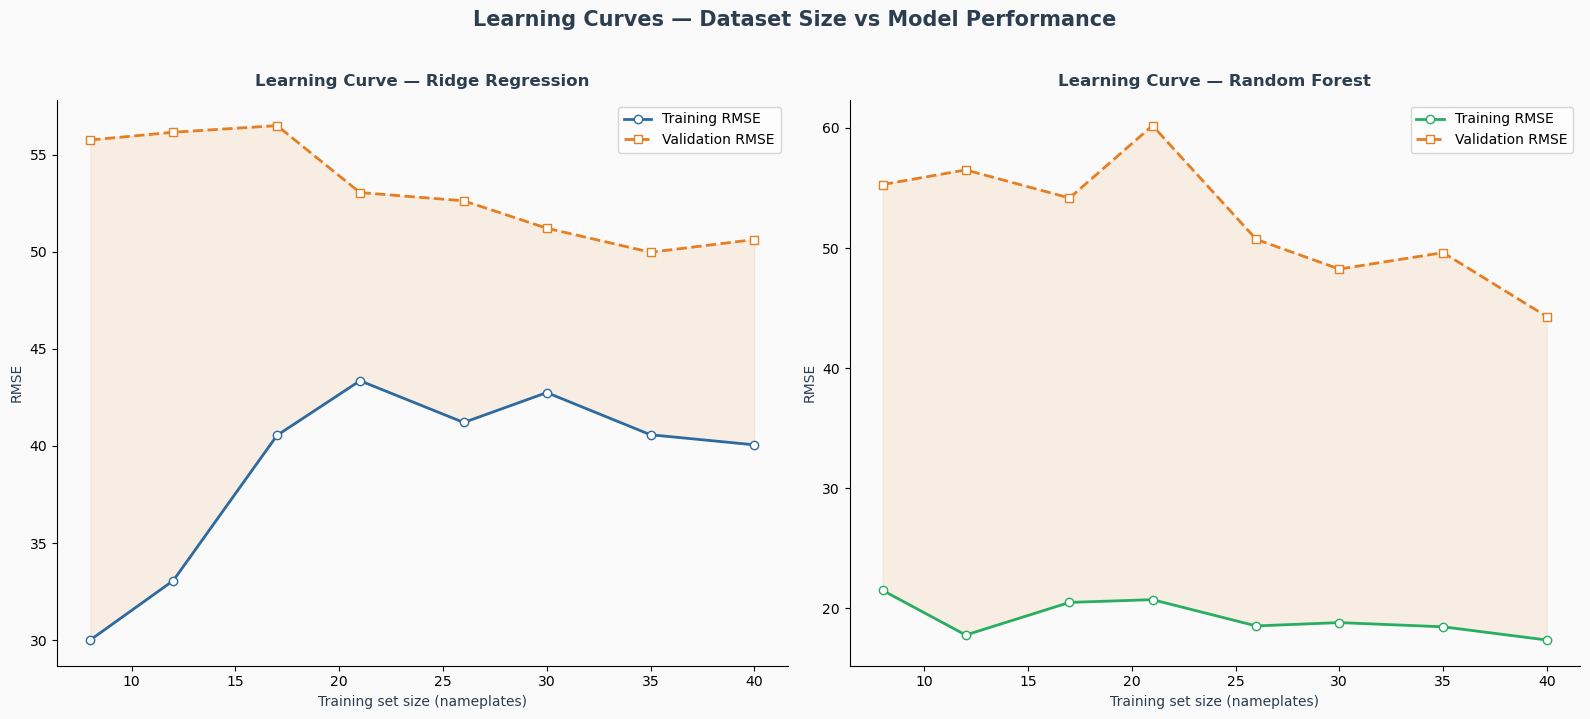

Saved: learning_curves.png


In [98]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.2, 1.0, 8)
y_full = df_model["target_winsorised"].values
X_full = X_scaled[FEATURE_COLS_CLEAN].values

# Ridge learning curve
train_sizes_ridge, train_scores_ridge, val_scores_ridge = learning_curve(
    Ridge(alpha=best_alpha), X_full, y_full,
    train_sizes=train_sizes, cv=5,
    scoring="neg_mean_squared_error", random_state=42
)

# RF learning curve
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    RandomForestRegressor(**best_params, random_state=42),
    X_full, y_full,
    train_sizes=train_sizes, cv=5,
    scoring="neg_mean_squared_error", random_state=42
)

train_rmse_ridge = np.sqrt(-train_scores_ridge.mean(axis=1))
val_rmse_ridge   = np.sqrt(-val_scores_ridge.mean(axis=1))
train_rmse_rf    = np.sqrt(-train_scores_rf.mean(axis=1))
val_rmse_rf      = np.sqrt(-val_scores_rf.mean(axis=1))

print("Ridge Learning Curve:")
print(f"{'Train size':>12} {'Train RMSE':>12} {'Val RMSE':>12}")
for n, tr, vl in zip(train_sizes_ridge, train_rmse_ridge, val_rmse_ridge):
    print(f"{int(n):>12} {tr:>12.2f} {vl:>12.2f}")

print("\nRF Learning Curve:")
print(f"{'Train size':>12} {'Train RMSE':>12} {'Val RMSE':>12}")
for n, tr, vl in zip(train_sizes_rf, train_rmse_rf, val_rmse_rf):
    print(f"{int(n):>12} {tr:>12.2f} {vl:>12.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#FAFAFA")

for ax, train_s, train_rmse, val_rmse, title, color in [
    (axes[0], train_sizes_ridge, train_rmse_ridge, val_rmse_ridge,
     "Ridge Regression", PALETTE["blue"]),
    (axes[1], train_sizes_rf,    train_rmse_rf,    val_rmse_rf,
     "Random Forest",    PALETTE["green"]),
]:
    ax.set_facecolor("#FAFAFA")
    ax.plot(train_s, train_rmse, color=color, linewidth=2,
            marker="o", markersize=6,
            markerfacecolor="white", markeredgecolor=color,
            label="Training RMSE")
    ax.plot(train_s, val_rmse, color=PALETTE["orange"], linewidth=2,
            marker="s", markersize=6,
            markerfacecolor="white", markeredgecolor=PALETTE["orange"],
            label="Validation RMSE", linestyle="--")
    ax.fill_between(train_s, train_rmse, val_rmse,
                    alpha=0.1, color=PALETTE["orange"])
    ax.set_xlabel("Training set size (nameplates)", fontsize=10,
                  color=PALETTE["dark_grey"])
    ax.set_ylabel("RMSE", fontsize=10, color=PALETTE["dark_grey"])
    ax.set_title(f"Learning Curve — {title}", fontsize=12,
                 fontweight="bold", color=PALETTE["dark_grey"], pad=10)
    ax.legend(fontsize=10)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Learning Curves — Dataset Size vs Model Performance",
             fontsize=15, fontweight="bold",
             color=PALETTE["dark_grey"], y=1.02)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150,
            bbox_inches="tight", facecolor="#FAFAFA")
plt.show()
print("Saved: learning_curves.png")

### Learning Curves — Dataset Size vs Model Performance

Both models show a persistent gap between training and validation RMSE across all 
training sizes, indicating the dataset is too small to fully close the 
bias-variance gap rather than a fundamental model failure.

Ridge training RMSE rises from 30 at 8 nameplates to approximately 40 at 40 
nameplates — an unusual pattern where training error increases with more data. 
This reflects Ridge's regularisation forcing coefficients toward zero as the 
model sees more varied examples, preventing overfitting at the cost of higher 
training error. Validation RMSE declines steadily from 55.8 to 50.6 as training 
size grows, suggesting Ridge would continue to improve modestly with more data. 
The gap at full training size is approximately 10 RMSE units — a high-bias 
signature consistent with the R² of 0.31 reported in Step 1.

Random Forest shows the opposite pattern — training RMSE stays flat around 
18–21 across all sizes, confirming RF memorises training data almost perfectly 
regardless of size. Validation RMSE declines more steeply than Ridge, from 55.3 
at 8 nameplates to 44.3 at 40 nameplates, and the downward trend is still 
clearly continuing at the rightmost point. This suggests RF would benefit 
meaningfully from additional training examples — the validation curve has not 
plateaued, meaning more Toyota nameplate data would likely produce genuine 
out-of-sample improvement rather than just overfitting.

The persistent train-validation gap in both models is expected given a 50-nameplate 
dataset with 12 features. It does not invalidate the predictions but confirms 
they should be interpreted as directional signals rather than precise forecasts.

## 3.7 Step 3 Summary

Step 3 extended the revenue growth analysis into three connected areas: transition 
classification, Lasso feature selection, and learning curve analysis — each 
providing a distinct layer of insight into Toyota's electrification trajectory.

**Electrification transition classification.** Four platforms are in active 
transition — Highlander, Grand Highlander, Tacoma, and RX — where electrified 
variants are outpacing ICE counterparts by at least 10 percentage points. The RF 
classifier achieves AUC of 0.719, correctly ranking all 9 transition nameplates 
in the top 11 by probability using vehicle specs alone. Sienna and Sequoia emerge 
as borderline false positives, sharing spec characteristics with transition 
platforms despite carrying no ICE variant to phase out. The transition direction 
labels distinguish ICE variants requiring managed wind-down from HEV and PHEV 
variants requiring accelerated inventory push.

**Lasso feature selection.** Lasso with optimal alpha of 0.850 retains all 12 
features with non-zero coefficients, confirming the full feature set carries 
meaningful signal and aggressive dimensionality reduction is not warranted. 
`platform_maturity` carries the largest negative coefficient, consistent with 
its dominant RF importance from Step 1. `seating` and `horsepower` are the 
strongest positive contributors and the last to approach zero as regularisation 
increases — confirming these as the most robust linear predictors of nameplate 
growth.

**Learning curves.** Both models show a persistent train-validation gap that 
continues to narrow as training size increases, particularly for RF where 
validation RMSE drops from 55.3 to 44.3 across the full training range without 
plateauing. This suggests genuine improvement is achievable with more nameplate 
data rather than irreducible noise. Ridge shows a high-bias pattern consistent 
with its R² of 0.31, while RF's flat training RMSE confirms it memorises 
training data but generalises better than Ridge at larger training sizes.

**Strategic synthesis.** Combining Steps 1, 2, and 3, the analysis supports 
three actionable conclusions for Toyota's US product strategy:

1. Truck and large SUV utility specs drive revenue growth — nameplates combining 
seating capacity, cargo space, and platform recency are the most defensible 
growth candidates, led by Grand Highlander, TX, and Tacoma families

2. Four platforms are mid-transition — Highlander, Grand Highlander, Tacoma, 
and RX ICE variants require managed decline while their HEV and PHEV counterparts 
require accelerated market push, particularly in Cluster 1 mature states where 
electrification adoption is already established

3. HEV nameplates with high fuel efficiency and broad geographic reach should 
be directed toward Cluster 0 low-infrastructure states where Prius demonstrates 
a 2.9x over-index relative to population — representing a potential $17.45B 
revenue opportunity if matched across the top 10 HEV nameplates

# Part 4 — Project Summary

This project applied supervised machine learning to Toyota and Lexus US sales data 
to answer three connected questions: which vehicle specifications the market rewards, 
how predicted growth translates into revenue, and where electrification transitions 
are actively underway.

### 4.1 Step 1 — Spec-Based Growth Prediction

Random Forest regression on 12 vehicle specification features produced a model 
explaining 31% of variance in YoY volume growth across 50 Toyota and Lexus 
nameplates. `platform_maturity` dominates feature importance at 0.40 — newer 
generation platforms consistently outperform older ones regardless of other specs. 
`seating` is the second most important feature, confirming large family vehicles 
structurally outperform sedans and compact cars in 2023–2025. `cargo_cuft` and 
`mpg_combined` define the secondary demand axis. `is_electrified` and 
`infra_poor_market_share` carry near-zero RF importance across the full lineup, 
reflecting sparse electrification signal at the 50-model scale.

Ridge regression (alpha=10) and RF (n=50, depth=None) were trained on 
winsorised targets with correlated features removed. RF was selected as the 
primary model. The spec-vs-momentum validation confirmed 60–65% directional 
agreement between RF predictions and observed sales momentum, with systematic 
divergences on aging ICE platforms and electrified models the market is 
rewarding beyond their specs.

### 4.2 Step 2 — Revenue Projection and Competitive Context

RF predicted growth rates were applied directly to each model's 2025 revenue 
base to produce model-level projections. Softmax weights combining clipped growth 
scores and current revenue share serve as a prioritisation signal alongside the 
projections. Aggregate projected revenue reaches $153.0B against a current base 
of $132.5B, with the Toyota NA annualised benchmark of $144.5B confirming the 
projection is within a realistic range.

Grand Highlander leads the projected increment at +$5.6B, followed by Grand 
Highlander Hybrid at +$4.1B and TX at +$3.4B. RAV4 absorbs the largest 
contraction at -$1.9B — a consequence of its $16.3B revenue base amplifying 
a moderate negative growth prediction. The SUV segment dominates the growth 
story across both ICE and HEV drivetrains.

Toyota NA revenue grew +12.1% year-over-year while Tesla's automotive revenue 
contracted 9.8% from $77.1B to $69.5B in FY2025. Toyota's North America revenue 
now exceeds Tesla's total global automotive revenue by approximately $38.9B, 
with growth driven predominantly by HEV and ICE platforms rather than BEV.

### 4.3 Step 3 — Electrification Transition Strategy

Three analyses identified where and how Toyota should accelerate electrification:

**Transition classification** identified four platforms in active transition — 
Highlander, Grand Highlander, Tacoma, and RX — where electrified variants 
outpace ICE counterparts by at least 10 percentage points. The RF classifier 
ranked all 9 transition nameplates in the top 11 by probability (AUC=0.719) 
using specs alone. ICE variants on these platforms require managed wind-down; 
HEV and PHEV variants require accelerated push.

**HEV opportunity across all five clusters** extended the original Cluster 0 
analysis to the full market segmentation from Strategy 1. Drivetrain focus per 
cluster was assigned by data-derived infra density thresholds. Clusters 0 and 4 
are HEV markets — over-indexes of 1.94x and 2.32x respectively against the 
population benchmark produce a combined $17.66B opportunity, with Cluster 0 
alone accounting for $16.35B. Cluster 1 (60.8% of US population) is a PHEV 
market at a near-neutral 1.04x over-index. Clusters 2 and 3 produce negative 
HEV opportunity scores and are assigned PHEV and BEV respectively. The total 
positive opportunity across all clusters is $18.85B.

**Lasso and learning curves** confirmed the full 12-feature set carries 
meaningful signal with no features warranting removal. RF learning curves show 
validation RMSE still declining at full training size, suggesting genuine 
improvement is achievable with additional nameplate data.

### 4.4 Limitations and Caveats

- Dataset covers 50–52 nameplates — a small sample for supervised learning, 
  reflected in RF R² of 0.31 and persistent train-validation gaps in learning curves
- ATP is held constant across years — revenue projections do not capture 
  price mix changes or incentive adjustments
- `is_electrified` carries near-zero RF importance, meaning the model cannot 
  fully capture the electrification demand premium observed in the momentum data
- Softmax weights use temperature=30 and [-50%, +50%] clipping — both are 
  judgment parameters that affect relative model prioritisation
- Toyota financial figures use a 149 yen/USD exchange rate from the FY2026 Q3 
  report — currency movements would shift all USD benchmarks

### 4.5 Strategic Recommendations

Three actionable priorities emerge from the combined analysis:

1. **Accelerate Grand Highlander and TX platform investment** — both carry high 
   RF growth scores, large or growing revenue bases, and high confidence flags 
   from Ridge-RF directional agreement

2. **Manage the four transition platforms actively** — Highlander, Grand 
   Highlander, Tacoma, and RX are mid-transition; ICE production planning 
   should account for accelerating electrified substitution, particularly 
   Tacoma Hybrid at +222.9% growth

3. **Deploy drivetrain strategy by cluster rather than nationally** — HEV 
   deepening in Clusters 0 and 4 (Camry Hybrid, RAV4 Hybrid, Sienna as anchor 
   nameplates for a combined $17.66B opportunity), PHEV bridging in Cluster 1 
   via RAV4 PHEV and Prius Prime, and BEV presence in Cluster 3 where Toyota's 
   current portfolio is limited to BZ4X and RZ